# 👥 INX Future Inc — Employee Performance Analysis
**IABAC Project 10281 · Data Science · End-to-end analysis, modelling and recommendations**

---

## 🎯 Objectives

**Main objective:** analyse the performance records of **1,200 INX Future Inc. employees** to find the *core causes* of the decline in performance, give management *clear indicators* of under-performing employees, and build a model that predicts an employee's performance rating from the available factors — so that action can be targeted without hurting the morale of everyone else.

**Specific objectives** (each one is answered with real numbers in the **Final Project Report, Section 21**):

| # | Objective | The brief asks for | Where |
|---|---|---|---|
| **O1** | Compare performance across all departments and test whether the differences are real | Insight 1 — department-wise performance | Section 5 |
| **O2** | Find the 3 most important factors affecting performance, using several independent methods | Insight 2 — top-3 factors | Section 13 |
| **O3** | Build, tune and validate a multi-class model that predicts `PerformanceRating`; compare algorithms with cross-validation and report honest hold-out results | Insight 3 — a trained model | Sections 9 – 12, 17 – 18 |
| **O4** | Check honestly whether that model can be used at the *hiring* stage | Insight 3 — "will be used to hire employees" | Section 15 |
| **O5** | Define clear, low-collateral indicators of non-performing employees | The CEO's morale concern | Section 16 |
| **O6** | Turn the evidence into practical, prioritised recommendations | Insight 4 — recommendations | Section 19 |

**How success is judged**
- The main metric is **macro-F1**: the three ratings are very unbalanced (about 73% of employees are rated 3), so plain accuracy would be misleading.
- The model must clearly beat an "always predict the most common rating" baseline, and its score must hold up on an unseen 20% test set *and* in cross-validation.
- Every finding is backed by a statistical test or a validated model — and where the data can only show an association (not a cause), the notebook says so.

## 📌 Business problem
INX Future Inc. is a well-rated employer, but employee performance indicators have declined and client satisfaction fell by 8 percentage points. The CEO (Mr. Brain) wants to **understand the root causes without penalising people blindly** — and wants clear indicators of under-performance so that any corrective action is targeted and does not damage the morale of everyone else.

## 🗺️ Roadmap
1. Setup → 2. Load data → 3. Data audit → 4. Target & univariate EDA → **5. Department performance (D1)** → 6. What separates performance levels → 7. Feature engineering & split → 8. Design-choice ablation (engineered features? SMOTE?) → 9. Baseline models → 10. Bayesian tuning (Optuna) → 11. Final models, Voting & Stacking → 12. Class-probability tuning & evaluation → **13. Top-3 factors (D2)** → 14. Dashboard → **15. Hiring-stage model (D3)** → 16. Non-performer indicators → **17. Final model bundle** → **18. Prediction functions** → **19. Recommendations (D4)** → 20. Executive summary → **21. Final Project Report (results vs objectives)**

## ⚙️ How this notebook is built
- **Every code cell is self-contained**: it has its own imports, helpers and artifact loaders, so you can restart the kernel and run any section on its own (as long as the earlier section that creates its input has been run once).
- Intermediate results are saved in an `artifacts/` folder next to the notebook.
- Errors are explicit — they tell you *what is missing and which section creates it*.
- All randomness is seeded (`RANDOM_STATE = 42`).
- ⏱️ A full run takes roughly **10 – 30 minutes** depending on the computer (Optuna tuning and the Stacking model are the slow parts). For a quick test, lower `N_TRIALS` in Section 10.

## 🧭 Conventions & one assumption to be aware of
- `PerformanceRating` codes are **1 Low · 2 Good · 3 Excellent · 4 Outstanding**. The data contains **only 2, 3 and 4** — nobody is rated 1.
  So **"Good (2)" is the lowest observed level**, and throughout this notebook "under-performers / non-performing" means *rated Good (2), i.e. below their peers* — not "failing".
- For modelling, the labels are re-coded `2→0, 3→1, 4→2` (XGBoost needs consecutive class ids). Outputs always show the original names.

## 1️⃣ Setup — dependency check


In [1]:
import sys
print('🐍 Python executable in use:', sys.executable)

🐍 Python executable in use: C:\Users\VIRAJ\anaconda3\envs\tensorflow_env\python.exe


In [2]:
import sys, importlib

REQUIRED = {                      
    'pandas': 'pandas', 'numpy': 'numpy', 'scipy': 'scipy',
    'matplotlib': 'matplotlib', 'seaborn': 'seaborn', 'sklearn': 'scikit-learn',
    'xlrd': 'xlrd',               
    'xgboost': 'xgboost', 'lightgbm': 'lightgbm', 'optuna': 'optuna',
    'imblearn': 'imbalanced-learn', 'shap': 'shap', 'joblib': 'joblib',
}

print(f'🐍 Python {sys.version.split()[0]}\n')
missing = []
for module_name, pip_name in REQUIRED.items():
    try:
        module = importlib.import_module(module_name)
        print(f'✅ {pip_name:<18} {getattr(module, "__version__", "")}')
    except ImportError:
        print(f'❌ {pip_name:<18} MISSING')
        missing.append(pip_name)

if missing:
    print('\n👉 Install the missing packages, restart the kernel, then re-run:')
    print('   pip install ' + ' '.join(missing))
else:
    print('\n🎉 All dependencies available.')

🐍 Python 3.11.15

✅ pandas             3.0.5
✅ numpy              2.4.6
✅ scipy              1.17.1
✅ matplotlib         3.11.1
✅ seaborn            0.13.2
✅ scikit-learn       1.5.2
✅ xlrd               2.0.2
✅ xgboost            3.2.0
✅ lightgbm           4.7.0
✅ optuna             5.0.0
✅ imbalanced-learn   0.14.2
✅ shap               0.51.0
✅ joblib             1.5.3

🎉 All dependencies available.


✅ seaborn            0.13.2
✅ scikit-learn       1.9.1
✅ xlrd               2.0.2


✅ xgboost            3.4.1
✅ lightgbm           4.7.0
✅ optuna             5.0.0


/usr/local/lib/python3.13/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ imbalanced-learn   0.14.2


✅ shap               0.52.0
✅ joblib             1.6.0

🎉 All dependencies available.


## 2️⃣ Load data
The workbook has two sheets: the **employee records** and a **Data Definitions** sheet. The loader searches for the file with `os.walk` (a few folder levels deep), so you normally don't need to edit any path.
If it can't find the file, set `DATA_PATH_OVERRIDE` to the full path.

In [3]:
import os
import pandas as pd
import joblib


roots = [".", os.path.expanduser("~/Downloads"), os.path.expanduser("~/Desktop"),
         os.path.expanduser("~/Documents"), "/mnt/user-data/uploads"]
MAX_DEPTH = 3                      # how many folder levels to look into under each root

data_path = None
for root in roots:
    if not os.path.isdir(root):
        continue
    for folder, dirnames, filenames in os.walk(root):
        if folder.count(os.sep) - root.count(os.sep) >= MAX_DEPTH:
            dirnames[:] = []       # do not go any deeper
        for name in filenames:
            if name.startswith("INX_Future_Inc_Employee_Performance") and name.lower().endswith((".xls", ".xlsx")):
                data_path = os.path.join(folder, name)
                break
        if data_path:
            break
    if data_path:
        break

if data_path is None:
    raise FileNotFoundError(
        "❌ Employee Performance Excel file not found.\n"
        f"   Looked in: {roots}\n"
        f"   Current folder: {os.getcwd()}\n"
        "   👉 Put the .xls file next to this notebook (or in Downloads) and run this cell again."
    )
print("📂 File:", data_path)

# 2. Read the employee sheet (first sheet)
engine = "xlrd" if data_path.lower().endswith(".xls") else "openpyxl"
raw = pd.read_excel(data_path, sheet_name=0, engine=engine)

# 3. Read the Data Definitions sheet
definitions = pd.read_excel(data_path, sheet_name="Data Definitions", header=None, engine=engine)
definitions.columns = ["Feature", "Code"]
definitions["Feature"] = definitions["Feature"].ffill()
definitions = definitions.dropna(subset=["Code"])

# 4. Save raw data for the next sections
os.makedirs("artifacts", exist_ok=True)
joblib.dump(raw, "artifacts/raw_df.pkl")

# 5. Show results
print(f"✅ Data loaded: {raw.shape[0]} rows × {raw.shape[1]} columns")
print("💾 Saved: artifacts/raw_df.pkl")
print("\n📖 DATA DEFINITIONS (meaning of the 1–4 codes)")
for feature, group in definitions.groupby("Feature", sort=False):
    print(f"   {feature:<28} " + " | ".join(group["Code"].astype(str)))

display(raw.head())

📂 File: .\INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8.xls
✅ Data loaded: 1200 rows × 28 columns
💾 Saved: artifacts/raw_df.pkl

📖 DATA DEFINITIONS (meaning of the 1–4 codes)
   EmpEducationLevel            1 'Below College' | 2 'College' | 3 'Bachelor' | 4 'Master' | 5 'Doctor'
   EmpEnvironmentSatisfaction   1 'Low' | 2 'Medium' | 3 'High' | 4 'Very High'
   EmpJobInvolvement            1 'Low' | 2 'Medium' | 3 'High' | 4 'Very High'
   EmpJobSatisfaction           1 'Low' | 2 'Medium' | 3 'High' | 4 'Very High'
   PerformanceRating            1 'Low' | 2 'Good' | 3 'Excellent' | 4 'Outstanding'
   RelationshipSatisfaction     1 'Low' | 2 'Medium' | 3 'High' | 4 'Very High'
   EmpWorkLifeBalance           1 'Bad' | 2 'Good' | 3 'Better' | 4 'Best'


,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3


##### 📝 Observation — the dataset
The workbook has two sheets: the employee records and a *Data Definitions* sheet that explains the 1–4 codes. The records contain **1,200 employees × 28 columns**: 1 ID (`EmpNumber`), 8 text (nominal) columns, 6 ordinal scores (education level and the satisfaction / involvement / work-life-balance ratings), 12 numeric columns and the target `PerformanceRating`.

The ordinal scores are stored as numbers but are really *ordered categories*, not measurements — so they are analysed with rank-based statistics (Spearman) rather than treated as ordinary continuous values.

## 3️⃣ Data audit
Before any analysis, verify the data is trustworthy: missing values, duplicates, ID uniqueness, text consistency, valid ordinal ranges (against the definitions sheet), logical consistency (e.g. *years at company ≤ total experience*) and outliers.

In [4]:
import os, joblib
import numpy as np
import pandas as pd

ARTIFACT_DIR = 'artifacts'

def load_artifact(name, made_in):
    path = os.path.join(ARTIFACT_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ '{path}' not found (cwd = {os.getcwd()}).\n   👉 Run {made_in} first — it creates this file.")
    return joblib.load(path)

df = load_artifact('raw_df.pkl', 'Section 2')

# ─── Schema (taken from the data-definitions sheet) ──────────────────────
TARGET = 'PerformanceRating'
ID_COL = 'EmpNumber'
NOMINAL = ['Gender', 'EducationBackground', 'MaritalStatus', 'EmpDepartment', 'EmpJobRole',
           'BusinessTravelFrequency', 'OverTime', 'Attrition']
ORDINAL_LABELS = {
    'EmpEducationLevel':           {1: 'Below College', 2: 'College', 3: 'Bachelor', 4: 'Master', 5: 'Doctor'},
    'EmpEnvironmentSatisfaction':  {1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'},
    'EmpJobInvolvement':           {1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'},
    'EmpJobSatisfaction':          {1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'},
    'EmpRelationshipSatisfaction': {1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'},
    'EmpWorkLifeBalance':          {1: 'Bad', 2: 'Good', 3: 'Better', 4: 'Best'},
    'PerformanceRating':           {1: 'Low', 2: 'Good', 3: 'Excellent', 4: 'Outstanding'},
}
ORDINAL = [c for c in ORDINAL_LABELS if c != TARGET]
NUMERIC = ['Age', 'DistanceFromHome', 'EmpHourlyRate', 'EmpJobLevel', 'NumCompaniesWorked',
           'EmpLastSalaryHikePercent', 'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
           'ExperienceYearsAtThisCompany', 'ExperienceYearsInCurrentRole',
           'YearsSinceLastPromotion', 'YearsWithCurrManager']

unknown_cols = set(df.columns) - set(NOMINAL + ORDINAL + NUMERIC + [TARGET, ID_COL])
absent_cols = set(NOMINAL + ORDINAL + NUMERIC + [TARGET, ID_COL]) - set(df.columns)
if unknown_cols or absent_cols:
    raise ValueError(f'❌ Schema mismatch. Unexpected columns: {sorted(unknown_cols)} | Missing columns: {sorted(absent_cols)}')
print(f'✅ Schema OK → {len(NOMINAL)} nominal · {len(ORDINAL)} ordinal · {len(NUMERIC)} numeric · 1 target · 1 id')

issues = []   # collect problems so we can summarise at the end

# 1. Missing values
n_missing = int(df.isnull().sum().sum())
print(f'\n🔎 Missing values        : {n_missing}')
if n_missing: issues.append('missing values')

# 2. Duplicates / ID uniqueness
n_dup_rows, n_dup_ids = int(df.duplicated().sum()), int(df[ID_COL].duplicated().sum())
print(f'🔎 Duplicate rows        : {n_dup_rows}   |  duplicate employee IDs: {n_dup_ids}')
if n_dup_rows or n_dup_ids: issues.append('duplicates')

# 3. Text consistency (leading/trailing spaces)
text_cols = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])]
n_ws = sum(int((df[c].astype(str) != df[c].astype(str).str.strip()).sum()) for c in text_cols)
print(f'🔎 Whitespace problems   : {n_ws}')
if n_ws: issues.append('whitespace')

# 4. Constant columns
constant = [c for c in df.columns if df[c].nunique() == 1]
print(f'🔎 Constant columns      : {constant if constant else "none"}')
if constant: issues.append('constant columns')

# 5. Ordinal values vs. definitions
print('\n🔎 Ordinal codes vs data-definitions sheet')
for col, mapping in ORDINAL_LABELS.items():
    observed = sorted(df[col].unique())
    invalid = [v for v in observed if v not in mapping]
    status = '✅' if not invalid else '❌'
    print(f'   {status} {col:<28} observed {observed}')
    if invalid: issues.append(f'invalid codes in {col}: {invalid}')
print('   ℹ️  PerformanceRating has no code 1 (Low) in the data → lowest observed level is 2 (Good).')

# 6. Logical consistency
print('\n🔎 Logical consistency (violations expected = 0)')
checks = {
    'Years at company  ≤ total experience': df['ExperienceYearsAtThisCompany'] > df['TotalWorkExperienceInYears'],
    'Years in role     ≤ years at company': df['ExperienceYearsInCurrentRole'] > df['ExperienceYearsAtThisCompany'],
    'Years w/ manager  ≤ years at company': df['YearsWithCurrManager'] > df['ExperienceYearsAtThisCompany'],
    'Years since promo ≤ years at company': df['YearsSinceLastPromotion'] > df['ExperienceYearsAtThisCompany'],
    'Total experience  ≤ age − 14'        : df['TotalWorkExperienceInYears'] > (df['Age'] - 14),
}
for name, violated in checks.items():
    n = int(violated.sum())
    print(f'   {"✅" if n == 0 else "⚠️ "} {name:<40} violations: {n}')
    if n: issues.append(name)

# 7. Outliers (IQR rule) — informational, we do NOT drop rows
print('\n🔎 Outliers (1.5×IQR rule) — informational')
rows = []
for c in NUMERIC:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = int(((df[c] < q1 - 1.5 * iqr) | (df[c] > q3 + 1.5 * iqr)).sum())
    rows.append((c, n_out, round(100 * n_out / len(df), 1), df[c].min(), df[c].max()))
out_table = pd.DataFrame(rows, columns=['feature', 'n_outliers', 'pct', 'min', 'max']).sort_values('n_outliers', ascending=False)
print(out_table[out_table.n_outliers > 0].to_string(index=False))
print('   💡 Outliers are plausible values (e.g. 40 yrs experience), and tree-based models are robust to them → kept.')

print('\n' + ('🎉 AUDIT PASSED — no blocking issues.' if not issues else f'⚠️  AUDIT FLAGS: {issues}'))

# ─── Persist the clean frame + schema for later sections ─────────────────
df['PerformanceLabel'] = df[TARGET].map(ORDINAL_LABELS[TARGET])
schema = dict(TARGET=TARGET, ID_COL=ID_COL, NOMINAL=NOMINAL, ORDINAL=ORDINAL, NUMERIC=NUMERIC,
              ORDINAL_LABELS=ORDINAL_LABELS)
joblib.dump(df, os.path.join(ARTIFACT_DIR, 'clean_df.pkl'))
joblib.dump(schema, os.path.join(ARTIFACT_DIR, 'schema.pkl'))
print(f'💾 Saved → {ARTIFACT_DIR}/clean_df.pkl , {ARTIFACT_DIR}/schema.pkl')

✅ Schema OK → 8 nominal · 6 ordinal · 12 numeric · 1 target · 1 id

🔎 Missing values        : 0
🔎 Duplicate rows        : 0   |  duplicate employee IDs: 0
🔎 Whitespace problems   : 0
🔎 Constant columns      : none

🔎 Ordinal codes vs data-definitions sheet
   ✅ EmpEducationLevel            observed [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
   ✅ EmpEnvironmentSatisfaction   observed [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
   ✅ EmpJobInvolvement            observed [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
   ✅ EmpJobSatisfaction           observed [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
   ✅ EmpRelationshipSatisfaction  observed [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
   ✅ EmpWorkLifeBalance           observed [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
   ✅ PerformanceRating            observed [np.int64(2), np.int64(3), np.int64(4)]
   ℹ️  PerformanceRating has no code 1 (Low) in the data → lowest obser

🔎 Duplicate rows        : 0   |  duplicate employee IDs: 0
🔎 Whitespace problems   : 0
🔎 Constant columns      : none

🔎 Ordinal codes vs data-definitions sheet
   ✅ EmpEducationLevel            observed [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
   ✅ EmpEnvironmentSatisfaction   observed [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
   ✅ EmpJobInvolvement            observed [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
   ✅ EmpJobSatisfaction           observed [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
   ✅ EmpRelationshipSatisfaction  observed [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
   ✅ EmpWorkLifeBalance           observed [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
   ✅ PerformanceRating            observed [np.int64(2), np.int64(3), np.int64(4)]
   ℹ️  PerformanceRating has no code 1 (Low) in the data → lowest observed level is 2 (Good).

🔎 Logical consistency (violations expected = 0)
   ✅ Years at company  ≤

                     feature  n_outliers  pct  min  max
       TrainingTimesLastYear         188 15.7    0    6
     YearsSinceLastPromotion          88  7.3    0   15
ExperienceYearsAtThisCompany          56  4.7    0   40
  TotalWorkExperienceInYears          51  4.2    0   40
          NumCompaniesWorked          39  3.2    0    9
ExperienceYearsInCurrentRole          16  1.3    0   18
        YearsWithCurrManager          11  0.9    0   17
   💡 Outliers are plausible values (e.g. 40 yrs experience), and tree-based models are robust to them → kept.

🎉 AUDIT PASSED — no blocking issues.
💾 Saved → artifacts/clean_df.pkl , artifacts/schema.pkl


**Audit verdict:** the dataset is clean — no missing values, no duplicates, valid codes, and all logical relationships hold. The only data-quality observation is on the **target**: nobody holds rating 1, and 73% of employees sit at rating 3, so ratings are compressed around the middle (a point we return to in the recommendations).

## 4️⃣ Target & univariate EDA
### 4.1 Target distribution

🎯 TARGET: PerformanceRating
   Good             ███████                         194  (16.2%)
   Excellent        ██████████████████████████████  874  (72.8%)
   Outstanding      █████                           132  (11.0%)

⚖️  Imbalance ratio (largest / smallest class): 6.6 : 1
💡 Accuracy alone would be misleading (always predicting "Excellent" scores ~73%).
   → we will judge models mainly on MACRO-F1 and BALANCED ACCURACY, which weight each class equally.


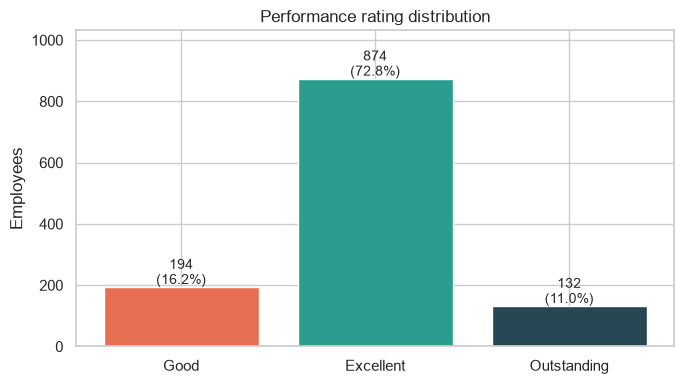

In [5]:
import os, joblib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

ARTIFACT_DIR = 'artifacts'
def load_artifact(name, made_in):
    path = os.path.join(ARTIFACT_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ '{path}' not found (cwd = {os.getcwd()}).\n   👉 Run {made_in} first — it creates this file.")
    return joblib.load(path)

def ascii_bar(label, value, max_value, width=30, text=None):
    n = int(round(width * value / max_value)) if max_value > 0 else 0
    print(f'   {label:<16} {"█" * n:<{width}} {text if text is not None else value}')

sns.set_theme(style='whitegrid')
df = load_artifact('clean_df.pkl', 'Section 3')

order = ['Good', 'Excellent', 'Outstanding']
counts = df['PerformanceLabel'].value_counts().reindex(order)
total = counts.sum()

print('🎯 TARGET: PerformanceRating')
for label, c in counts.items():
    ascii_bar(f'{label}', c, counts.max(), text=f'{c:>4}  ({100 * c / total:4.1f}%)')
print(f'\n⚖️  Imbalance ratio (largest / smallest class): {counts.max() / counts.min():.1f} : 1')
print('💡 Accuracy alone would be misleading (always predicting "Excellent" scores ~73%).')
print('   → we will judge models mainly on MACRO-F1 and BALANCED ACCURACY, which weight each class equally.')

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(order, counts.values, color=['#e76f51', '#2a9d8f', '#264653'])
for bar, c in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, c + 10, f'{c}\n({100 * c / total:.1f}%)', ha='center', fontsize=10)
ax.set_title('Performance rating distribution'); ax.set_ylabel('Employees'); ax.set_ylim(0, counts.max() * 1.18)
plt.tight_layout(); plt.show()

##### 📝 Observation — the target
**874 employees (72.8%) are rated Excellent (3), 194 (16.2%) Good (2) and 132 (11.0%) Outstanding (4)** — a 6.6 : 1 gap between the largest and smallest class, and nobody is rated 1. This is a **multi-class** problem. A model that always answers "3" would already be 73% accurate, which is why accuracy alone is not enough and model selection uses **macro-F1**, which treats all three ratings equally. Whether to rebalance the data (SMOTE) is *tested* in Section 8, not assumed.

### 4.2 Numeric features — distributions and skew

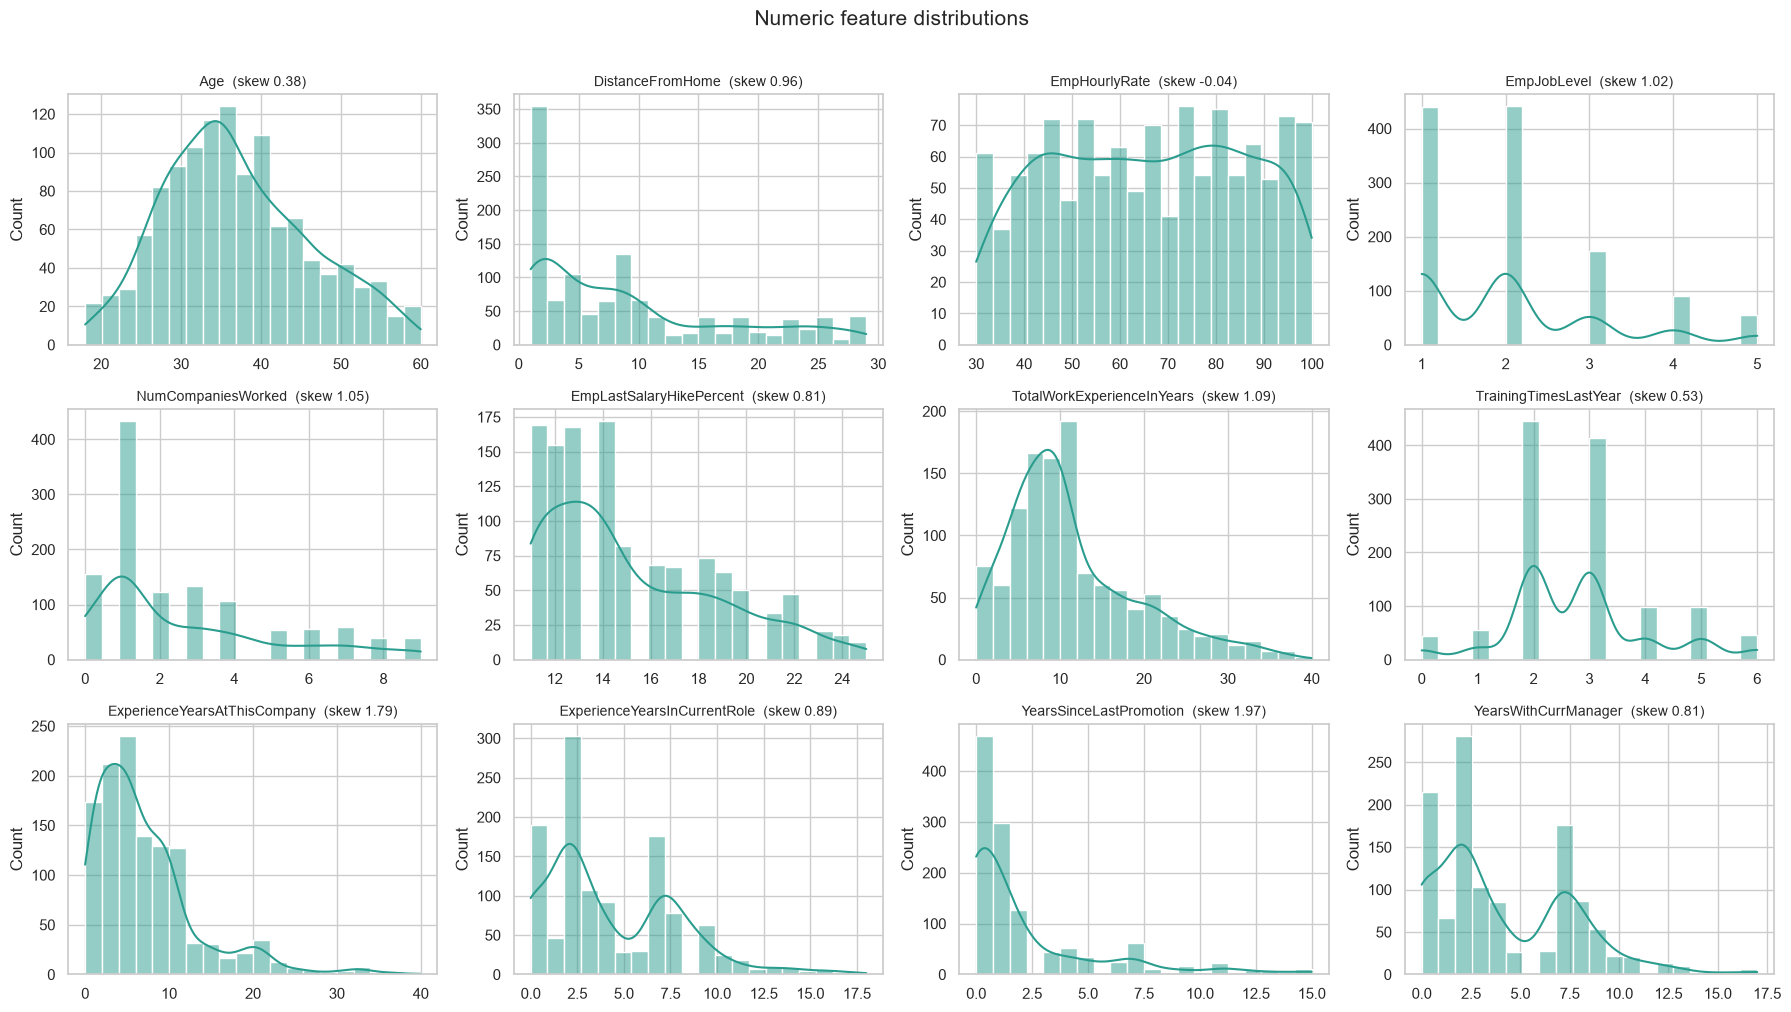

📐 Most skewed features (|skew| > 1 → long right tail):
YearsSinceLastPromotion         1.97
ExperienceYearsAtThisCompany    1.79
TotalWorkExperienceInYears      1.09
NumCompaniesWorked              1.05
EmpJobLevel                     1.02

💡 Tenure-type variables are right-skewed (many newer staff, few long-serving). No transform needed for tree models.


In [6]:
import os, joblib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

ARTIFACT_DIR = 'artifacts'
def load_artifact(name, made_in):
    path = os.path.join(ARTIFACT_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ '{path}' not found (cwd = {os.getcwd()}).\n   👉 Run {made_in} first — it creates this file.")
    return joblib.load(path)

sns.set_theme(style='whitegrid')
df = load_artifact('clean_df.pkl', 'Section 3')
NUMERIC = load_artifact('schema.pkl', 'Section 3')['NUMERIC']

fig, axes = plt.subplots(3, 4, figsize=(18, 10))
for ax, col in zip(axes.ravel(), NUMERIC):
    sns.histplot(df[col], kde=True, ax=ax, color='#2a9d8f', bins=20)
    ax.set_title(f'{col}  (skew {df[col].skew():.2f})', fontsize=10)
    ax.set_xlabel('')
plt.suptitle('Numeric feature distributions', fontsize=15, y=1.01)
plt.tight_layout(); plt.show()

skew = df[NUMERIC].skew().sort_values(key=abs, ascending=False)
print('📐 Most skewed features (|skew| > 1 → long right tail):')
print(skew[skew.abs() > 1].round(2).to_string())
print('\n💡 Tenure-type variables are right-skewed (many newer staff, few long-serving). No transform needed for tree models.')

### 4.3 Categorical & ordinal features

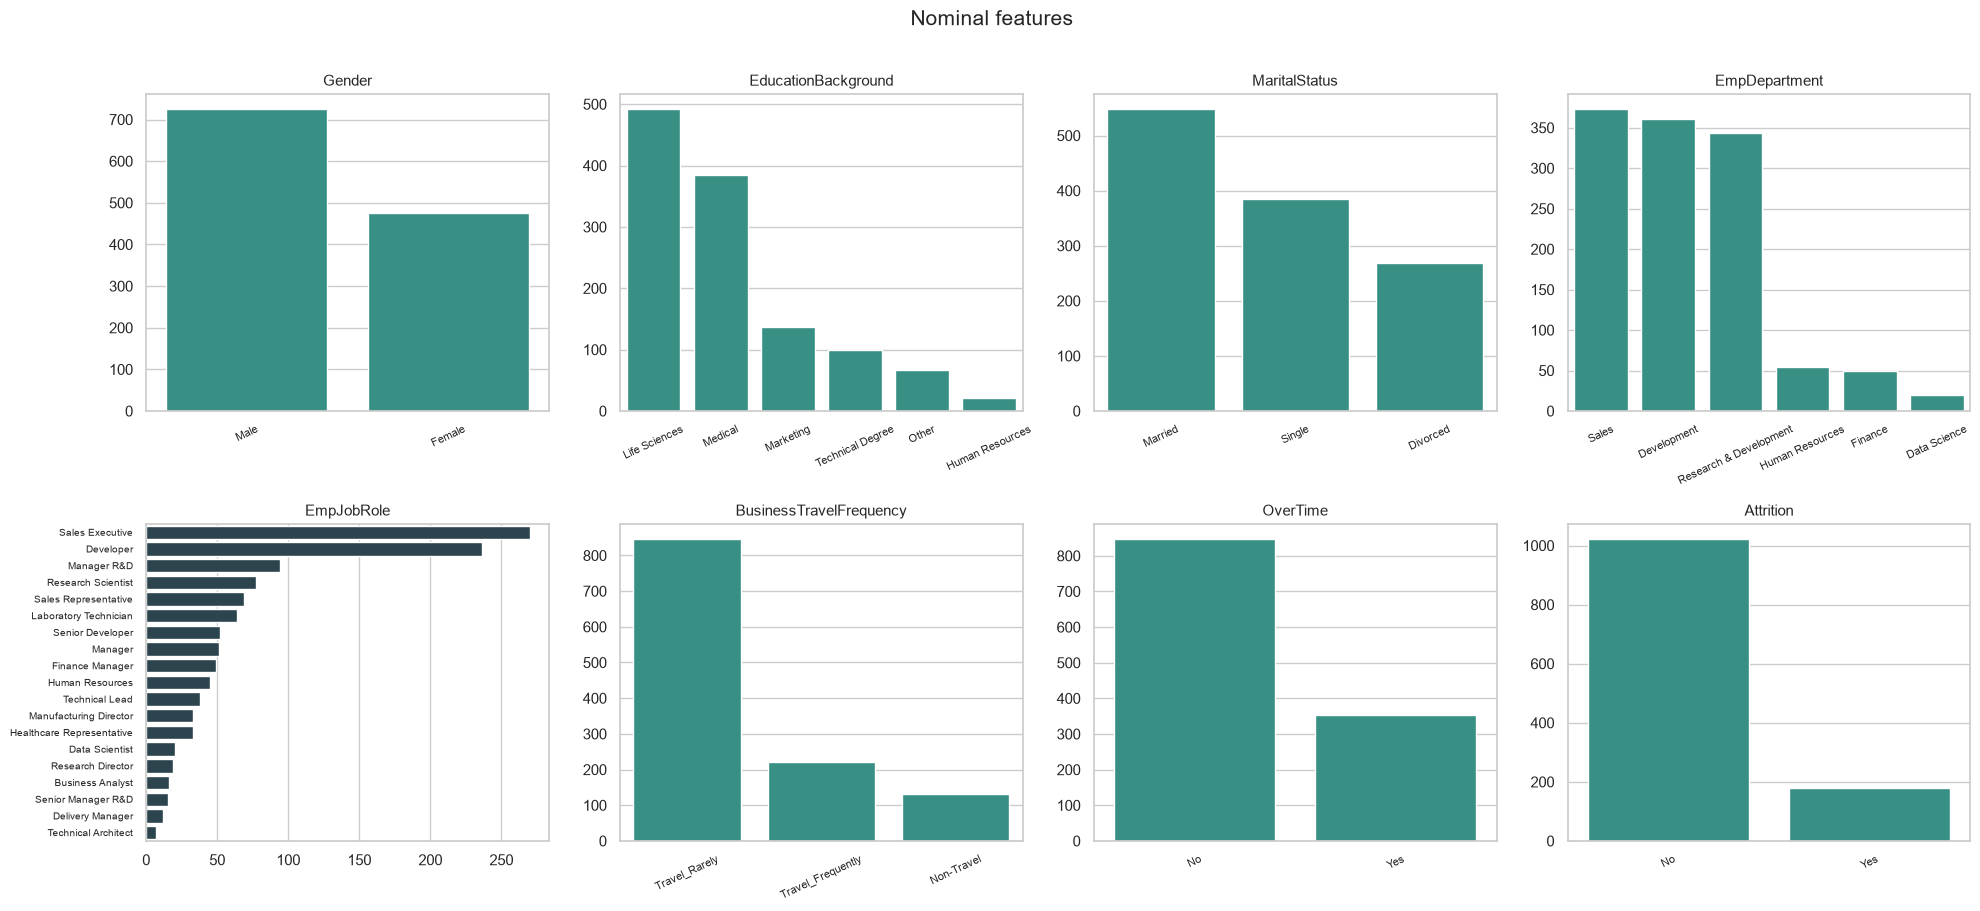

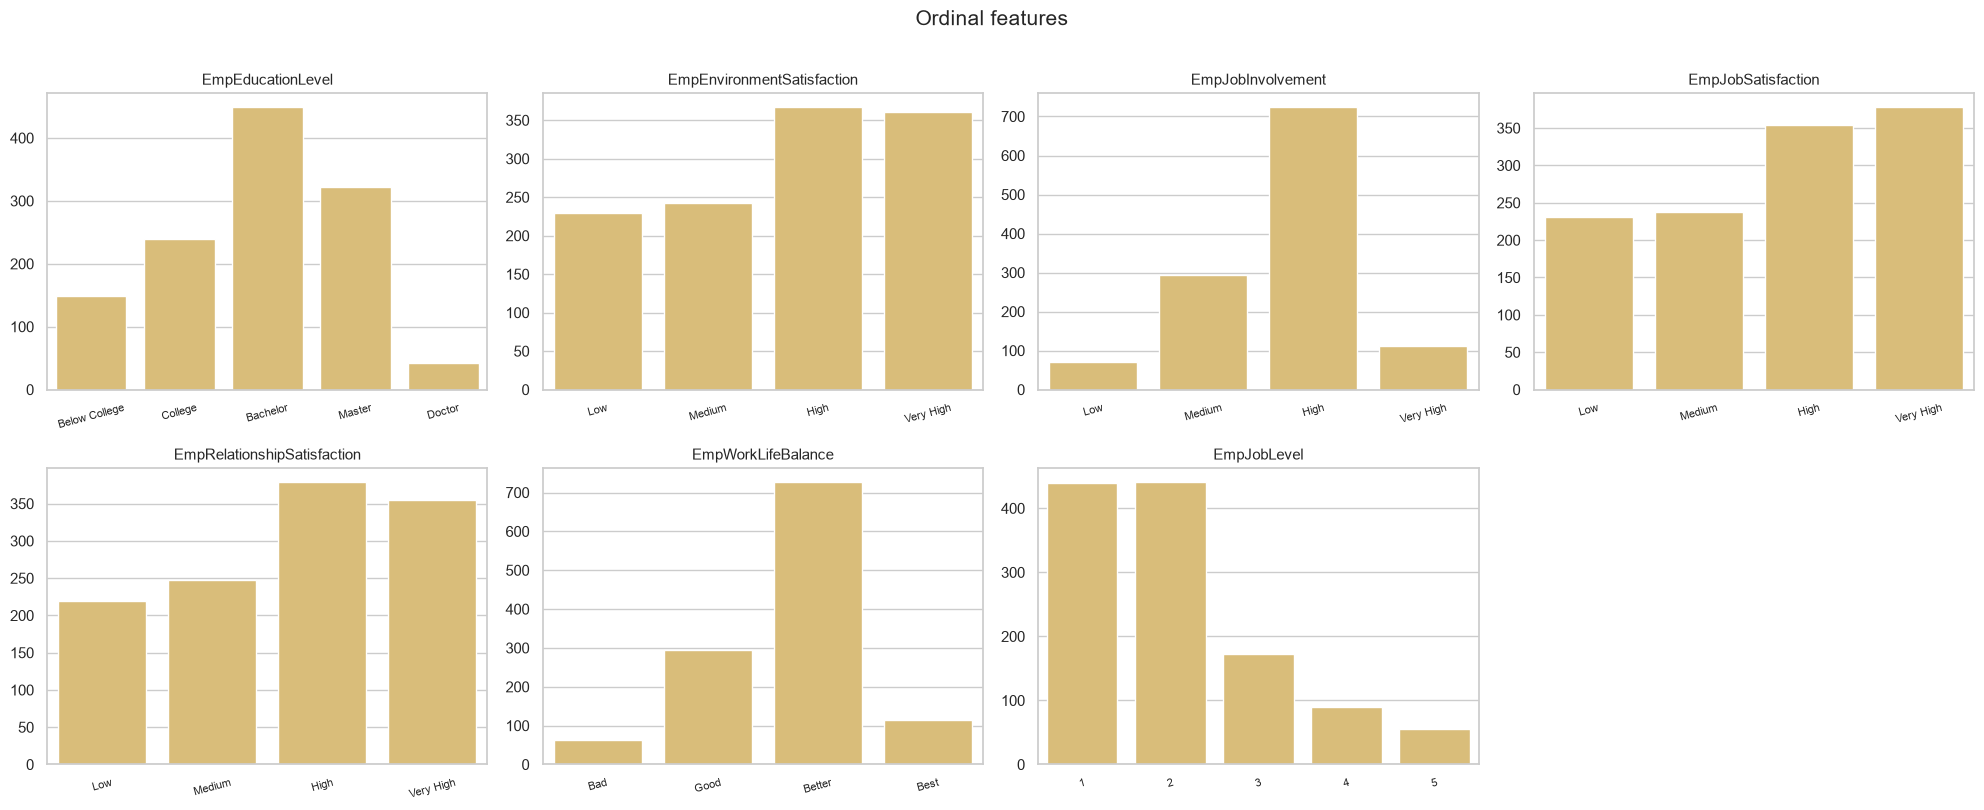

📊 Workforce composition
   Departments : {'Sales': 373, 'Development': 361, 'Research & Development': 343, 'Human Resources': 54, 'Finance': 49, 'Data Science': 20}
   Attrition   : {'No': 0.852, 'Yes': 0.148}
   OverTime    : {'No': 0.706, 'Yes': 0.294}
💡 Three departments (Sales, Development, R&D) hold ~90% of staff; Data Science has only 20 people → treat its numbers cautiously.


In [7]:
import os, joblib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

ARTIFACT_DIR = 'artifacts'
def load_artifact(name, made_in):
    path = os.path.join(ARTIFACT_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ '{path}' not found (cwd = {os.getcwd()}).\n   👉 Run {made_in} first — it creates this file.")
    return joblib.load(path)

sns.set_theme(style='whitegrid')
df = load_artifact('clean_df.pkl', 'Section 3')
schema = load_artifact('schema.pkl', 'Section 3')
NOMINAL, ORDINAL, ORDINAL_LABELS = schema['NOMINAL'], schema['ORDINAL'], schema['ORDINAL_LABELS']

# ── Nominal ──
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, col in zip(axes.ravel(), NOMINAL):
    vc = df[col].value_counts()
    if len(vc) > 8:                                   # job role has 19 levels → horizontal bars
        sns.barplot(x=vc.values, y=vc.index, ax=ax, color='#264653')
        ax.tick_params(axis='y', labelsize=7)
    else:
        sns.barplot(x=vc.index, y=vc.values, ax=ax, color='#2a9d8f')
        ax.tick_params(axis='x', rotation=25, labelsize=8)
    ax.set_title(col, fontsize=11); ax.set_xlabel(''); ax.set_ylabel('')
plt.suptitle('Nominal features', fontsize=15, y=1.01); plt.tight_layout(); plt.show()

# ── Ordinal ──
cols = ORDINAL + ['EmpJobLevel']
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, col in zip(axes.ravel(), cols):
    vc = df[col].value_counts().sort_index()
    names = [ORDINAL_LABELS.get(col, {}).get(i, str(i)) for i in vc.index]
    sns.barplot(x=names, y=vc.values, ax=ax, color='#e9c46a')
    ax.set_title(col, fontsize=11); ax.set_xlabel(''); ax.set_ylabel(''); ax.tick_params(axis='x', labelsize=8, rotation=15)
for ax in axes.ravel()[len(cols):]:
    ax.axis('off')
plt.suptitle('Ordinal features', fontsize=15, y=1.01); plt.tight_layout(); plt.show()

print('📊 Workforce composition')
print(f"   Departments : {df['EmpDepartment'].value_counts().to_dict()}")
print(f"   Attrition   : {df['Attrition'].value_counts(normalize=True).round(3).to_dict()}")
print(f"   OverTime    : {df['OverTime'].value_counts(normalize=True).round(3).to_dict()}")
print('💡 Three departments (Sales, Development, R&D) hold ~90% of staff; Data Science has only 20 people → treat its numbers cautiously.')

## 5️⃣ 📍 Deliverable 1 — Department-wise performance
We compare departments on (a) the **average rating**, (b) the **mix of ratings** (what share are rated Good / Excellent / Outstanding), with (c) bootstrap **confidence intervals** and (d) formal **significance tests** — because Finance (49 people), HR (54) and Data Science (20) are small groups where differences can easily be noise.

In [8]:
import os, joblib
import numpy as np, pandas as pd
from scipy import stats

ARTIFACT_DIR = 'artifacts'
def load_artifact(name, made_in):
    path = os.path.join(ARTIFACT_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ '{path}' not found (cwd = {os.getcwd()}).\n   👉 Run {made_in} first — it creates this file.")
    return joblib.load(path)

def ascii_bar(label, value, max_value, width=30, text=None):
    n = int(round(width * value / max_value)) if max_value > 0 else 0
    print(f'   {label:<24} {"█" * n:<{width}} {text if text is not None else value}')

df = load_artifact('clean_df.pkl', 'Section 3')
T, D = 'PerformanceRating', 'EmpDepartment'
rng = np.random.default_rng(42)

# ─── Department summary ──────────────────────────────────────────────────
dept = df.groupby(D).agg(headcount=(T, 'size'), mean_rating=(T, 'mean'))
for code_, name in {2: 'pct_Good', 3: 'pct_Excellent', 4: 'pct_Outstanding'}.items():
    dept[name] = df.groupby(D)[T].apply(lambda s, c=code_: 100 * (s == c).mean())

ci = {}
for name, grp in df.groupby(D):                      # bootstrap 95% CI of the mean rating
    vals = grp[T].values
    boots = [rng.choice(vals, size=len(vals), replace=True).mean() for _ in range(2000)]
    ci[name] = np.percentile(boots, [2.5, 97.5])
dept['ci_low'] = [ci[d][0] for d in dept.index]
dept['ci_high'] = [ci[d][1] for d in dept.index]
dept = dept.sort_values('mean_rating', ascending=False)

print('🏢 DEPARTMENT PERFORMANCE (sorted by mean rating, best → worst)\n')
print(dept.round(2).to_string())

print('\n📊 Mean rating')
for d, row in dept.iterrows():
    ascii_bar(d, row.mean_rating - 2.5, dept.mean_rating.max() - 2.5, text=f'{row.mean_rating:.2f}   [95% CI {row.ci_low:.2f}–{row.ci_high:.2f}]  n={int(row.headcount)}')
print('\n📊 Share rated "Good (2)" — the lowest observed level (higher = worse)')
for d, row in dept.sort_values('pct_Good', ascending=False).iterrows():
    ascii_bar(d, row.pct_Good, dept.pct_Good.max(), text=f'{row.pct_Good:5.1f}%')

# ─── Significance tests ──────────────────────────────────────────────────
print('\n🧪 SIGNIFICANCE TESTS')
ct = pd.crosstab(df[D], df[T])
chi2, p_chi, dof, _ = stats.chi2_contingency(ct)
cramers_v = np.sqrt(chi2 / (len(df) * (min(ct.shape) - 1)))
h, p_kw = stats.kruskal(*[g[T].values for _, g in df.groupby(D)])
print(f'   Chi-square (department × rating) : χ²={chi2:.1f}, dof={dof}, p={p_chi:.2e}   Cramér\'s V={cramers_v:.3f}')
print(f'   Kruskal–Wallis (rating by dept)  : H={h:.1f}, p={p_kw:.2e}')
print(f'   {"✅" if p_chi < 0.05 else "❌"} Department differences are statistically significant (α = 0.05).')

print('\n🧪 Each department vs. the rest of the company (Mann–Whitney U, Bonferroni-adjusted p × 6)')
rows = []
for d in dept.index:
    inside, outside = df.loc[df[D] == d, T], df.loc[df[D] != d, T]
    p = min(1.0, stats.mannwhitneyu(inside, outside, alternative='two-sided').pvalue * len(dept))
    rows.append((d, inside.mean() - outside.mean(), p, '✅ significant' if p < 0.05 else '— not significant'))
print(pd.DataFrame(rows, columns=['department', 'mean_diff_vs_rest', 'adj_p', 'verdict']).round(4).to_string(index=False))

joblib.dump(dept, os.path.join(ARTIFACT_DIR, 'dept_summary.pkl'))

🏢 DEPARTMENT PERFORMANCE (sorted by mean rating, best → worst)

                        headcount  mean_rating  pct_Good  pct_Excellent  pct_Outstanding  ci_low  ci_high
EmpDepartment                                                                                            
Development                   361         3.09      3.60          84.21            12.19    3.04     3.13
Data Science                   20         3.05      5.00          85.00            10.00    2.90     3.25
Human Resources                54         2.93     18.52          70.37            11.11    2.78     3.07
Research & Development        343         2.92     19.83          68.22            11.95    2.87     2.98
Sales                         373         2.86     23.32          67.29             9.38    2.80     2.92
Finance                        49         2.78     30.61          61.22             8.16    2.61     2.94

📊 Mean rating
   Development              ██████████████████████████████ 3.09   [95% CI

['artifacts\\dept_summary.pkl']

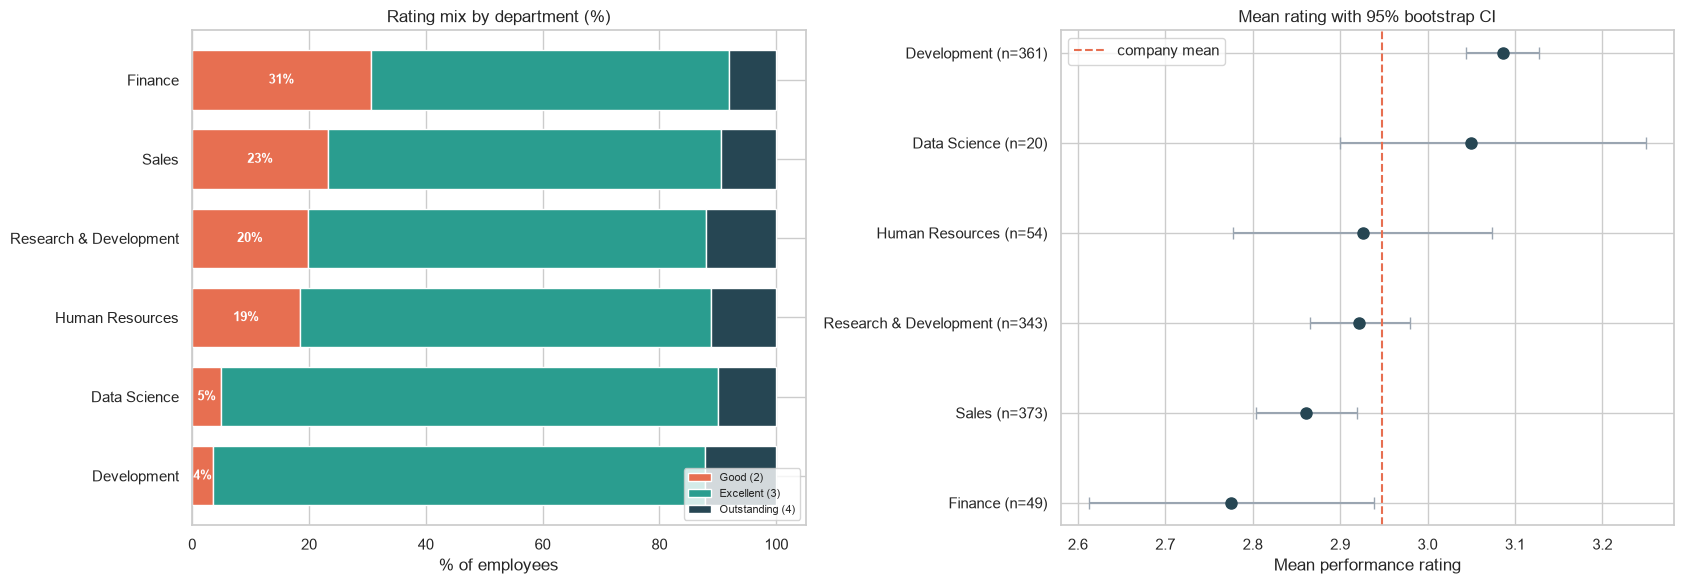

💡 Wide intervals (Data Science, Finance, HR) = small samples → rank them with caution. Development, Sales and R&D are solid, high-n comparisons.


In [9]:
import os, joblib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

ARTIFACT_DIR = 'artifacts'
def load_artifact(name, made_in):
    path = os.path.join(ARTIFACT_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ '{path}' not found (cwd = {os.getcwd()}).\n   👉 Run {made_in} first — it creates this file.")
    return joblib.load(path)

sns.set_theme(style='whitegrid')
dept = load_artifact('dept_summary.pkl', 'Section 5 (department summary cell)')

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# (a) rating mix — 100% stacked
mix = dept[['pct_Good', 'pct_Excellent', 'pct_Outstanding']].sort_values('pct_Good')
mix.columns = ['Good (2)', 'Excellent (3)', 'Outstanding (4)']
mix.plot(kind='barh', stacked=True, ax=axes[0], color=['#e76f51', '#2a9d8f', '#264653'], width=0.75)
for i, (d, row) in enumerate(mix.iterrows()):
    axes[0].text(row.iloc[0] / 2, i, f'{row.iloc[0]:.0f}%', ha='center', va='center', color='white', fontsize=9, fontweight='bold')
axes[0].set_title('Rating mix by department (%)'); axes[0].set_xlabel('% of employees'); axes[0].set_ylabel('')
axes[0].legend(loc='lower right', fontsize=8)

# (b) mean rating with bootstrap CI
d2 = dept.sort_values('mean_rating')
axes[1].errorbar(d2['mean_rating'], range(len(d2)), xerr=[d2['mean_rating'] - d2['ci_low'], d2['ci_high'] - d2['mean_rating']],
                 fmt='o', color='#264653', ecolor='#9aa5b1', capsize=4, markersize=8)
axes[1].axvline(dept['mean_rating'].mul(dept['headcount']).sum() / dept['headcount'].sum(), color='#e76f51', ls='--', label='company mean')
axes[1].set_yticks(range(len(d2))); axes[1].set_yticklabels([f'{d} (n={int(n)})' for d, n in zip(d2.index, d2.headcount)])
axes[1].set_title('Mean rating with 95% bootstrap CI'); axes[1].set_xlabel('Mean performance rating'); axes[1].legend()
plt.tight_layout(); plt.show()
print('💡 Wide intervals (Data Science, Finance, HR) = small samples → rank them with caution. Development, Sales and R&D are solid, high-n comparisons.')

### 5.1 Why do departments differ? Roles and drivers
Two questions: *which job roles drive the gap?* and *do departments differ because their employees are less satisfied — or despite similar satisfaction?*

In [10]:
import os, joblib
import numpy as np, pandas as pd

ARTIFACT_DIR = 'artifacts'
def load_artifact(name, made_in):
    path = os.path.join(ARTIFACT_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ '{path}' not found (cwd = {os.getcwd()}).\n   👉 Run {made_in} first — it creates this file.")
    return joblib.load(path)

df = load_artifact('clean_df.pkl', 'Section 3')
T = 'PerformanceRating'
df['is_Good'] = (df[T] == 2)
df['low_env'] = df['EmpEnvironmentSatisfaction'] <= 2            # "Low" or "Medium" environment satisfaction

# ─── Job roles (min 15 people so averages mean something) ────────────────
roles = df.groupby(['EmpDepartment', 'EmpJobRole']).agg(n=(T, 'size'), mean_rating=(T, 'mean'), pct_Good=('is_Good', lambda s: 100 * s.mean()))
roles = roles[roles.n >= 15].sort_values('mean_rating')
print('👔 JOB ROLES (n ≥ 15) — 5 lowest and 5 highest mean rating')
print(pd.concat([roles.head(5), roles.tail(5)]).round(2).to_string())

# ─── Department drivers ──────────────────────────────────────────────────
g = df.groupby('EmpDepartment')
drivers = pd.DataFrame({
    'headcount': g.size(),
    'pct_Good': g['is_Good'].mean() * 100,
    'pct_low_env_sat': g['low_env'].mean() * 100,
    'pct_Good_if_low_env': df[df.low_env].groupby('EmpDepartment')['is_Good'].mean() * 100,
    'pct_Good_if_ok_env': df[~df.low_env].groupby('EmpDepartment')['is_Good'].mean() * 100,
    'avg_salary_hike_%': g['EmpLastSalaryHikePercent'].mean(),
    'avg_yrs_since_promo': g['YearsSinceLastPromotion'].mean(),
}).sort_values('pct_Good', ascending=False)
print('\n🔬 DEPARTMENT DRIVER PROFILE  (low_env = Environment Satisfaction ≤ 2)')
print(drivers.round(1).to_string())

print('\n💡 Reading the table:')
print(f"   • Employees with environment satisfaction ≥ 3 are almost never rated Good: {100 * df[~df.low_env].is_Good.mean():.1f}% vs {100 * df[df.low_env].is_Good.mean():.1f}% when ≤ 2.")
print('   • The share of low-satisfaction staff is similar across departments (~30–43%),')
print('     but the chance that a low-satisfaction employee ends up rated Good differs a lot by department → department culture / management matters on top of satisfaction.')

👔 JOB ROLES (n ≥ 15) — 5 lowest and 5 highest mean rating
                                                    n  mean_rating  pct_Good
EmpDepartment          EmpJobRole                                           
Finance                Finance Manager             49         2.78     30.61
Research & Development Senior Manager R&D          15         2.80     26.67
                       Healthcare Representative   33         2.85     24.24
Sales                  Sales Executive            270         2.86     23.70
Research & Development Laboratory Technician       64         2.86     21.88
Development            Senior Developer            52         3.00     11.54
Data Science           Data Scientist              20         3.05      5.00
Development            Technical Lead              38         3.08      2.63
                       Developer                  236         3.11      2.54
                       Business Analyst            16         3.19      0.00

🔬 DEPARTMENT DRIV

**Deliverable 1 — findings**

| Rank (best → worst by mean rating) | Department | Headcount | Mean rating | % rated *Good (2)* |
|---|---|---|---|---|
| 1 | **Development** | 361 | 3.09 | 3.6% |
| 2 | Data Science *(n = 20 — low confidence)* | 20 | 3.05 | 5.0% |
| 3 | Human Resources | 54 | 2.93 | 18.5% |
| 4 | Research & Development | 343 | 2.92 | 19.8% |
| 5 | **Sales** | 373 | 2.86 | 23.3% |
| 6 | **Finance** | 49 | 2.78 | 30.6% |

- Department differences are **statistically significant** (χ² p ≈ 4×10⁻¹¹, Kruskal–Wallis p ≈ 2×10⁻⁸).
- **Development is the clear top performer** and **Sales and Finance are the weakest.** Sales is the department that matters most commercially: it is the second-largest (373 staff) and 1 in 4 of its people is rated Good (2).
- Where the volume is, the picture is robust: Development (361), Sales (373) and R&D (343) have narrow confidence intervals, and Development vs. Sales/R&D differ significantly.
- The two small departments at the extremes (Data Science at the top, Finance at the bottom) should be read as *indicative*, not conclusive.

## 6️⃣ What separates performance levels? (bivariate analysis)
We now test every feature against the target with the right statistic for its type:
- **numeric / ordinal features** → Spearman rank correlation (+ Kruskal–Wallis across the 3 rating groups)
- **nominal features** → chi-square test of independence with Cramér's V as the effect size

In [11]:
import os, joblib
import numpy as np, pandas as pd
from scipy import stats

ARTIFACT_DIR = 'artifacts'
def load_artifact(name, made_in):
    path = os.path.join(ARTIFACT_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ '{path}' not found (cwd = {os.getcwd()}).\n   👉 Run {made_in} first — it creates this file.")
    return joblib.load(path)

def ascii_bar(label, value, max_value, width=30, text=None):
    n = int(round(width * value / max_value)) if max_value > 0 else 0
    print(f'   {label:<30} {"█" * n:<{width}} {text if text is not None else value}')

df = load_artifact('clean_df.pkl', 'Section 3')
schema = load_artifact('schema.pkl', 'Section 3')
T = 'PerformanceRating'
num_cols = schema['NUMERIC'] + schema['ORDINAL']

# ─── Numeric + ordinal ───────────────────────────────────────────────────
rows = []
for c in num_cols:
    rho, p_rho = stats.spearmanr(df[c], df[T])
    _, p_kw = stats.kruskal(*[g[c].values for _, g in df.groupby(T)])
    rows.append((c, rho, abs(rho), p_rho, p_kw))
num_assoc = pd.DataFrame(rows, columns=['feature', 'spearman_rho', 'abs_rho', 'p_spearman', 'p_kruskal']).sort_values('abs_rho', ascending=False)
num_assoc['significant'] = np.where(num_assoc.p_spearman < 0.05, '✅', '')

print('📈 NUMERIC / ORDINAL FEATURES vs PerformanceRating (sorted by |ρ|)\n')
print(num_assoc.drop(columns='abs_rho').round(4).to_string(index=False))
print('\n   |Spearman ρ|')
for _, r in num_assoc.head(10).iterrows():
    ascii_bar(r.feature, r.abs_rho, num_assoc.abs_rho.max(), text=f'{r.spearman_rho:+.3f}')

# ─── Nominal ─────────────────────────────────────────────────────────────
rows = []
for c in schema['NOMINAL']:
    ct = pd.crosstab(df[c], df[T])
    chi2, p, _, _ = stats.chi2_contingency(ct)
    rows.append((c, np.sqrt(chi2 / (len(df) * (min(ct.shape) - 1))), p))
cat_assoc = pd.DataFrame(rows, columns=['feature', 'cramers_v', 'p_chi2']).sort_values('cramers_v', ascending=False)
cat_assoc['significant'] = np.where(cat_assoc.p_chi2 < 0.05, '✅', '')
print('\n\n🏷️  NOMINAL FEATURES vs PerformanceRating (sorted by Cramér\'s V)\n')
print(cat_assoc.round(4).to_string(index=False))

joblib.dump({'numeric': num_assoc, 'nominal': cat_assoc}, os.path.join(ARTIFACT_DIR, 'assoc_tables.pkl'))
print('\n💡 Three variables stand out far above the rest: EnvironmentSatisfaction, LastSalaryHikePercent, YearsSinceLastPromotion.')
print('   Gender, marital status, education, business travel and attrition show NO significant relationship with performance.')

📈 NUMERIC / ORDINAL FEATURES vs PerformanceRating (sorted by |ρ|)

                     feature  spearman_rho  p_spearman  p_kruskal significant
  EmpEnvironmentSatisfaction        0.3966      0.0000     0.0000           ✅
    EmpLastSalaryHikePercent        0.2737      0.0000     0.0000           ✅
     YearsSinceLastPromotion       -0.2697      0.0000     0.0000           ✅
ExperienceYearsInCurrentRole       -0.1661      0.0000     0.0000           ✅
        YearsWithCurrManager       -0.1350      0.0000     0.0000           ✅
ExperienceYearsAtThisCompany       -0.1325      0.0000     0.0000           ✅
          EmpWorkLifeBalance        0.1137      0.0001     0.0001           ✅
                 EmpJobLevel       -0.0808      0.0051     0.0038           ✅
  TotalWorkExperienceInYears       -0.0743      0.0100     0.0085           ✅
               EmpHourlyRate       -0.0448      0.1205     0.2239            
          NumCompaniesWorked        0.0383      0.1854     0.4102          

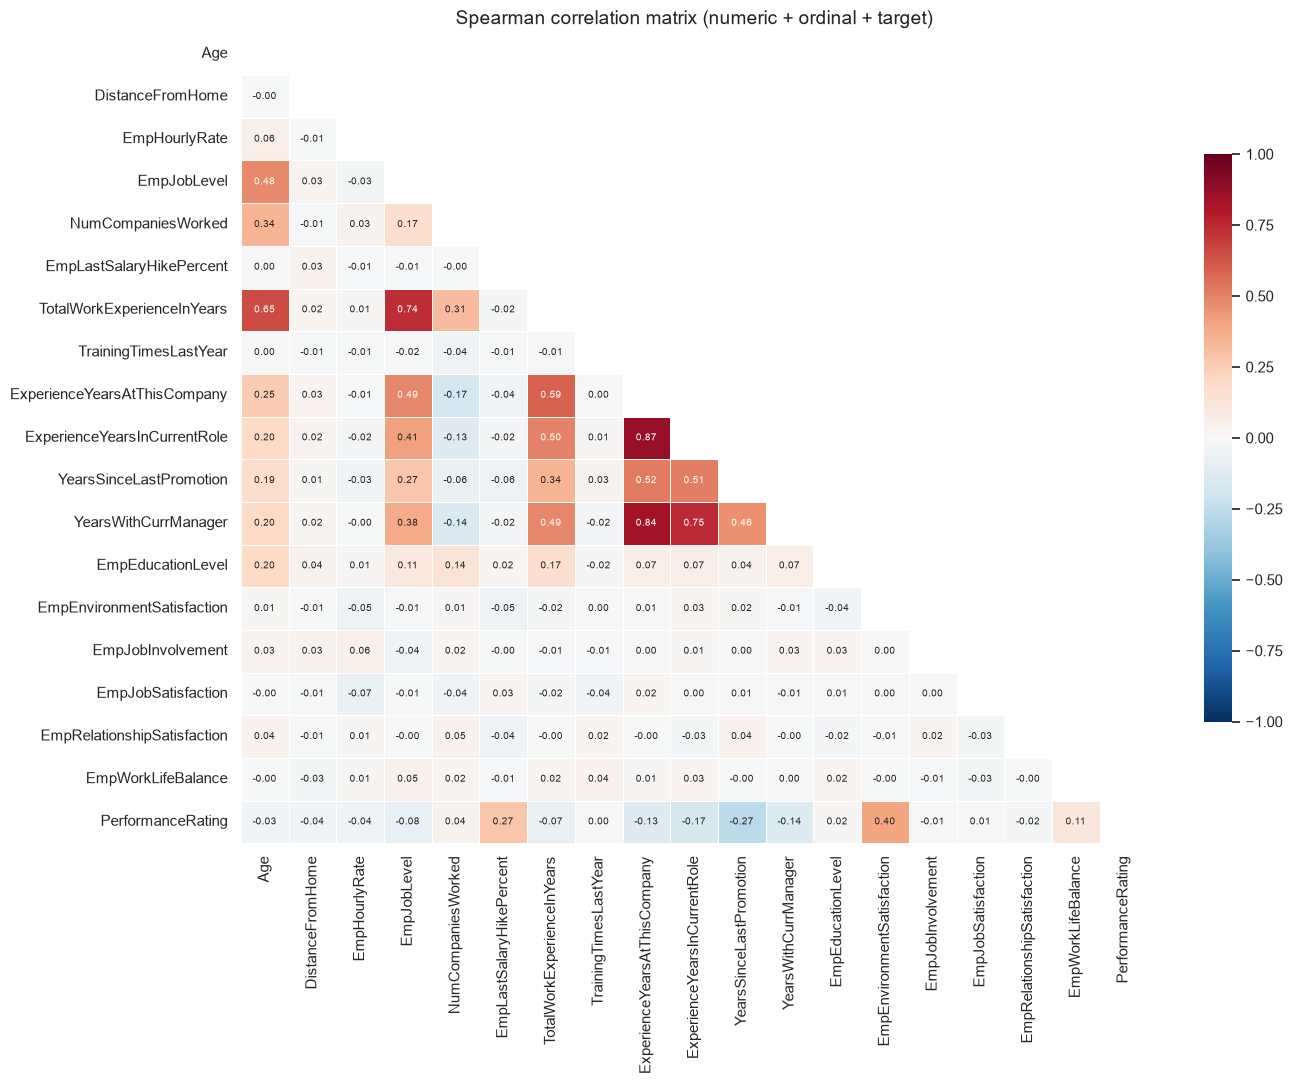

🔗 Strongly inter-correlated feature pairs (|ρ| ≥ 0.6):
                   feature_a                    feature_b  rho
ExperienceYearsInCurrentRole ExperienceYearsAtThisCompany 0.87
        YearsWithCurrManager ExperienceYearsAtThisCompany 0.84
        YearsWithCurrManager ExperienceYearsInCurrentRole 0.75
  TotalWorkExperienceInYears                  EmpJobLevel 0.74
  TotalWorkExperienceInYears                          Age 0.65

💡 Tenure / age / job-level variables move together. This does not hurt tree-based models, but we must use
   GROUPED / permutation-based importance later so that shared signal is not misattributed.


In [12]:
import os, joblib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

ARTIFACT_DIR = 'artifacts'
def load_artifact(name, made_in):
    path = os.path.join(ARTIFACT_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ '{path}' not found (cwd = {os.getcwd()}).\n   👉 Run {made_in} first — it creates this file.")
    return joblib.load(path)

sns.set_theme(style='white')
df = load_artifact('clean_df.pkl', 'Section 3')
schema = load_artifact('schema.pkl', 'Section 3')

cols = schema['NUMERIC'] + schema['ORDINAL'] + ['PerformanceRating']
corr = df[cols].corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.4, annot_kws={'size': 7}, cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title('Spearman correlation matrix (numeric + ordinal + target)', fontsize=14)
plt.tight_layout(); plt.show()

# Strongly inter-correlated pairs (multicollinearity watch-list)
pairs = corr.where(~mask).stack().reset_index()
pairs.columns = ['feature_a', 'feature_b', 'rho']
strong = pairs[(pairs.rho.abs() >= 0.6) & (pairs.feature_a != 'PerformanceRating') & (pairs.feature_b != 'PerformanceRating')]
print('🔗 Strongly inter-correlated feature pairs (|ρ| ≥ 0.6):')
print(strong.sort_values('rho', key=abs, ascending=False).round(2).to_string(index=False))
print('\n💡 Tenure / age / job-level variables move together. This does not hurt tree-based models, but we must use')
print('   GROUPED / permutation-based importance later so that shared signal is not misattributed.')

##### 📝 Observation — what is related to performance
- Three variables stand clearly above all others: **environment satisfaction** (Spearman ρ ≈ +0.40), **last salary-hike %** (ρ ≈ +0.27) and **years since last promotion** (ρ ≈ −0.27). Every other numeric/ordinal variable has |ρ| below 0.17.
- Among the nominal variables, **job role** and **department** have the strongest (still modest) association with the rating (Cramér's V ≈ 0.20 and 0.17). **Overtime** is statistically significant but weak (V ≈ 0.10).
- **Gender, education background, marital status, business travel and attrition show no significant relationship with performance** (all p > 0.05) — so there is no sign of a gender or marital-status effect in the ratings.
- Tenure, age and job level move together (the heatmap above), which does not hurt tree-based models but is the reason Section 13 uses *grouped* and *permutation* importance instead of trusting one method.

### 6.1 The three strongest signals — how the rating mix changes

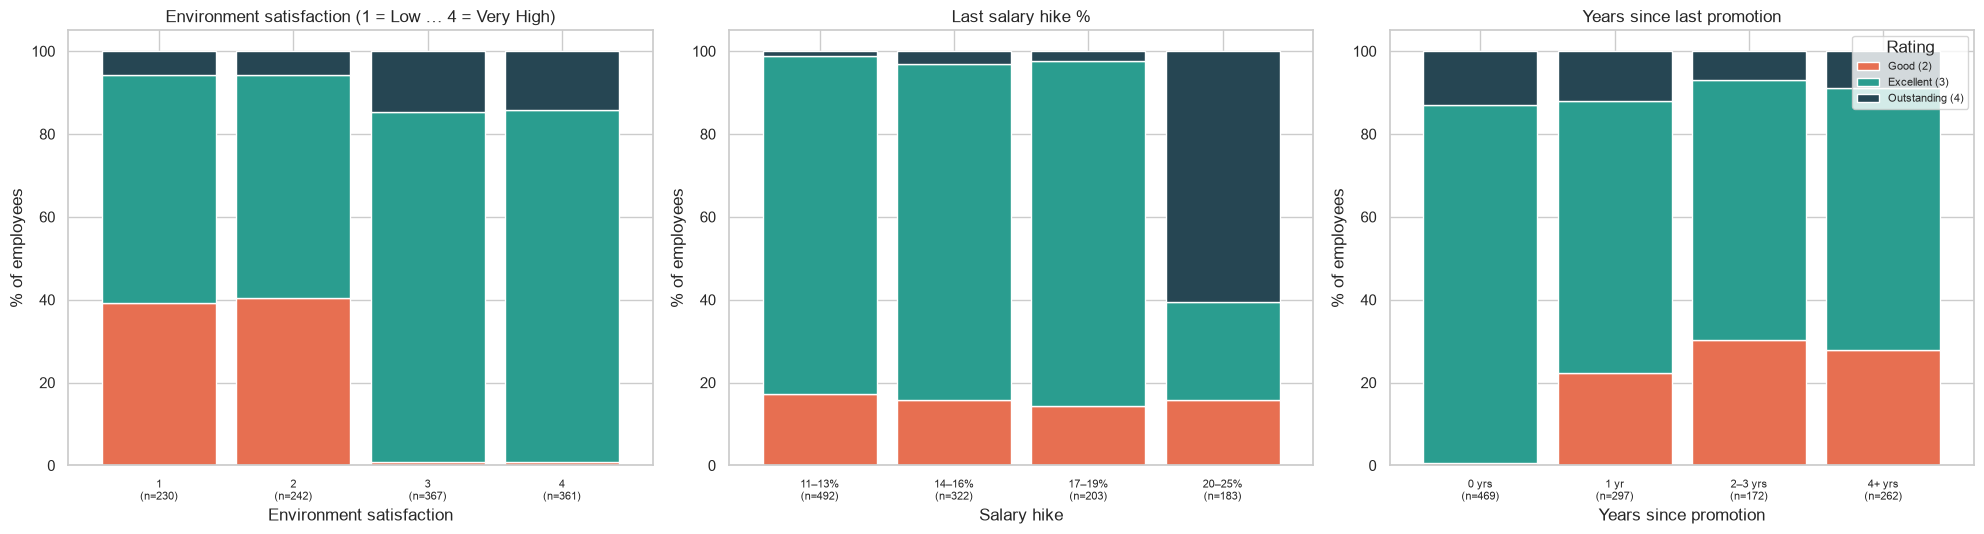

🔎 Key numbers
   • Environment satisfaction 1–2 → 40% rated Good;  3–4 → 0.8% rated Good
   • Salary hike ≥ 20% → 61% rated Outstanding;  ≤ 19% → 2%
   • Promoted this year → 1% Good;  4+ years ago → 28% Good

💡 The salary-hike pattern is a sharp STEP at 20%, not a gentle slope → this looks like a pay-for-performance rule
   (big raises are given TO outstanding performers). That is a hint of reverse causality — discussed in Section 19.


In [13]:
import os, joblib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

ARTIFACT_DIR = 'artifacts'
def load_artifact(name, made_in):
    path = os.path.join(ARTIFACT_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ '{path}' not found (cwd = {os.getcwd()}).\n   👉 Run {made_in} first — it creates this file.")
    return joblib.load(path)

sns.set_theme(style='whitegrid')
df = load_artifact('clean_df.pkl', 'Section 3')
T = 'PerformanceRating'
colors = ['#e76f51', '#2a9d8f', '#264653']

def mix_by(group, ax, title, xlabel):
    mix = pd.crosstab(group, df[T], normalize='index') * 100
    n = group.value_counts().reindex(mix.index)
    mix.columns = ['Good (2)', 'Excellent (3)', 'Outstanding (4)']
    mix.plot(kind='bar', stacked=True, ax=ax, color=colors, width=0.85, legend=False)
    ax.set_xticklabels([f'{i}\n(n={n[i]})' for i in mix.index], rotation=0, fontsize=8)
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel('% of employees')
    return mix

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
m1 = mix_by(df['EmpEnvironmentSatisfaction'], axes[0], 'Environment satisfaction (1 = Low … 4 = Very High)', 'Environment satisfaction')
hike_bins = pd.cut(df['EmpLastSalaryHikePercent'], [10, 13, 16, 19, 25], labels=['11–13%', '14–16%', '17–19%', '20–25%'])
m2 = mix_by(hike_bins, axes[1], 'Last salary hike %', 'Salary hike')
promo_bins = pd.cut(df['YearsSinceLastPromotion'], [-1, 0, 1, 3, 15], labels=['0 yrs', '1 yr', '2–3 yrs', '4+ yrs'])
m3 = mix_by(promo_bins, axes[2], 'Years since last promotion', 'Years since promotion')
axes[2].legend(title='Rating', loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()

print('🔎 Key numbers')
print(f'   • Environment satisfaction 1–2 → {m1.loc[[1, 2], "Good (2)"].mean():.0f}% rated Good;  3–4 → {m1.loc[[3, 4], "Good (2)"].mean():.1f}% rated Good')
print(f'   • Salary hike ≥ 20% → {m2.loc["20–25%", "Outstanding (4)"]:.0f}% rated Outstanding;  ≤ 19% → {100 * (df.loc[hike_bins != "20–25%", T] == 4).mean():.0f}%')
print(f'   • Promoted this year → {m3.loc["0 yrs", "Good (2)"]:.0f}% Good;  4+ years ago → {m3.loc["4+ yrs", "Good (2)"]:.0f}% Good')
print('\n💡 The salary-hike pattern is a sharp STEP at 20%, not a gentle slope → this looks like a pay-for-performance rule')
print('   (big raises are given TO outstanding performers). That is a hint of reverse causality — discussed in Section 19.')

## 7️⃣ Feature engineering & train / test split
**Encoding:** nominal columns are one-hot encoded (`drop_first=True`); ordinal and numeric columns are kept as numbers. `EmpNumber` (an ID) is dropped.

**Engineered features** (six ratio / index features, each with a business rationale) are built *alongside* the base set. Whether they are *used* is decided by evidence in Section 8 — not assumed.

| Feature | Idea |
|---|---|
| `TenureRatio` | share of the career spent at this company (loyalty / lateral hires) |
| `PromoLag` | time since promotion relative to tenure (stagnation) |
| `AvgTenurePerCompany` | job-hopping tendency |
| `SatisfactionIndex` | mean of the four satisfaction / balance scores |
| `ManagerStability` | share of tenure spent with the current manager |
| `RoleStagnation` | share of tenure spent in the current role |

**Split:** 80 / 20, **stratified** on the target so the minority classes appear in both parts. The test set is locked away and only used for final evaluation — all tuning and model selection use cross-validation **inside the training set**, so the test score is an honest estimate.

In [14]:
import os, joblib
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split

ARTIFACT_DIR = 'artifacts'
RANDOM_STATE = 42
TEST_SIZE = 0.20
LABEL_MAP = {2: 0, 3: 1, 4: 2}                       # original rating -> class id
CLASS_NAMES = ['Good (2)', 'Excellent (3)', 'Outstanding (4)']

def load_artifact(name, made_in):
    path = os.path.join(ARTIFACT_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ '{path}' not found (cwd = {os.getcwd()}).\n   👉 Run {made_in} first — it creates this file.")
    return joblib.load(path)

def ascii_bar(label, value, max_value, width=30, text=None):
    n = int(round(width * value / max_value)) if max_value > 0 else 0
    print(f'   {label:<10} {"█" * n:<{width}} {text if text is not None else value}')

def build_features(frame, categories, engineered):
    # Same function is re-used at prediction time (Section 17) — categories are FIXED from training data
    X = frame.drop(columns=[c for c in ['EmpNumber', 'PerformanceRating', 'PerformanceLabel'] if c in frame.columns]).copy()
    if engineered:
        X['TenureRatio'] = X['ExperienceYearsAtThisCompany'] / (X['TotalWorkExperienceInYears'] + 1)
        X['PromoLag'] = X['YearsSinceLastPromotion'] / (X['ExperienceYearsAtThisCompany'] + 1)
        X['AvgTenurePerCompany'] = X['TotalWorkExperienceInYears'] / (X['NumCompaniesWorked'] + 1)
        X['SatisfactionIndex'] = X[['EmpEnvironmentSatisfaction', 'EmpJobSatisfaction',
                                    'EmpRelationshipSatisfaction', 'EmpWorkLifeBalance']].mean(axis=1)
        X['ManagerStability'] = X['YearsWithCurrManager'] / (X['ExperienceYearsAtThisCompany'] + 1)
        X['RoleStagnation'] = X['ExperienceYearsInCurrentRole'] / (X['ExperienceYearsAtThisCompany'] + 1)
    for col, cats in categories.items():
        X[col] = pd.Categorical(X[col], categories=cats)
    return pd.get_dummies(X, columns=list(categories), drop_first=True, dtype=float)

df = load_artifact('clean_df.pkl', 'Section 3')
schema = load_artifact('schema.pkl', 'Section 3')

categories = {c: sorted(df[c].unique().tolist()) for c in schema['NOMINAL']}
X_base = build_features(df, categories, engineered=False)
X_eng = build_features(df, categories, engineered=True)
y = df['PerformanceRating'].map(LABEL_MAP)

# Safety checks — fail loudly instead of training on bad data
assert not X_eng.isnull().any().any(), '❌ NaN found in engineered features'
assert np.isfinite(X_eng.values).all(), '❌ inf found in engineered features'
assert y.notnull().all(), f'❌ unmapped ratings: {sorted(df.PerformanceRating.unique())}'

idx = np.arange(len(df))
train_idx, test_idx = train_test_split(idx, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)

feature_sets = dict(X_base=X_base, X_eng=X_eng, y=y, train_idx=train_idx, test_idx=test_idx,
                    categories=categories, label_map=LABEL_MAP, class_names=CLASS_NAMES)
joblib.dump(feature_sets, os.path.join(ARTIFACT_DIR, 'feature_sets.pkl'))

print(f'✅ Base features       : {X_base.shape[1]}   |   Engineered set: {X_eng.shape[1]}  (+{X_eng.shape[1] - X_base.shape[1]})')
print(f'✅ Train / test        : {len(train_idx)} / {len(test_idx)} employees')
for name, subset in [('TRAIN', train_idx), ('TEST', test_idx)]:
    print(f'\n📊 Class balance — {name} (stratified, should look alike)')
    vc = y.iloc[subset].value_counts(normalize=True).sort_index() * 100
    for k, v in vc.items():
        ascii_bar(CLASS_NAMES[k].split()[0], v, 100, text=f'{v:5.1f}%')
print(f'\n💾 Saved → {ARTIFACT_DIR}/feature_sets.pkl')

✅ Base features       : 53   |   Engineered set: 59  (+6)
✅ Train / test        : 960 / 240 employees

📊 Class balance — TRAIN (stratified, should look alike)
   Good       █████                           16.1%
   Excellent  ██████████████████████          72.8%
   Outstanding ███                             11.0%

📊 Class balance — TEST (stratified, should look alike)
   Good       █████                           16.2%
   Excellent  ██████████████████████          72.9%
   Outstanding ███                             10.8%

💾 Saved → artifacts/feature_sets.pkl


## 8️⃣ Design-choice ablation — do engineered features or SMOTE actually help?
Two common "improvements" are tested rather than assumed, using **repeated stratified 5-fold CV on the training set only** (3 boosting models for robustness). A choice is adopted only if it improves mean macro-F1 by at least `MIN_GAIN = 0.005` — a guard against chasing noise.

- **SMOTE** (synthetic oversampling) is applied *inside* each CV fold via an `imblearn` pipeline, so synthetic rows never leak into validation data.

In [15]:
import os, joblib, warnings
import numpy as np, pandas as pd
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
warnings.filterwarnings('ignore')

ARTIFACT_DIR = 'artifacts'
RANDOM_STATE = 42
MIN_GAIN = 0.005

def load_artifact(name, made_in):
    path = os.path.join(ARTIFACT_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ '{path}' not found (cwd = {os.getcwd()}).\n   👉 Run {made_in} first — it creates this file.")
    return joblib.load(path)

fs = load_artifact('feature_sets.pkl', 'Section 7')
y_train = fs['y'].iloc[fs['train_idx']]
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=RANDOM_STATE)

def make_models():
    return {
        'LightGBM': LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=15, random_state=RANDOM_STATE, n_jobs=1, verbose=-1),
        'XGBoost': XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                                 random_state=RANDOM_STATE, n_jobs=1, eval_metric='mlogloss'),
        'GradientBoosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    }

def cv_scores(X_train, use_smote):
    out = {}
    for name, model in make_models().items():
        est = ImbPipeline([('smote', SMOTE(random_state=RANDOM_STATE)), ('clf', model)]) if use_smote else model
        out[name] = cross_val_score(est, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=1).mean()
    return out

X_base_tr = fs['X_base'].iloc[fs['train_idx']]
X_eng_tr = fs['X_eng'].iloc[fs['train_idx']]

print('⏳ Running ablation (this takes ~1–2 minutes)…')
res_base = cv_scores(X_base_tr, use_smote=False)
res_eng = cv_scores(X_eng_tr, use_smote=False)

use_engineered = (np.mean(list(res_eng.values())) - np.mean(list(res_base.values()))) >= MIN_GAIN
chosen_tr = X_eng_tr if use_engineered else X_base_tr
res_nosmote = res_eng if use_engineered else res_base
res_smote = cv_scores(chosen_tr, use_smote=True)
use_smote = (np.mean(list(res_smote.values())) - np.mean(list(res_nosmote.values()))) >= MIN_GAIN

table = pd.DataFrame({'base features': res_base, '+ engineered': res_eng, 'no SMOTE': res_nosmote, '+ SMOTE': res_smote})
table.loc['MEAN'] = table.mean()
print('\n📊 CV macro-F1 (training set only)\n')
print(table.round(4).to_string())

gain_eng = table.loc['MEAN', '+ engineered'] - table.loc['MEAN', 'base features']
gain_smote = table.loc['MEAN', '+ SMOTE'] - table.loc['MEAN', 'no SMOTE']
print(f'\n🔎 Engineered features : {gain_eng:+.4f} macro-F1  →  {"✅ ADOPTED" if use_engineered else "❌ not adopted (gain < " + str(MIN_GAIN) + ")"}')
print(f'🔎 SMOTE               : {gain_smote:+.4f} macro-F1  →  {"✅ ADOPTED" if use_smote else "❌ not adopted (gain < " + str(MIN_GAIN) + ")"}')

joblib.dump({'use_engineered': bool(use_engineered), 'use_smote': bool(use_smote), 'ablation_table': table},
            os.path.join(ARTIFACT_DIR, 'design_choices.pkl'))
print(f'\n💾 Saved → {ARTIFACT_DIR}/design_choices.pkl  (all later sections read these two flags)')

⏳ Running ablation (this takes ~1–2 minutes)…

📊 CV macro-F1 (training set only)

                  base features  + engineered  no SMOTE  + SMOTE
LightGBM                 0.8925        0.8814    0.8925   0.8828
XGBoost                  0.8890        0.8850    0.8890   0.8800
GradientBoosting         0.8882        0.8843    0.8882   0.8727
MEAN                     0.8899        0.8836    0.8899   0.8785

🔎 Engineered features : -0.0063 macro-F1  →  ❌ not adopted (gain < 0.005)
🔎 SMOTE               : -0.0114 macro-F1  →  ❌ not adopted (gain < 0.005)

💾 Saved → artifacts/design_choices.pkl  (all later sections read these two flags)



📊 CV macro-F1 (training set only)

                  base features  + engineered  no SMOTE  + SMOTE
LightGBM                 0.8925        0.8814    0.8925   0.8811
XGBoost                  0.8888        0.8859    0.8888   0.8791
GradientBoosting         0.8882        0.8843    0.8882   0.8697
MEAN                     0.8898        0.8839    0.8898   0.8766

🔎 Engineered features : -0.0060 macro-F1  →  ❌ not adopted (gain < 0.005)
🔎 SMOTE               : -0.0132 macro-F1  →  ❌ not adopted (gain < 0.005)

💾 Saved → artifacts/design_choices.pkl  (all later sections read these two flags)


**Reading the ablation:** the base features already carry the signal — the engineered ratios and SMOTE do not provide a meaningful gain, so the leaner, more interpretable base feature set without resampling is used. (If you change data or settings and the gain exceeds the threshold, the flags flip automatically and every later section follows.)

## 9️⃣ Baseline models
Eight model families are compared with **stratified 5-fold CV on the training set** plus a hold-out evaluation. A *majority-class* dummy is included as a floor — any real model must beat it.

`evaluate_model()` is the reusable helper used throughout: it cross-validates, fits, predicts, and reports accuracy, **balanced accuracy, macro-F1, MCC, Cohen's κ and one-vs-rest ROC-AUC**.

In [16]:
import os, time, joblib, warnings
import numpy as np, pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
                             matthews_corrcoef, cohen_kappa_score, roc_auc_score)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
warnings.filterwarnings('ignore')

ARTIFACT_DIR = 'artifacts'
RANDOM_STATE = 42

def load_artifact(name, made_in):
    path = os.path.join(ARTIFACT_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ '{path}' not found (cwd = {os.getcwd()}).\n   👉 Run {made_in} first — it creates this file.")
    return joblib.load(path)

def load_splits():
    fs, dc = load_artifact('feature_sets.pkl', 'Section 7'), load_artifact('design_choices.pkl', 'Section 8')
    X = fs['X_eng'] if dc['use_engineered'] else fs['X_base']
    tr, te = fs['train_idx'], fs['test_idx']
    return X.iloc[tr], X.iloc[te], fs['y'].iloc[tr], fs['y'].iloc[te], dc

def wrap(model, use_smote):
    return ImbPipeline([('smote', SMOTE(random_state=RANDOM_STATE)), ('clf', model)]) if use_smote else model

def evaluate_model(model, X_tr, X_te, y_tr, y_te, name, cv=None, verbose=True):
    t0 = time.time()
    cv_mean = cv_std = np.nan
    if cv is not None:
        scores = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='f1_macro', n_jobs=1)
        cv_mean, cv_std = scores.mean(), scores.std()
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te) if hasattr(model, 'predict_proba') else None
    res = {
        'model': name, 'cv_f1_macro': cv_mean, 'cv_std': cv_std,
        'accuracy': accuracy_score(y_te, pred), 'balanced_acc': balanced_accuracy_score(y_te, pred),
        'precision_macro': precision_score(y_te, pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_te, pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_te, pred, average='macro'), 'f1_weighted': f1_score(y_te, pred, average='weighted'),
        'mcc': matthews_corrcoef(y_te, pred), 'kappa': cohen_kappa_score(y_te, pred),
        'roc_auc_ovr': roc_auc_score(y_te, proba, multi_class='ovr', average='macro') if proba is not None else np.nan,
        'seconds': time.time() - t0,
    }
    if verbose:
        print(f"   ✅ {name:<20} CV-F1 {cv_mean:.3f}±{cv_std:.3f} | test acc {res['accuracy']:.3f} | bal-acc {res['balanced_acc']:.3f} | "
              f"F1-macro {res['f1_macro']:.3f} | AUC {res['roc_auc_ovr']:.3f} | {res['seconds']:.0f}s")
    return res, model

def ascii_bar(label, value, max_value, width=30, text=None):
    n = int(round(width * value / max_value)) if max_value > 0 else 0
    print(f'   {label:<20} {"█" * n:<{width}} {text if text is not None else value}')

X_train, X_test, y_train, y_test, dc = load_splits()
use_smote = dc['use_smote']
print(f'📐 Train {X_train.shape} | Test {X_test.shape} | engineered={dc["use_engineered"]} | SMOTE={use_smote}\n')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
models = {
    'Majority (dummy)':     DummyClassifier(strategy='most_frequent'),
    'Logistic Regression':  make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
    'KNN (k=7)':            make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=7)),
    'SVM (RBF)':            make_pipeline(StandardScaler(), SVC(probability=True, random_state=RANDOM_STATE)),
    'Decision Tree':        DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    'Random Forest':        RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=1),
    'Gradient Boosting':    GradientBoostingClassifier(random_state=RANDOM_STATE),
    'XGBoost':              XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                                          random_state=RANDOM_STATE, n_jobs=1, eval_metric='mlogloss'),
    'LightGBM':             LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=15, random_state=RANDOM_STATE, n_jobs=1, verbose=-1),
}

print('🏁 BASELINE COMPARISON')
rows = []
for name, model in models.items():
    res, _ = evaluate_model(wrap(model, use_smote), X_train, X_test, y_train, y_test, name, cv=cv)
    rows.append(res)

baseline = pd.DataFrame(rows).sort_values('cv_f1_macro', ascending=False).reset_index(drop=True)
print('\n📊 Ranking by CV macro-F1 (training set)\n')
for _, r in baseline.iterrows():
    ascii_bar(r.model, r.cv_f1_macro, baseline.cv_f1_macro.max(), text=f'{r.cv_f1_macro:.3f}')
print()
print(baseline.drop(columns=['seconds']).round(3).to_string(index=False))

joblib.dump(baseline, os.path.join(ARTIFACT_DIR, 'baseline_results.pkl'))
best = baseline.iloc[0]
print(f'\n🏆 Best baseline: {best.model}  (CV macro-F1 {best.cv_f1_macro:.3f})  vs majority floor {baseline.loc[baseline.model == "Majority (dummy)", "cv_f1_macro"].iloc[0]:.3f}')
print('💡 Gradient-boosted trees dominate; linear models and distance-based models cannot capture the threshold-like relationships we saw in EDA.')

📐 Train (960, 53) | Test (240, 53) | engineered=False | SMOTE=False

🏁 BASELINE COMPARISON
   ✅ Majority (dummy)     CV-F1 0.281±0.000 | test acc 0.729 | bal-acc 0.333 | F1-macro 0.281 | AUC 0.500 | 0s
   ✅ Logistic Regression  CV-F1 0.693±0.032 | test acc 0.825 | bal-acc 0.685 | F1-macro 0.717 | AUC 0.910 | 1s
   ✅ KNN (k=7)            CV-F1 0.377±0.026 | test acc 0.717 | bal-acc 0.365 | F1-macro 0.354 | AUC 0.663 | 0s
   ✅ SVM (RBF)            CV-F1 0.480±0.054 | test acc 0.783 | bal-acc 0.457 | F1-macro 0.495 | AUC 0.868 | 6s
   ✅ Decision Tree        CV-F1 0.850±0.013 | test acc 0.925 | bal-acc 0.889 | F1-macro 0.891 | AUC 0.940 | 0s
   ✅ Random Forest        CV-F1 0.861±0.021 | test acc 0.921 | bal-acc 0.823 | F1-macro 0.872 | AUC 0.960 | 9s
   ✅ Gradient Boosting    CV-F1 0.888±0.012 | test acc 0.938 | bal-acc 0.884 | F1-macro 0.905 | AUC 0.983 | 12s
   ✅ XGBoost              CV-F1 0.889±0.017 | test acc 0.925 | bal-acc 0.847 | F1-macro 0.878 | AUC 0.980 | 5s
   ✅ LightGBM       

   ✅ Logistic Regression  CV-F1 0.693±0.032 | test acc 0.825 | bal-acc 0.685 | F1-macro 0.717 | AUC 0.910 | 0s


   ✅ KNN (k=7)            CV-F1 0.377±0.026 | test acc 0.717 | bal-acc 0.365 | F1-macro 0.354 | AUC 0.663 | 0s


   ✅ SVM (RBF)            CV-F1 0.480±0.054 | test acc 0.783 | bal-acc 0.457 | F1-macro 0.495 | AUC 0.868 | 1s
   ✅ Decision Tree        CV-F1 0.850±0.013 | test acc 0.925 | bal-acc 0.889 | F1-macro 0.891 | AUC 0.940 | 0s


   ✅ Random Forest        CV-F1 0.861±0.021 | test acc 0.921 | bal-acc 0.823 | F1-macro 0.872 | AUC 0.960 | 3s


   ✅ Gradient Boosting    CV-F1 0.888±0.012 | test acc 0.938 | bal-acc 0.884 | F1-macro 0.905 | AUC 0.983 | 4s


   ✅ XGBoost              CV-F1 0.891±0.012 | test acc 0.933 | bal-acc 0.868 | F1-macro 0.893 | AUC 0.980 | 1s


   ✅ LightGBM             CV-F1 0.896±0.007 | test acc 0.929 | bal-acc 0.860 | F1-macro 0.889 | AUC 0.981 | 1s

📊 Ranking by CV macro-F1 (training set)

   LightGBM             ██████████████████████████████ 0.896
   XGBoost              ██████████████████████████████ 0.891
   Gradient Boosting    ██████████████████████████████ 0.888
   Random Forest        █████████████████████████████  0.861
   Decision Tree        ████████████████████████████   0.850
   Logistic Regression  ███████████████████████        0.693
   SVM (RBF)            ████████████████               0.480
   KNN (k=7)            █████████████                  0.377
   Majority (dummy)     █████████                      0.281

              model  cv_f1_macro  cv_std  accuracy  balanced_acc  precision_macro  recall_macro  f1_macro  f1_weighted   mcc  kappa  roc_auc_ovr
           LightGBM        0.896   0.007     0.929         0.860            0.925         0.860     0.889        0.928 0.830  0.827        0.981
       

##### 📝 Observation — baseline models
- The "always predict the most common rating" dummy scores a macro-F1 of only **≈ 0.28** although its accuracy is 73% — a clear floor that every real model must beat.
- **Tree-based models (Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM) reach a CV macro-F1 of ≈ 0.85 – 0.90**, while Logistic Regression reaches only ≈ 0.69 and the distance-based KNN and SVM are far lower (≈ 0.4 – 0.5; they suffer from the many irrelevant columns).
- The reason is in the EDA: the relationships are **threshold-like and interactive** (for example a sharp step at a 20% raise, and environment satisfaction ≥ 3 acting almost like a switch). Trees capture that easily; a straight-line model cannot. So here the extra complexity of boosted trees is justified by the evidence, not assumed.

## 🔟 Bayesian hyper-parameter tuning (Optuna)
The three strongest families — **XGBoost, LightGBM and Gradient Boosting** — are tuned with Optuna's TPE sampler (Bayesian optimisation). Each trial is scored by **5-fold CV macro-F1 on the training set**, so the test set is never touched.

> ⏱️ `N_TRIALS = 30` per model (a few minutes in total). Lower it for a quick run; raise it for a deeper search.
> ⚠️ The best CV score found by a search is slightly optimistic (selection bias) — the untouched test set in Section 11/12 gives the honest number.

🔍 Optuna TPE · 30 trials per model · objective = 5-fold CV macro-F1 · SMOTE=False

   ✅ LightGBM          best CV-F1 0.8936  (baseline 0.8958, Δ -0.0023)  [154s]
      params: {'n_estimators': 454, 'learning_rate': 0.013, 'num_leaves': 38, 'max_depth': 10, 'min_child_samples': 6, 'subsample': 0.8661, 'colsample_bytree': 0.6024, 'reg_alpha': 0.1997, 'reg_lambda': 2.1987}
   ✅ XGBoost           best CV-F1 0.9070  (baseline 0.8895, Δ +0.0175)  [77s]
      params: {'n_estimators': 208, 'learning_rate': 0.0197, 'max_depth': 3, 'min_child_weight': 1, 'subsample': 0.6213, 'colsample_bytree': 0.7008, 'gamma': 2.4117, 'reg_alpha': 0.032, 'reg_lambda': 0.0443}
   ✅ GradientBoosting  best CV-F1 0.9011  (baseline 0.8879, Δ +0.0133)  [702s]
      params: {'n_estimators': 257, 'learning_rate': 0.0219, 'max_depth': 4, 'min_samples_leaf': 2, 'subsample': 0.8893, 'max_features': None}


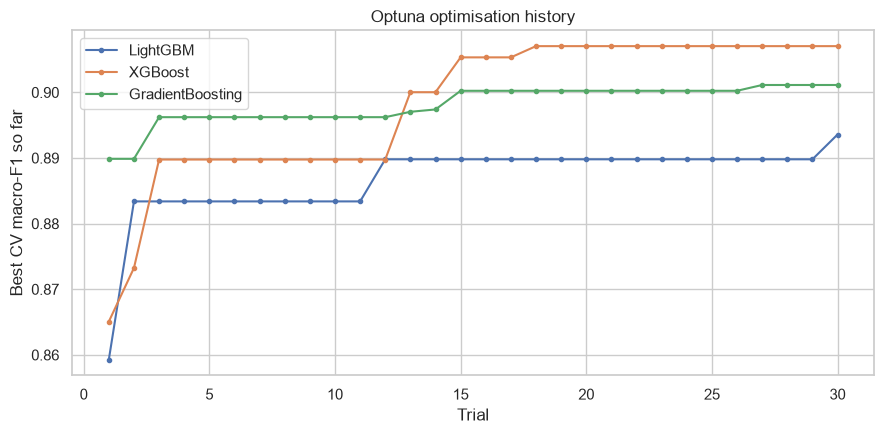


💾 Saved → artifacts/best_params.pkl


   ✅ GradientBoosting  best CV-F1 0.9040  (baseline 0.8879, Δ +0.0162)  [149s]
      params: {'n_estimators': 128, 'learning_rate': 0.0256, 'max_depth': 4, 'min_samples_leaf': 5, 'subsample': 0.8803, 'max_features': None}


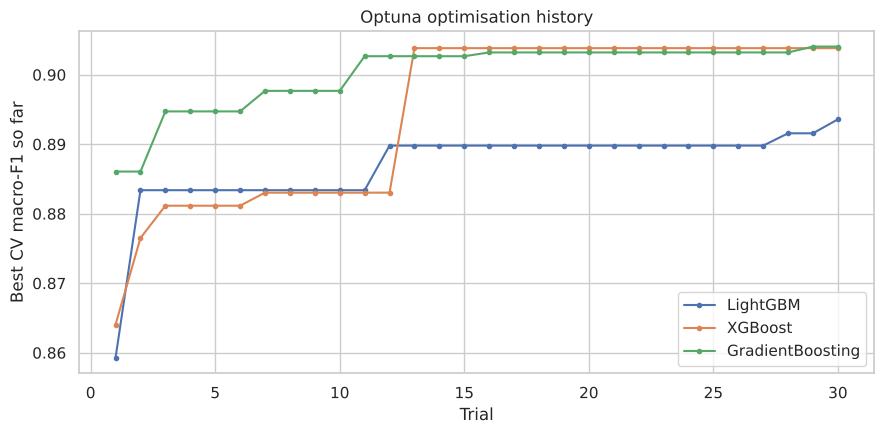


💾 Saved → artifacts/best_params.pkl


In [17]:
import os, time, joblib, warnings
import numpy as np, pandas as pd
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

ARTIFACT_DIR = 'artifacts'
RANDOM_STATE = 42
N_TRIALS = 30

def load_artifact(name, made_in):
    path = os.path.join(ARTIFACT_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ '{path}' not found (cwd = {os.getcwd()}).\n   👉 Run {made_in} first — it creates this file.")
    return joblib.load(path)

def load_splits():
    fs, dc = load_artifact('feature_sets.pkl', 'Section 7'), load_artifact('design_choices.pkl', 'Section 8')
    X = fs['X_eng'] if dc['use_engineered'] else fs['X_base']
    tr, te = fs['train_idx'], fs['test_idx']
    return X.iloc[tr], X.iloc[te], fs['y'].iloc[tr], fs['y'].iloc[te], dc

X_train, X_test, y_train, y_test, dc = load_splits()
use_smote = dc['use_smote']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def wrap(model):
    return ImbPipeline([('smote', SMOTE(random_state=RANDOM_STATE)), ('clf', model)]) if use_smote else model

def score(model):
    return cross_val_score(wrap(model), X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=1).mean()

def obj_lgbm(trial):
    p = dict(n_estimators=trial.suggest_int('n_estimators', 150, 600),
             learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
             num_leaves=trial.suggest_int('num_leaves', 4, 48),
             max_depth=trial.suggest_int('max_depth', 3, 10),
             min_child_samples=trial.suggest_int('min_child_samples', 5, 50),
             subsample=trial.suggest_float('subsample', 0.6, 1.0), subsample_freq=1,
             colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
             reg_alpha=trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
             reg_lambda=trial.suggest_float('reg_lambda', 1e-3, 10, log=True))
    return score(LGBMClassifier(**p, random_state=RANDOM_STATE, n_jobs=1, verbose=-1))

def obj_xgb(trial):
    p = dict(n_estimators=trial.suggest_int('n_estimators', 150, 500),
             learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
             max_depth=trial.suggest_int('max_depth', 2, 8),
             min_child_weight=trial.suggest_int('min_child_weight', 1, 10),
             subsample=trial.suggest_float('subsample', 0.6, 1.0),
             colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
             gamma=trial.suggest_float('gamma', 0.0, 5.0),
             reg_alpha=trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
             reg_lambda=trial.suggest_float('reg_lambda', 1e-3, 10, log=True))
    return score(XGBClassifier(**p, random_state=RANDOM_STATE, n_jobs=1, eval_metric='mlogloss'))

def obj_gb(trial):
    p = dict(n_estimators=trial.suggest_int('n_estimators', 100, 300),
             learning_rate=trial.suggest_float('learning_rate', 0.02, 0.2, log=True),
             max_depth=trial.suggest_int('max_depth', 2, 4),
             min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 20),
             subsample=trial.suggest_float('subsample', 0.6, 1.0),
             max_features=trial.suggest_categorical('max_features', ['sqrt', 'log2', None]))
    return score(GradientBoostingClassifier(**p, random_state=RANDOM_STATE))

baseline = load_artifact('baseline_results.pkl', 'Section 9').set_index('model')['cv_f1_macro']
searches = {'LightGBM': (obj_lgbm, 'LightGBM'), 'XGBoost': (obj_xgb, 'XGBoost'), 'GradientBoosting': (obj_gb, 'Gradient Boosting')}

best_params, best_scores, histories = {}, {}, {}
print(f'🔍 Optuna TPE · {N_TRIALS} trials per model · objective = 5-fold CV macro-F1 · SMOTE={use_smote}\n')
for name, (objective, baseline_name) in searches.items():
    t0 = time.time()
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
    best_params[name], best_scores[name] = study.best_params, study.best_value
    histories[name] = study.trials_dataframe()['value'].cummax().tolist()
    print(f'   ✅ {name:<17} best CV-F1 {study.best_value:.4f}  (baseline {baseline[baseline_name]:.4f}, Δ {study.best_value - baseline[baseline_name]:+.4f})  [{time.time() - t0:.0f}s]')
    print(f'      params: { {k: (round(v, 4) if isinstance(v, float) else v) for k, v in study.best_params.items()} }')

joblib.dump({'params': best_params, 'scores': best_scores, 'histories': histories}, os.path.join(ARTIFACT_DIR, 'best_params.pkl'))

sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(9, 4.5))
for name, hist in histories.items():
    ax.plot(range(1, len(hist) + 1), hist, marker='o', ms=3, label=name)
ax.set_xlabel('Trial'); ax.set_ylabel('Best CV macro-F1 so far'); ax.set_title('Optuna optimisation history'); ax.legend()
plt.tight_layout(); plt.show()
print(f'\n💾 Saved → {ARTIFACT_DIR}/best_params.pkl')

##### 📝 Observation — hyper-parameter tuning
Compared with the baselines printed in Section 9, Optuna's 30 trials per model change the CV macro-F1 by only a few hundredths — sometimes up, sometimes slightly down — while the CV score itself fluctuates by about ±0.01 – 0.02 between folds. That is normal when the baseline models are already strong: **the performance comes from the features, not from fine-tuning.** The search is still worth running because it confirms that no easy gain was left on the table, and the tuned settings are what the final ensembles in Section 11 use.

## 1️⃣1️⃣ Final models — tuned boosters, Soft Voting and Stacking
Besides the individual tuned models, two ensembles are built:
- **Soft Voting** — averages the predicted probabilities of XGBoost, LightGBM and Gradient Boosting.
- **Stacking** — a Logistic-Regression meta-learner on top of out-of-fold predictions from XGBoost, LightGBM, Gradient Boosting and Random Forest (`n_jobs=1` avoids joblib pickling / memory problems on Windows).

**Model selection rule:** the champion is the model with the highest **CV macro-F1 on the training set**. Test-set scores are reported for every model for transparency but are *not* used to choose.

In [18]:
import os, time, joblib, warnings
import numpy as np, pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier)
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
                             matthews_corrcoef, cohen_kappa_score, roc_auc_score)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
warnings.filterwarnings('ignore')

ARTIFACT_DIR = 'artifacts'
RANDOM_STATE = 42

def load_artifact(name, made_in):
    path = os.path.join(ARTIFACT_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ '{path}' not found (cwd = {os.getcwd()}).\n   👉 Run {made_in} first — it creates this file.")
    return joblib.load(path)

def load_splits():
    fs, dc = load_artifact('feature_sets.pkl', 'Section 7'), load_artifact('design_choices.pkl', 'Section 8')
    X = fs['X_eng'] if dc['use_engineered'] else fs['X_base']
    tr, te = fs['train_idx'], fs['test_idx']
    return X.iloc[tr], X.iloc[te], fs['y'].iloc[tr], fs['y'].iloc[te], dc

def wrap(model, use_smote):
    return ImbPipeline([('smote', SMOTE(random_state=RANDOM_STATE)), ('clf', model)]) if use_smote else model

def evaluate_model(model, X_tr, X_te, y_tr, y_te, name, cv=None, verbose=True):
    t0 = time.time()
    cv_mean = cv_std = np.nan
    if cv is not None:
        scores = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='f1_macro', n_jobs=1)
        cv_mean, cv_std = scores.mean(), scores.std()
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te) if hasattr(model, 'predict_proba') else None
    res = {
        'model': name, 'cv_f1_macro': cv_mean, 'cv_std': cv_std,
        'accuracy': accuracy_score(y_te, pred), 'balanced_acc': balanced_accuracy_score(y_te, pred),
        'precision_macro': precision_score(y_te, pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_te, pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_te, pred, average='macro'), 'f1_weighted': f1_score(y_te, pred, average='weighted'),
        'mcc': matthews_corrcoef(y_te, pred), 'kappa': cohen_kappa_score(y_te, pred),
        'roc_auc_ovr': roc_auc_score(y_te, proba, multi_class='ovr', average='macro') if proba is not None else np.nan,
        'seconds': time.time() - t0,
    }
    if verbose:
        print(f"   ✅ {name:<26} CV-F1 {cv_mean:.3f}±{cv_std:.3f} | test acc {res['accuracy']:.3f} | bal-acc {res['balanced_acc']:.3f} | "
              f"F1-macro {res['f1_macro']:.3f} | AUC {res['roc_auc_ovr']:.3f} | {res['seconds']:.0f}s")
    return res, model

def ascii_bar(label, value, max_value, width=30, text=None):
    n = int(round(width * value / max_value)) if max_value > 0 else 0
    print(f'   {label:<26} {"█" * n:<{width}} {text if text is not None else value}')

X_train, X_test, y_train, y_test, dc = load_splits()
use_smote = dc['use_smote']
P = load_artifact('best_params.pkl', 'Section 10')['params']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def make_base_learners():
    # fresh, unfitted instances every call (ensembles clone them anyway)
    return {
        'xgb':  XGBClassifier(**P['XGBoost'], random_state=RANDOM_STATE, n_jobs=1, eval_metric='mlogloss'),
        'lgbm': LGBMClassifier(**P['LightGBM'], random_state=RANDOM_STATE, n_jobs=1, verbose=-1),
        'gb':   GradientBoostingClassifier(**P['GradientBoosting'], random_state=RANDOM_STATE),
        'rf':   RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE, n_jobs=1),
    }

def build_all():
    b = make_base_learners()
    voting = VotingClassifier(estimators=[('xgb', b['xgb']), ('lgbm', b['lgbm']), ('gb', b['gb'])], voting='soft', n_jobs=1)
    stack = StackingClassifier(estimators=list(make_base_learners().items()),
                               final_estimator=LogisticRegression(max_iter=3000), stack_method='predict_proba',
                               cv=5, n_jobs=1, passthrough=False)
    return {'XGBoost (tuned)': make_base_learners()['xgb'], 'LightGBM (tuned)': make_base_learners()['lgbm'],
            'GradientBoosting (tuned)': make_base_learners()['gb'], 'RandomForest': make_base_learners()['rf'],
            'Soft Voting': voting, 'Stacking': stack}

print(f'🚀 FINAL MODEL COMPARISON  (SMOTE={use_smote}; test set untouched until the last step of each model)\n')
rows, fitted = [], {}
for name, model in build_all().items():
    res, fit_model = evaluate_model(wrap(model, use_smote), X_train, X_test, y_train, y_test, name, cv=cv)
    rows.append(res); fitted[name] = fit_model

final = pd.DataFrame(rows).sort_values('cv_f1_macro', ascending=False).reset_index(drop=True)
print('\n📊 CV macro-F1 (selection criterion)')
for _, r in final.iterrows():
    ascii_bar(r.model, r.cv_f1_macro, final.cv_f1_macro.max(), text=f'{r.cv_f1_macro:.3f}')
print()
print(final.drop(columns=['seconds']).round(3).to_string(index=False))

champion_name = final.iloc[0].model
print(f'\n🏆 CHAMPION (highest CV macro-F1): {champion_name}')
print(f'   hold-out test → accuracy {final.iloc[0].accuracy:.3f} | balanced acc {final.iloc[0].balanced_acc:.3f} | macro-F1 {final.iloc[0].f1_macro:.3f} | AUC {final.iloc[0].roc_auc_ovr:.3f}')

joblib.dump({'name': champion_name, 'model': fitted[champion_name]}, os.path.join(ARTIFACT_DIR, 'champion.pkl'))
joblib.dump(final, os.path.join(ARTIFACT_DIR, 'final_results.pkl'))
print(f'💾 Saved → {ARTIFACT_DIR}/champion.pkl , {ARTIFACT_DIR}/final_results.pkl')

🚀 FINAL MODEL COMPARISON  (SMOTE=False; test set untouched until the last step of each model)

   ✅ XGBoost (tuned)            CV-F1 0.907±0.013 | test acc 0.942 | bal-acc 0.879 | F1-macro 0.912 | AUC 0.974 | 2s
   ✅ LightGBM (tuned)           CV-F1 0.891±0.010 | test acc 0.933 | bal-acc 0.858 | F1-macro 0.897 | AUC 0.981 | 9s
   ✅ GradientBoosting (tuned)   CV-F1 0.901±0.009 | test acc 0.938 | bal-acc 0.870 | F1-macro 0.900 | AUC 0.985 | 41s
   ✅ RandomForest               CV-F1 0.857±0.023 | test acc 0.921 | bal-acc 0.823 | F1-macro 0.872 | AUC 0.959 | 19s
   ✅ Soft Voting                CV-F1 0.902±0.012 | test acc 0.938 | bal-acc 0.866 | F1-macro 0.903 | AUC 0.982 | 54s
   ✅ Stacking                   CV-F1 0.904±0.012 | test acc 0.942 | bal-acc 0.879 | F1-macro 0.912 | AUC 0.975 | 362s

📊 CV macro-F1 (selection criterion)
   XGBoost (tuned)            ██████████████████████████████ 0.907
   Stacking                   ██████████████████████████████ 0.904
   Soft Voting             

   ✅ XGBoost (tuned)            CV-F1 0.904±0.011 | test acc 0.938 | bal-acc 0.877 | F1-macro 0.904 | AUC 0.977 | 1s


   ✅ LightGBM (tuned)           CV-F1 0.891±0.010 | test acc 0.933 | bal-acc 0.858 | F1-macro 0.897 | AUC 0.981 | 3s


   ✅ GradientBoosting (tuned)   CV-F1 0.904±0.014 | test acc 0.938 | bal-acc 0.866 | F1-macro 0.903 | AUC 0.982 | 6s


   ✅ RandomForest               CV-F1 0.857±0.023 | test acc 0.921 | bal-acc 0.823 | F1-macro 0.872 | AUC 0.959 | 6s


   ✅ Soft Voting                CV-F1 0.901±0.012 | test acc 0.933 | bal-acc 0.864 | F1-macro 0.895 | AUC 0.982 | 10s


   ✅ Stacking                   CV-F1 0.906±0.012 | test acc 0.933 | bal-acc 0.864 | F1-macro 0.895 | AUC 0.979 | 83s

📊 CV macro-F1 (selection criterion)
   Stacking                   ██████████████████████████████ 0.906
   GradientBoosting (tuned)   ██████████████████████████████ 0.904
   XGBoost (tuned)            ██████████████████████████████ 0.904
   Soft Voting                ██████████████████████████████ 0.901
   LightGBM (tuned)           ██████████████████████████████ 0.891
   RandomForest               ████████████████████████████   0.857

                   model  cv_f1_macro  cv_std  accuracy  balanced_acc  precision_macro  recall_macro  f1_macro  f1_weighted   mcc  kappa  roc_auc_ovr
                Stacking        0.906   0.012     0.933         0.864            0.934         0.864     0.895        0.932 0.840  0.837        0.979
GradientBoosting (tuned)        0.904   0.014     0.938         0.866            0.950         0.866     0.903        0.936 0.850  0.847      

💾 Saved → artifacts/champion.pkl , artifacts/final_results.pkl


In [19]:
import os, joblib
import pandas as pd

ARTIFACT_DIR = 'artifacts'

def load_artifact(name, made_in):
    path = os.path.join(ARTIFACT_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ '{path}' not found (cwd = {os.getcwd()}).\n   👉 Run {made_in} first — it creates this file.")
    return joblib.load(path)

final = load_artifact('final_results.pkl', 'Section 11').sort_values('cv_f1_macro', ascending=False).reset_index(drop=True)

best = final.iloc[0]
cutoff = best.cv_f1_macro - best.cv_std                  # "within one standard deviation of the best"
tied = final[final.cv_f1_macro >= cutoff]

print(f'🏆 Best by CV macro-F1 : {best.model}  ({best.cv_f1_macro:.3f} ± {best.cv_std:.3f})')
print(f'🤝 Models within 1 standard deviation of the best: {tied.model.tolist()}')
print('\n⏱️ Cost of the tied models (seconds to run 5-fold CV + final fit):')
print(tied[['model', 'cv_f1_macro', 'cv_std', 'seconds']].round(3).to_string(index=False))

fastest = tied.sort_values('seconds').iloc[0]
slowest = tied.sort_values('seconds').iloc[-1]
print(f'\n💡 {fastest.model} needs {fastest.seconds:.0f}s, {slowest.model} needs {slowest.seconds:.0f}s — for a score that cannot be told apart reliably.')
print('   The champion is still chosen by the fixed rule (highest CV score; the test set is never used to choose),')
print('   but a tied model that is simpler / faster would be an equally defensible choice.')

🏆 Best by CV macro-F1 : XGBoost (tuned)  (0.907 ± 0.013)
🤝 Models within 1 standard deviation of the best: ['XGBoost (tuned)', 'Stacking', 'Soft Voting', 'GradientBoosting (tuned)']

⏱️ Cost of the tied models (seconds to run 5-fold CV + final fit):
                   model  cv_f1_macro  cv_std  seconds
         XGBoost (tuned)        0.907   0.013    1.921
                Stacking        0.904   0.012  361.876
             Soft Voting        0.902   0.012   54.282
GradientBoosting (tuned)        0.901   0.009   40.603

💡 XGBoost (tuned) needs 2s, Stacking needs 362s — for a score that cannot be told apart reliably.
   The champion is still chosen by the fixed rule (highest CV score; the test set is never used to choose),
   but a tied model that is simpler / faster would be an equally defensible choice.


##### 📝 Observation — model selection
Several tuned boosters and both ensembles finish within one CV standard deviation of each other, so **the differences between them are noise, not real superiority**. A more complex model is only worth its extra cost if it is *clearly* better — compare the `seconds` column above: the ensembles take many times longer to train than a single boosted model without a measurable gain. The champion is picked by a fixed rule (highest CV macro-F1) before the test set is looked at.

## 1️⃣2️⃣ Class-probability tuning & full evaluation
### 12.1 Class-probability scaling (the multi-class analogue of threshold tuning)
In a binary problem we tune a decision *threshold*. With three classes, the equivalent is to **multiply the predicted probabilities of the minority classes by a weight** before taking the arg-max. The weights are searched on **out-of-fold predictions from the training set** (never the test set) and adopted only if macro-F1 improves by ≥ 0.005.

In [20]:
import os, joblib, warnings
import numpy as np, pandas as pd
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score
warnings.filterwarnings('ignore')

ARTIFACT_DIR = 'artifacts'
RANDOM_STATE = 42
MIN_GAIN = 0.005

def load_artifact(name, made_in):
    path = os.path.join(ARTIFACT_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ '{path}' not found (cwd = {os.getcwd()}).\n   👉 Run {made_in} first — it creates this file.")
    return joblib.load(path)

def load_splits():
    fs, dc = load_artifact('feature_sets.pkl', 'Section 7'), load_artifact('design_choices.pkl', 'Section 8')
    X = fs['X_eng'] if dc['use_engineered'] else fs['X_base']
    tr, te = fs['train_idx'], fs['test_idx']
    return X.iloc[tr], X.iloc[te], fs['y'].iloc[tr], fs['y'].iloc[te], dc

X_train, X_test, y_train, y_test, dc = load_splits()
champ = load_artifact('champion.pkl', 'Section 11')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f'⏳ Out-of-fold probabilities for the champion ({champ["name"]}) on the TRAIN set…')
oof = cross_val_predict(clone(champ['model']), X_train, y_train, cv=cv, method='predict_proba', n_jobs=1)

grid = np.round(np.arange(0.6, 2.01, 0.1), 2)
baseline_f1 = f1_score(y_train, oof.argmax(1), average='macro')
best_f1, best_w = baseline_f1, np.array([1.0, 1.0, 1.0])
for w0 in grid:
    for w2 in grid:
        w = np.array([w0, 1.0, w2])
        f1 = f1_score(y_train, (oof * w).argmax(1), average='macro')
        if f1 > best_f1 + 1e-12:
            best_f1, best_w = f1, w

adopted = (best_f1 - baseline_f1) >= MIN_GAIN
weights = best_w if adopted else np.array([1.0, 1.0, 1.0])
print(f'\n🔎 OOF macro-F1: default {baseline_f1:.4f}  →  best weighted {best_f1:.4f}  (Δ {best_f1 - baseline_f1:+.4f}) with weights [Good, Excellent, Outstanding] = {best_w.tolist()}')
print(f'   {"✅ ADOPTED" if adopted else "❌ NOT adopted — gain below " + str(MIN_GAIN) + " (plain arg-max is kept)"}')

# Transparency only (NOT used for the decision): effect on the untouched test set
p_test = champ['model'].predict_proba(X_test)
print(f'\n🧪 Test macro-F1 for reference: default {f1_score(y_test, p_test.argmax(1), average="macro"):.4f} | with tuned weights {f1_score(y_test, (p_test * best_w).argmax(1), average="macro"):.4f}')

joblib.dump({'weights': weights, 'adopted': bool(adopted), 'oof_default': baseline_f1, 'oof_best': best_f1}, os.path.join(ARTIFACT_DIR, 'class_weights.pkl'))
print(f'💾 Saved → {ARTIFACT_DIR}/class_weights.pkl  (final weights used downstream: {weights.tolist()})')

⏳ Out-of-fold probabilities for the champion (XGBoost (tuned)) on the TRAIN set…

🔎 OOF macro-F1: default 0.9072  →  best weighted 0.9107  (Δ +0.0035) with weights [Good, Excellent, Outstanding] = [0.6, 1.0, 1.0]
   ❌ NOT adopted — gain below 0.005 (plain arg-max is kept)

🧪 Test macro-F1 for reference: default 0.9115 | with tuned weights 0.9115
💾 Saved → artifacts/class_weights.pkl  (final weights used downstream: [1.0, 1.0, 1.0])



🔎 OOF macro-F1: default 0.9063  →  best weighted 0.9080  (Δ +0.0017) with weights [Good, Excellent, Outstanding] = [0.8, 1.0, 0.6]
   ❌ NOT adopted — gain below 0.005 (plain arg-max is kept)

🧪 Test macro-F1 for reference: default 0.8955 | with tuned weights 0.8933
💾 Saved → artifacts/class_weights.pkl  (final weights used downstream: [1.0, 1.0, 1.0])


### 12.2 Hold-out evaluation of the champion
Confusion matrix (counts and per-class recall), one-vs-rest ROC curves, per-class report, an over-fitting check, and **bootstrap 95% confidence intervals** — with only 240 test employees (26 of them *Outstanding*), a single number would overstate our certainty.

🏆 Champion: XGBoost (tuned)   |   class weights applied: [1.0, 1.0, 1.0]

                 precision    recall  f1-score   support

       Good (2)      0.917     0.846     0.880        39
  Excellent (3)      0.940     0.983     0.961       175
Outstanding (4)      1.000     0.808     0.894        26

       accuracy                          0.942       240
      macro avg      0.952     0.879     0.912       240
   weighted avg      0.943     0.942     0.940       240

🔎 Over-fitting check → train macro-F1 0.912 vs test 0.912  (gap +0.001)
   ✅ small gap

📏 95% bootstrap confidence intervals (1000 resamples of the test set)
   accuracy      0.942   [0.908 – 0.971]
   balanced_acc  0.879   [0.811 – 0.941]
   f1_macro      0.911   [0.860 – 0.953]


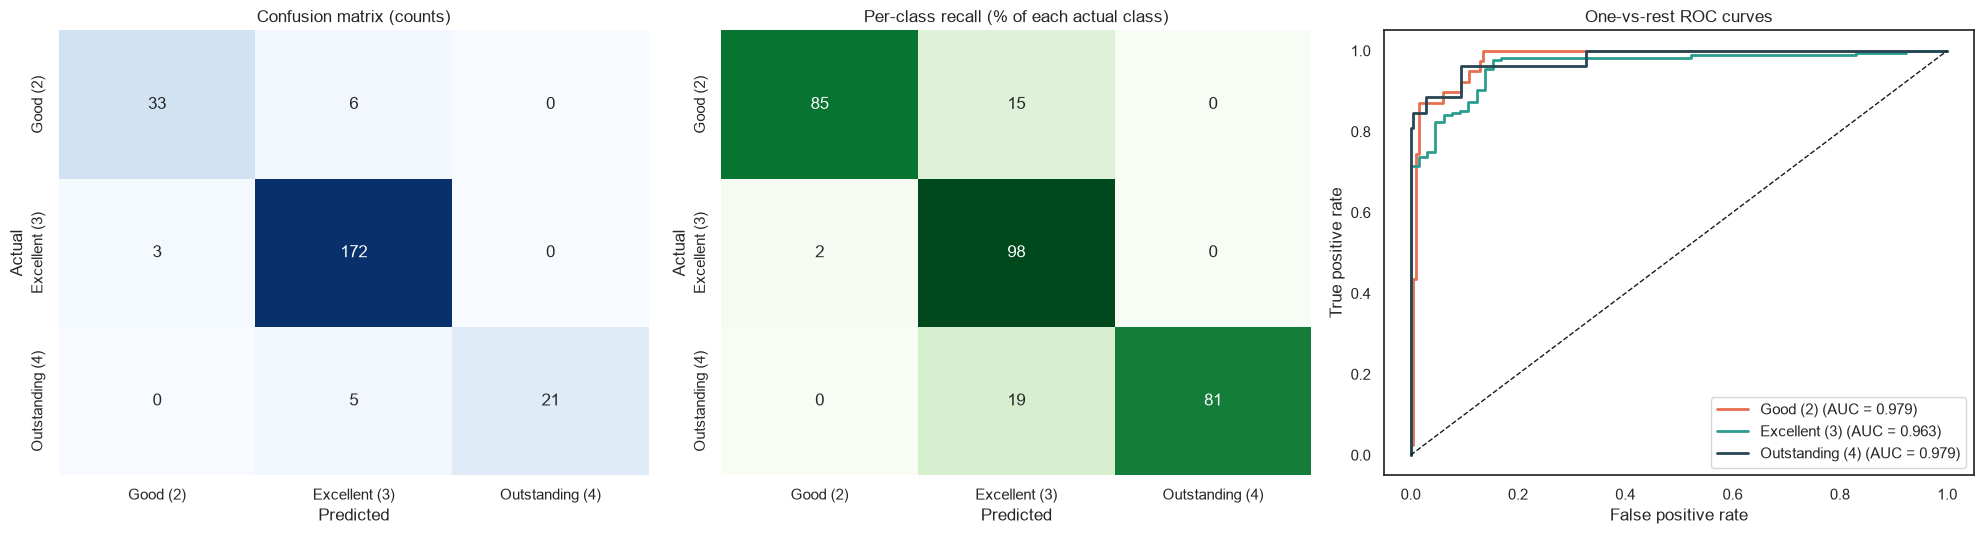

💬 14 misclassified of 240; none jump TWO levels (Good ↔ Outstanding) — errors go to the neighbouring class.


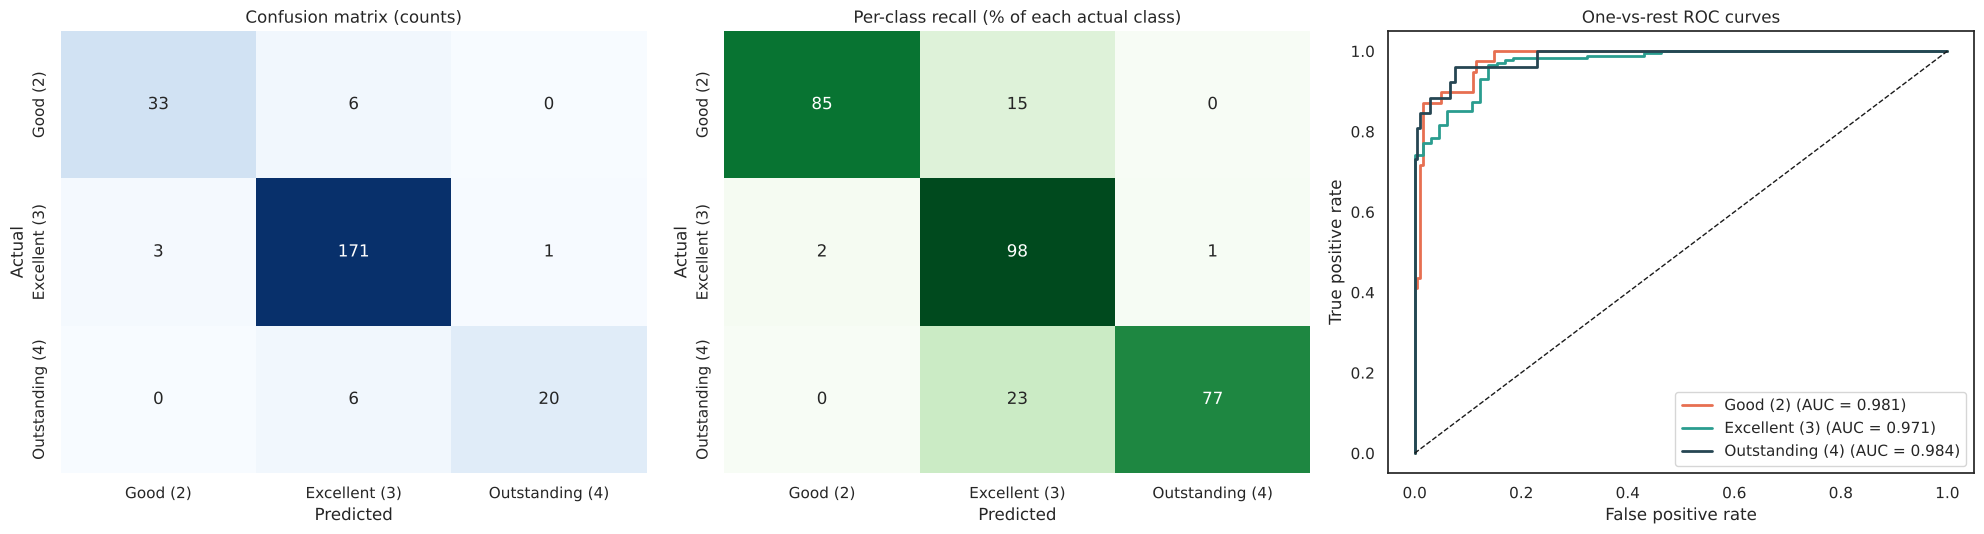

💬 16 misclassified of 240; none jump TWO levels (Good ↔ Outstanding) — errors go to the neighbouring class.


In [21]:
import os, joblib, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, auc, accuracy_score,
                             balanced_accuracy_score, f1_score)
from sklearn.preprocessing import label_binarize
warnings.filterwarnings('ignore')

ARTIFACT_DIR = 'artifacts'
CLASS_NAMES = ['Good (2)', 'Excellent (3)', 'Outstanding (4)']

def load_artifact(name, made_in):
    path = os.path.join(ARTIFACT_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ '{path}' not found (cwd = {os.getcwd()}).\n   👉 Run {made_in} first — it creates this file.")
    return joblib.load(path)

def load_splits():
    fs, dc = load_artifact('feature_sets.pkl', 'Section 7'), load_artifact('design_choices.pkl', 'Section 8')
    X = fs['X_eng'] if dc['use_engineered'] else fs['X_base']
    tr, te = fs['train_idx'], fs['test_idx']
    return X.iloc[tr], X.iloc[te], fs['y'].iloc[tr], fs['y'].iloc[te], dc

sns.set_theme(style='white')
X_train, X_test, y_train, y_test, dc = load_splits()
champ = load_artifact('champion.pkl', 'Section 11')
w = load_artifact('class_weights.pkl', 'Section 12.1')['weights']
model = champ['model']

proba = model.predict_proba(X_test)
pred = (proba * w).argmax(1)
y_true = y_test.values
print(f'🏆 Champion: {champ["name"]}   |   class weights applied: {w.tolist()}\n')
print(classification_report(y_true, pred, target_names=CLASS_NAMES, digits=3))

# ─── Over-fitting check ──────────────────────────────────────────────────
f1_train = f1_score(y_train, (model.predict_proba(X_train) * w).argmax(1), average='macro')
f1_test = f1_score(y_true, pred, average='macro')
print(f'🔎 Over-fitting check → train macro-F1 {f1_train:.3f} vs test {f1_test:.3f}  (gap {f1_train - f1_test:+.3f})')
print('   ' + ('✅ small gap' if f1_train - f1_test < 0.05 else '⚠️  moderate gap — typical for boosted / stacked trees. The CV score (Section 11) and the test score agree closely, so generalisation is credible, but expect real-world performance near the test figure, not the train figure.'))

# ─── Bootstrap confidence intervals ──────────────────────────────────────
rng = np.random.default_rng(42)
boot = {'accuracy': [], 'balanced_acc': [], 'f1_macro': []}
for _ in range(1000):
    i = rng.integers(0, len(y_true), len(y_true))
    boot['accuracy'].append(accuracy_score(y_true[i], pred[i]))
    boot['balanced_acc'].append(balanced_accuracy_score(y_true[i], pred[i]))
    boot['f1_macro'].append(f1_score(y_true[i], pred[i], average='macro'))
print('\n📏 95% bootstrap confidence intervals (1000 resamples of the test set)')
for k, v in boot.items():
    lo, hi = np.percentile(v, [2.5, 97.5])
    print(f'   {k:<13} {np.mean(v):.3f}   [{lo:.3f} – {hi:.3f}]')

# ─── Plots ───────────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, pred)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0], cbar=False)
axes[0].set_title('Confusion matrix (counts)'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
sns.heatmap(cm_pct, annot=True, fmt='.0f', cmap='Greens', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1], cbar=False, vmin=0, vmax=100)
axes[1].set_title('Per-class recall (% of each actual class)'); axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
y_bin = label_binarize(y_true, classes=[0, 1, 2])
for k, (name, c) in enumerate(zip(CLASS_NAMES, ['#e76f51', '#2a9d8f', '#264653'])):
    fpr, tpr, _ = roc_curve(y_bin[:, k], proba[:, k])
    axes[2].plot(fpr, tpr, color=c, lw=2, label=f'{name} (AUC = {auc(fpr, tpr):.3f})')
axes[2].plot([0, 1], [0, 1], 'k--', lw=1); axes[2].set_title('One-vs-rest ROC curves'); axes[2].set_xlabel('False positive rate'); axes[2].set_ylabel('True positive rate'); axes[2].legend(loc='lower right')
plt.tight_layout(); plt.show()

joblib.dump({'y_true': y_true, 'pred': pred, 'proba': proba, 'cm': cm, 'cm_pct': cm_pct, 'boot': boot}, os.path.join(ARTIFACT_DIR, 'test_eval.pkl'))
n_err, n_far = int((pred != y_true).sum()), int(cm[0, 2] + cm[2, 0])
print(f'💬 {n_err} misclassified of {len(y_true)}; ' + (f'only {n_far} jump TWO levels (Good ↔ Outstanding)' if n_far else 'none jump TWO levels (Good ↔ Outstanding)') + ' — errors go to the neighbouring class.')

## 1️⃣3️⃣ 📍 Deliverable 2 — Top 3 factors affecting performance
A single importance method can mislead (impurity importance favours high-cardinality features; correlated features split credit). So four **independent lenses** are combined, and one-hot dummy columns are **grouped back into their original factor** (e.g. all `EmpDepartment_*` columns → `EmpDepartment`):

| Lens | What it measures |
|---|---|
| 1. Random-Forest impurity | how much a factor reduces node impurity in a forest |
| 2. **Grouped permutation importance** on the champion (test set) | drop in macro-F1 when the factor is shuffled — model-agnostic and honest to the final model |
| 3. SHAP (tuned LightGBM surrogate) | average contribution of the factor to individual predictions |
| 4. Statistical association | |Spearman ρ| (numeric/ordinal) or Cramér's V (nominal) from Section 6 — no model involved |

Each lens is converted to a *share of total importance*; the **consensus** is the average share.

In [22]:
import os, joblib, warnings
import numpy as np, pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from lightgbm import LGBMClassifier
warnings.filterwarnings('ignore')

ARTIFACT_DIR = 'artifacts'
RANDOM_STATE = 42

def load_artifact(name, made_in):
    path = os.path.join(ARTIFACT_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ '{path}' not found (cwd = {os.getcwd()}).\n   👉 Run {made_in} first — it creates this file.")
    return joblib.load(path)

def load_splits():
    fs, dc = load_artifact('feature_sets.pkl', 'Section 7'), load_artifact('design_choices.pkl', 'Section 8')
    X = fs['X_eng'] if dc['use_engineered'] else fs['X_base']
    tr, te = fs['train_idx'], fs['test_idx']
    return X.iloc[tr], X.iloc[te], fs['y'].iloc[tr], fs['y'].iloc[te], dc

def ascii_bar(label, value, max_value, width=30, text=None):
    n = int(round(width * value / max_value)) if max_value > 0 else 0
    print(f'   {label:<30} {"█" * n:<{width}} {text if text is not None else value}')

X_train, X_test, y_train, y_test, dc = load_splits()
fs = load_artifact('feature_sets.pkl', 'Section 7')
champ = load_artifact('champion.pkl', 'Section 11')['model']
assoc = load_artifact('assoc_tables.pkl', 'Section 6')
P = load_artifact('best_params.pkl', 'Section 10')['params']
NOMINAL = list(fs['categories'])

# ─── group dummy columns back to their parent factor ─────────────────────
groups = {}
for col in X_train.columns:
    parent = next((n for n in NOMINAL if col.startswith(n + '_')), col)
    groups.setdefault(parent, []).append(col)
print(f'🧩 {X_train.shape[1]} model columns → {len(groups)} original factors')

def to_share(series):
    s = series.clip(lower=0)
    return s / s.sum()

# Lens 1 — Random Forest impurity
rf = RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE, n_jobs=1).fit(X_train, y_train)
imp_rf = pd.Series(rf.feature_importances_, index=X_train.columns)
lens1 = pd.Series({g: imp_rf[cols].sum() for g, cols in groups.items()})

# Lens 2 — grouped permutation importance on the champion (all dummies of a factor are shuffled together)
def group_permutation_importance(model, X, y, groups, n_repeats=10, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    base = f1_score(y, model.predict(X), average='macro')
    out = {}
    for g, cols in groups.items():
        drops = []
        for _ in range(n_repeats):
            Xp = X.copy()
            Xp[cols] = X[cols].values[rng.permutation(len(X))]
            drops.append(base - f1_score(y, model.predict(Xp), average='macro'))
        out[g] = np.mean(drops)
    return pd.Series(out)

print('⏳ Grouped permutation importance (champion, test set)…')
lens2 = group_permutation_importance(champ, X_test, y_test, groups)

# Lens 3 — SHAP on a tuned LightGBM surrogate (tree-exact, fast)
try:
    import shap
    lgbm = LGBMClassifier(**P['LightGBM'], random_state=RANDOM_STATE, n_jobs=1, verbose=-1).fit(X_train, y_train)
    sv = shap.TreeExplainer(lgbm).shap_values(X_test)
    sv = np.stack(sv, axis=-1) if isinstance(sv, list) else np.asarray(sv)          # -> (samples, features, classes)
    mean_abs = pd.Series(np.abs(sv).mean(axis=(0, 2)), index=X_train.columns)
    lens3 = pd.Series({g: mean_abs[cols].sum() for g, cols in groups.items()})
except ImportError:
    print('⚠️  shap not installed (pip install shap) → lens 3 skipped')
    lens3 = None

# Lens 4 — statistical association (no model)
effect = pd.concat([assoc['numeric'].set_index('feature')['abs_rho'], assoc['nominal'].set_index('feature')['cramers_v']])
lens4 = effect.reindex(list(groups)).fillna(0)

lenses = {'RF impurity': lens1, 'Permutation (champion)': lens2, 'SHAP': lens3, 'Association': lens4}
lenses = {k: v for k, v in lenses.items() if v is not None}
shares = pd.DataFrame({k: to_share(v) for k, v in lenses.items()})
ranks = pd.DataFrame({k: v.rank(ascending=False) for k, v in shares.items()})
consensus = pd.DataFrame({'consensus_share_%': shares.mean(axis=1) * 100, 'mean_rank': ranks.mean(axis=1)}).join(ranks.add_suffix(' (rank)'))
consensus = consensus.sort_values('consensus_share_%', ascending=False)

print('\n🏆 CONSENSUS FACTOR IMPORTANCE — top 10\n')
print(consensus.head(10).round(2).to_string())
print('\n   Consensus share of importance (%)')
for f, r in consensus.head(10).iterrows():
    ascii_bar(f, r['consensus_share_%'], consensus['consensus_share_%'].max(), text=f'{r["consensus_share_%"]:5.1f}%')

print('\n🔎 Does every lens agree on the top 3?')
for k, v in shares.items():
    print(f'   {k:<24} → {v.sort_values(ascending=False).head(3).index.tolist()}')
top3 = consensus.index[:3].tolist()
print(f'\n🥇🥈🥉 TOP 3 FACTORS: {top3}   (together {consensus["consensus_share_%"].head(3).sum():.0f}% of total importance)')

joblib.dump({'consensus': consensus, 'shares': shares, 'ranks': ranks, 'top3': top3}, os.path.join(ARTIFACT_DIR, 'factor_importance.pkl'))

🧩 53 model columns → 26 original factors
⏳ Grouped permutation importance (champion, test set)…

🏆 CONSENSUS FACTOR IMPORTANCE — top 10

                              consensus_share_%  mean_rank  RF impurity (rank)  Permutation (champion) (rank)  SHAP (rank)  Association (rank)
EmpEnvironmentSatisfaction                22.50       1.25                 2.0                            1.0          1.0                 1.0
EmpLastSalaryHikePercent                  19.32       1.75                 1.0                            2.0          2.0                 2.0
YearsSinceLastPromotion                   11.05       3.25                 3.0                            4.0          3.0                 3.0
EmpDepartment                              7.34       4.25                 5.0                            3.0          4.0                 5.0
ExperienceYearsInCurrentRole               6.01       6.25                 8.0                            5.0          6.0                 6.0
EmpJo

['artifacts\\factor_importance.pkl']


🏆 CONSENSUS FACTOR IMPORTANCE — top 10

                              consensus_share_%  mean_rank  RF impurity (rank)  Permutation (champion) (rank)  SHAP (rank)  Association (rank)
EmpEnvironmentSatisfaction                22.91       1.25                 2.0                            1.0          1.0                 1.0
EmpLastSalaryHikePercent                  19.64       1.75                 1.0                            2.0          2.0                 2.0
YearsSinceLastPromotion                   11.00       3.25                 3.0                            4.0          3.0                 3.0
EmpDepartment                              7.66       4.25                 5.0                            3.0          4.0                 5.0
ExperienceYearsInCurrentRole               5.67       6.25                 8.0                            5.0          6.0                 6.0
EmpJobRole                                 4.40       5.75                 4.0                       

['artifacts/factor_importance.pkl']

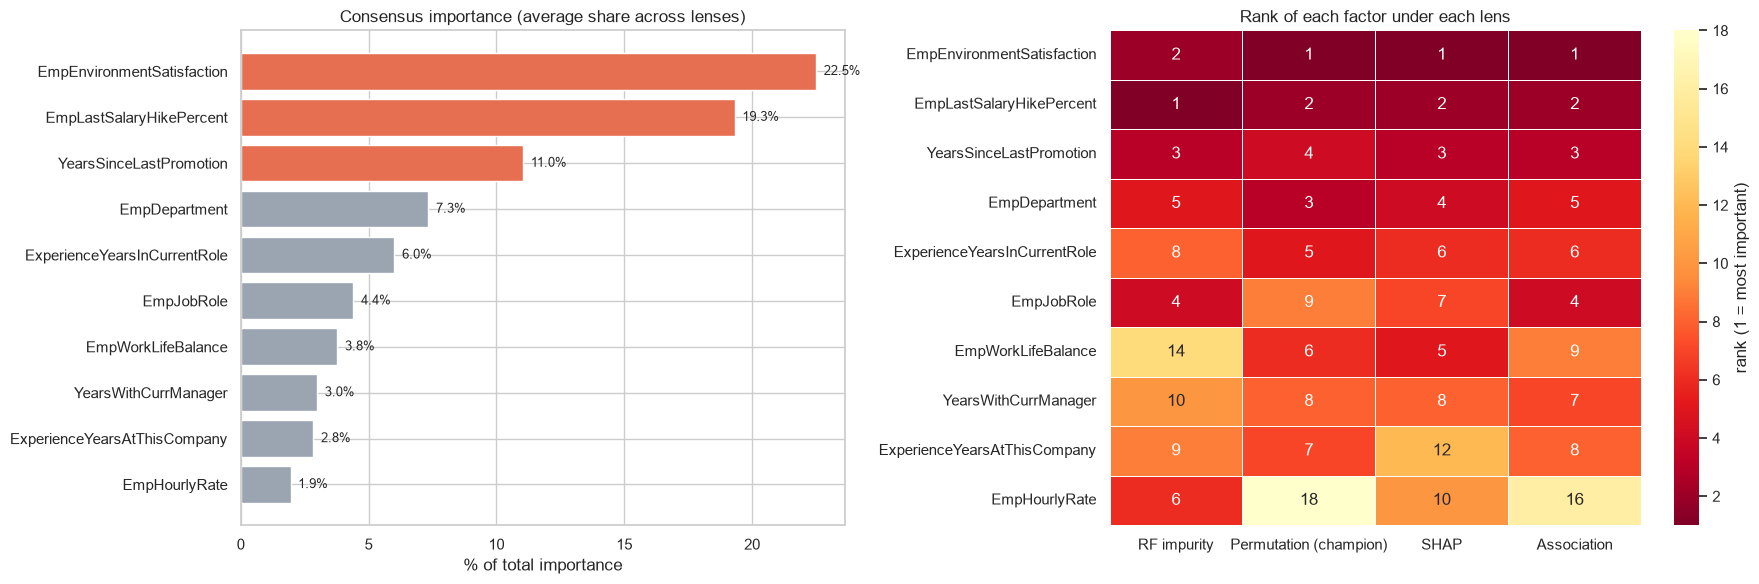

💡 Environment satisfaction and salary hike are top-2 under every lens; promotion is top-3 in three of four (permutation importance ranks Department 3rd).
   The leading trio is therefore not an artefact of one method, although rank 3 is the least certain.


In [23]:
import os, joblib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

ARTIFACT_DIR = 'artifacts'

def load_artifact(name, made_in):
    path = os.path.join(ARTIFACT_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ '{path}' not found (cwd = {os.getcwd()}).\n   👉 Run {made_in} first — it creates this file.")
    return joblib.load(path)

sns.set_theme(style='whitegrid')
fi = load_artifact('factor_importance.pkl', 'Section 13 (consensus cell)')
consensus, shares, ranks = fi['consensus'], fi['shares'], fi['ranks']
top = consensus.head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'width_ratios': [1, 1.1]})
colors = ['#e76f51'] * 3 + ['#9aa5b1'] * 7
axes[0].barh(top.index[::-1], top['consensus_share_%'][::-1], color=colors[::-1])
for i, v in enumerate(top['consensus_share_%'][::-1]):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
axes[0].set_title('Consensus importance (average share across lenses)'); axes[0].set_xlabel('% of total importance')

sns.heatmap(ranks.loc[top.index], annot=True, fmt='.0f', cmap='YlOrRd_r', cbar_kws={'label': 'rank (1 = most important)'}, linewidths=0.5, ax=axes[1])
axes[1].set_title('Rank of each factor under each lens'); axes[1].set_ylabel('')
plt.tight_layout(); plt.show()
print('💡 Environment satisfaction and salary hike are top-2 under every lens; promotion is top-3 in three of four (permutation importance ranks Department 3rd).')
print('   The leading trio is therefore not an artefact of one method, although rank 3 is the least certain.')

### 13.1 What do the top-3 factors actually do? (model-based effect curves)
For each factor we force *every* test employee to a given value, leaving everything else as it is, and average the champion's predicted class probabilities. This isolates the model's learned effect of the factor — the same idea as a partial-dependence plot.

🔬 MODEL-BASED EFFECT OF EACH TOP FACTOR (average predicted probability)

   EmpEnvironmentSatisfaction      1 → 4     P(Good): 38.7% →  2.6%   |   P(Outstanding):  6.5% → 13.2%
   EmpLastSalaryHikePercent       11 → 25    P(Good): 15.5% → 16.1%   |   P(Outstanding):  2.7% → 56.3%
   YearsSinceLastPromotion         0 → 15    P(Good):  2.9% → 20.8%   |   P(Outstanding): 10.5% → 10.1%


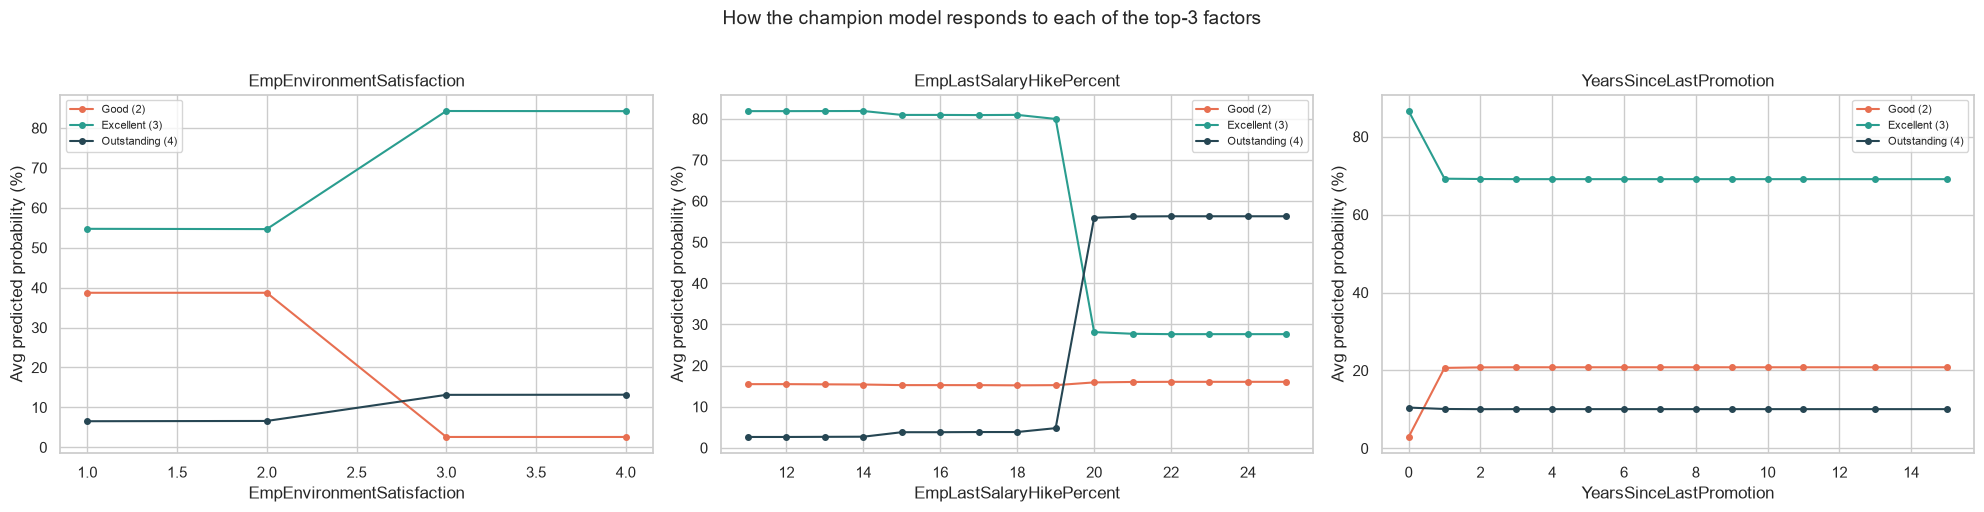

   EmpLastSalaryHikePercent       11 → 25    P(Good): 15.3% → 14.1%   |   P(Outstanding):  2.1% → 62.9%


   YearsSinceLastPromotion         0 → 15    P(Good):  1.6% → 19.4%   |   P(Outstanding): 10.9% → 10.3%


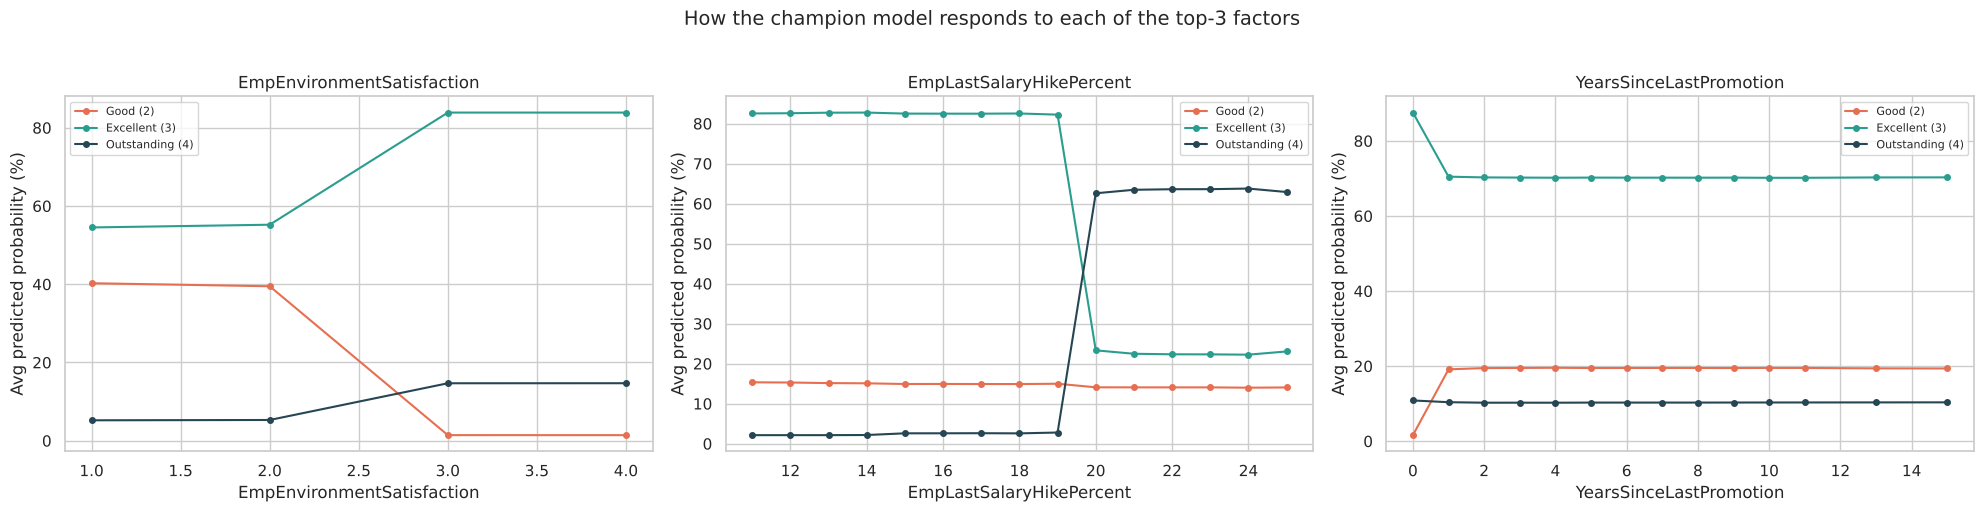

In [24]:
import os, joblib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

ARTIFACT_DIR = 'artifacts'
CLASS_NAMES = ['Good (2)', 'Excellent (3)', 'Outstanding (4)']

def load_artifact(name, made_in):
    path = os.path.join(ARTIFACT_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ '{path}' not found (cwd = {os.getcwd()}).\n   👉 Run {made_in} first — it creates this file.")
    return joblib.load(path)

def load_splits():
    fs, dc = load_artifact('feature_sets.pkl', 'Section 7'), load_artifact('design_choices.pkl', 'Section 8')
    X = fs['X_eng'] if dc['use_engineered'] else fs['X_base']
    tr, te = fs['train_idx'], fs['test_idx']
    return X.iloc[tr], X.iloc[te], fs['y'].iloc[tr], fs['y'].iloc[te], dc

sns.set_theme(style='whitegrid')
X_train, X_test, y_train, y_test, dc = load_splits()
model = load_artifact('champion.pkl', 'Section 11')['model']
top3 = load_artifact('factor_importance.pkl', 'Section 13 (consensus cell)')['top3']
colors = ['#e76f51', '#2a9d8f', '#264653']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
print('🔬 MODEL-BASED EFFECT OF EACH TOP FACTOR (average predicted probability)\n')
for ax, factor in zip(axes, top3):
    if factor not in X_test.columns:
        print(f'   ⚠️  {factor} is a grouped categorical factor — effect curve skipped.')
        ax.axis('off'); continue
    values = np.sort(X_test[factor].unique())
    curves = []
    for v in values:
        Xv = X_test.copy(); Xv[factor] = v
        curves.append(model.predict_proba(Xv).mean(axis=0))
    curves = np.array(curves)
    for k in range(3):
        ax.plot(values, curves[:, k] * 100, marker='o', ms=4, color=colors[k], label=CLASS_NAMES[k])
    ax.set_title(factor); ax.set_xlabel(factor); ax.set_ylabel('Avg predicted probability (%)'); ax.legend(fontsize=8)
    lo, hi = values[0], values[-1]
    print(f'   {factor:<28} {lo:>4} → {hi:<4}  P(Good): {curves[0, 0] * 100:4.1f}% → {curves[-1, 0] * 100:4.1f}%   |   P(Outstanding): {curves[0, 2] * 100:4.1f}% → {curves[-1, 2] * 100:4.1f}%')
plt.suptitle('How the champion model responds to each of the top-3 factors', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

### 13.2 Do the factors compound? (Environment satisfaction × salary hike)

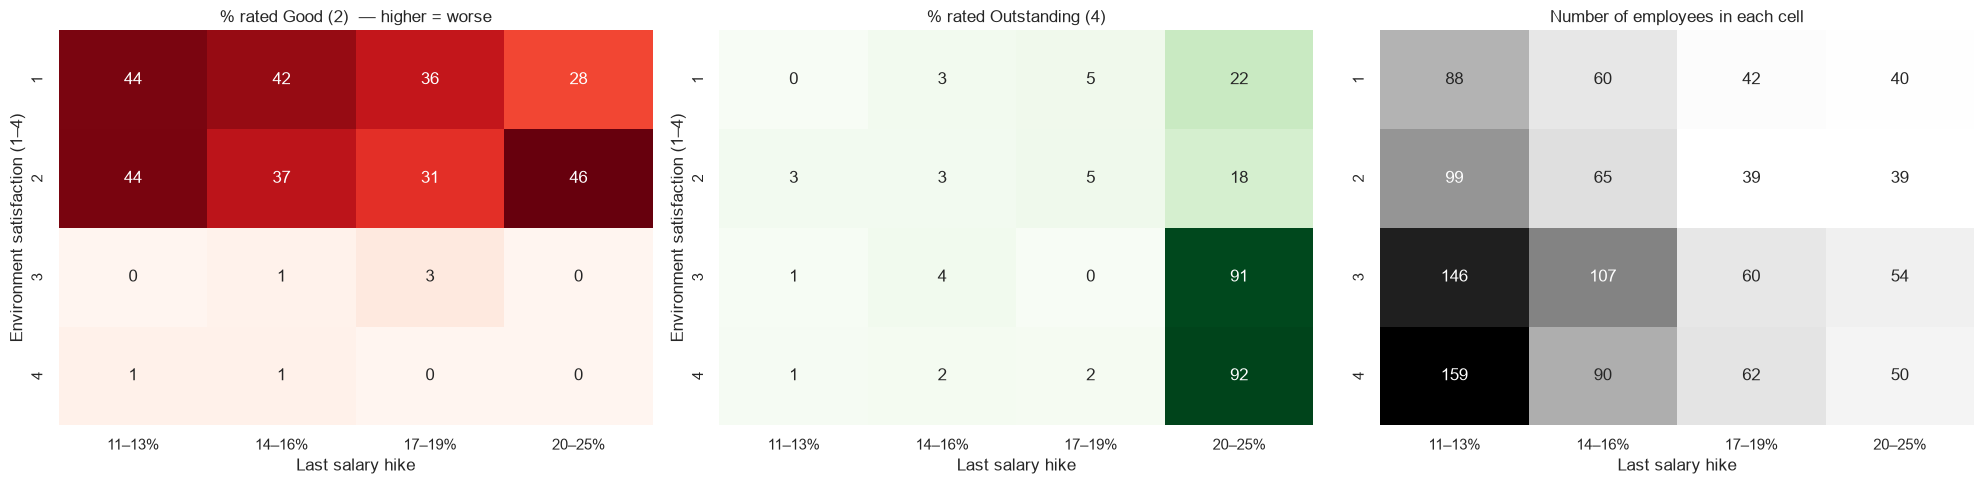

💡 Under-performance (Good) is concentrated in the low-satisfaction rows regardless of pay band;
   Outstanding ratings are concentrated in the 20–25% hike column regardless of satisfaction.
   → Two different mechanisms: satisfaction protects against the LOW end, big raises accompany the HIGH end.


In [25]:
import os, joblib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

ARTIFACT_DIR = 'artifacts'
def load_artifact(name, made_in):
    path = os.path.join(ARTIFACT_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ '{path}' not found (cwd = {os.getcwd()}).\n   👉 Run {made_in} first — it creates this file.")
    return joblib.load(path)

sns.set_theme(style='white')
df = load_artifact('clean_df.pkl', 'Section 3')
df['hike_band'] = pd.cut(df['EmpLastSalaryHikePercent'], [10, 13, 16, 19, 25], labels=['11–13%', '14–16%', '17–19%', '20–25%'])
df['is_Good'] = (df['PerformanceRating'] == 2) * 100.0
df['is_Out'] = (df['PerformanceRating'] == 4) * 100.0

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, (col, title, cmap) in zip(axes, [('is_Good', '% rated Good (2)  — higher = worse', 'Reds'), ('is_Out', '% rated Outstanding (4)', 'Greens')]):
    pt = df.pivot_table(index='EmpEnvironmentSatisfaction', columns='hike_band', values=col, aggfunc='mean', observed=False)
    sns.heatmap(pt, annot=True, fmt='.0f', cmap=cmap, ax=ax, cbar=False)
    ax.set_title(title); ax.set_xlabel('Last salary hike'); ax.set_ylabel('Environment satisfaction (1–4)')
cnt = df.pivot_table(index='EmpEnvironmentSatisfaction', columns='hike_band', values='is_Good', aggfunc='count', observed=False)
sns.heatmap(cnt, annot=True, fmt='d', cmap='Greys', ax=axes[2], cbar=False)
axes[2].set_title('Number of employees in each cell'); axes[2].set_xlabel('Last salary hike'); axes[2].set_ylabel('')
plt.tight_layout(); plt.show()

print('💡 Under-performance (Good) is concentrated in the low-satisfaction rows regardless of pay band;')
print('   Outstanding ratings are concentrated in the 20–25% hike column regardless of satisfaction.')
print('   → Two different mechanisms: satisfaction protects against the LOW end, big raises accompany the HIGH end.')

**Deliverable 2 — the three factors** *(consensus of four lenses; Environment satisfaction and Salary hike are ranked 1–2 by all four, Years since promotion is 3rd in three of the four — permutation importance puts Department 3rd and promotion 4th)*

| # | Factor | What the data shows | How to read it |
|---|---|---|---|
| 🥇 | **Environment satisfaction** (`EmpEnvironmentSatisfaction`) | Employees scoring 3–4 are almost never rated *Good (2)* (< 1%), whereas ~40% of those scoring 1–2 are. | The only top factor that is plausibly a *cause* and that management can change directly. |
| 🥈 | **Last salary-hike %** (`EmpLastSalaryHikePercent`) | A sharp **step at 20%**: employees with ≥ 20% hikes are rated *Outstanding* far more often (≈ 61%). | Looks like the *result* of a pay-for-performance rule (reverse causality) — a marker of recognition, not necessarily a lever. |
| 🥉 | **Years since last promotion** (`YearsSinceLastPromotion`) | Rated highest when promoted recently (0 yrs); lower for everyone ≥ 1 year since promotion. | Partly an outcome of performance, partly a stagnation signal worth monitoring. |

> ⚠️ **Association ≠ causation.** This is a single cross-sectional snapshot. Only environment satisfaction can be argued to *precede* the rating; raises and promotions are normally *awarded for* performance. Section 19 turns this distinction into recommendations.

## 1️⃣4️⃣ Results dashboard (2 × 2)
One figure that summarises the whole story: **model comparison · test confusion matrix · top factors · department performance**. It is also saved as `artifacts/dashboard.png`.

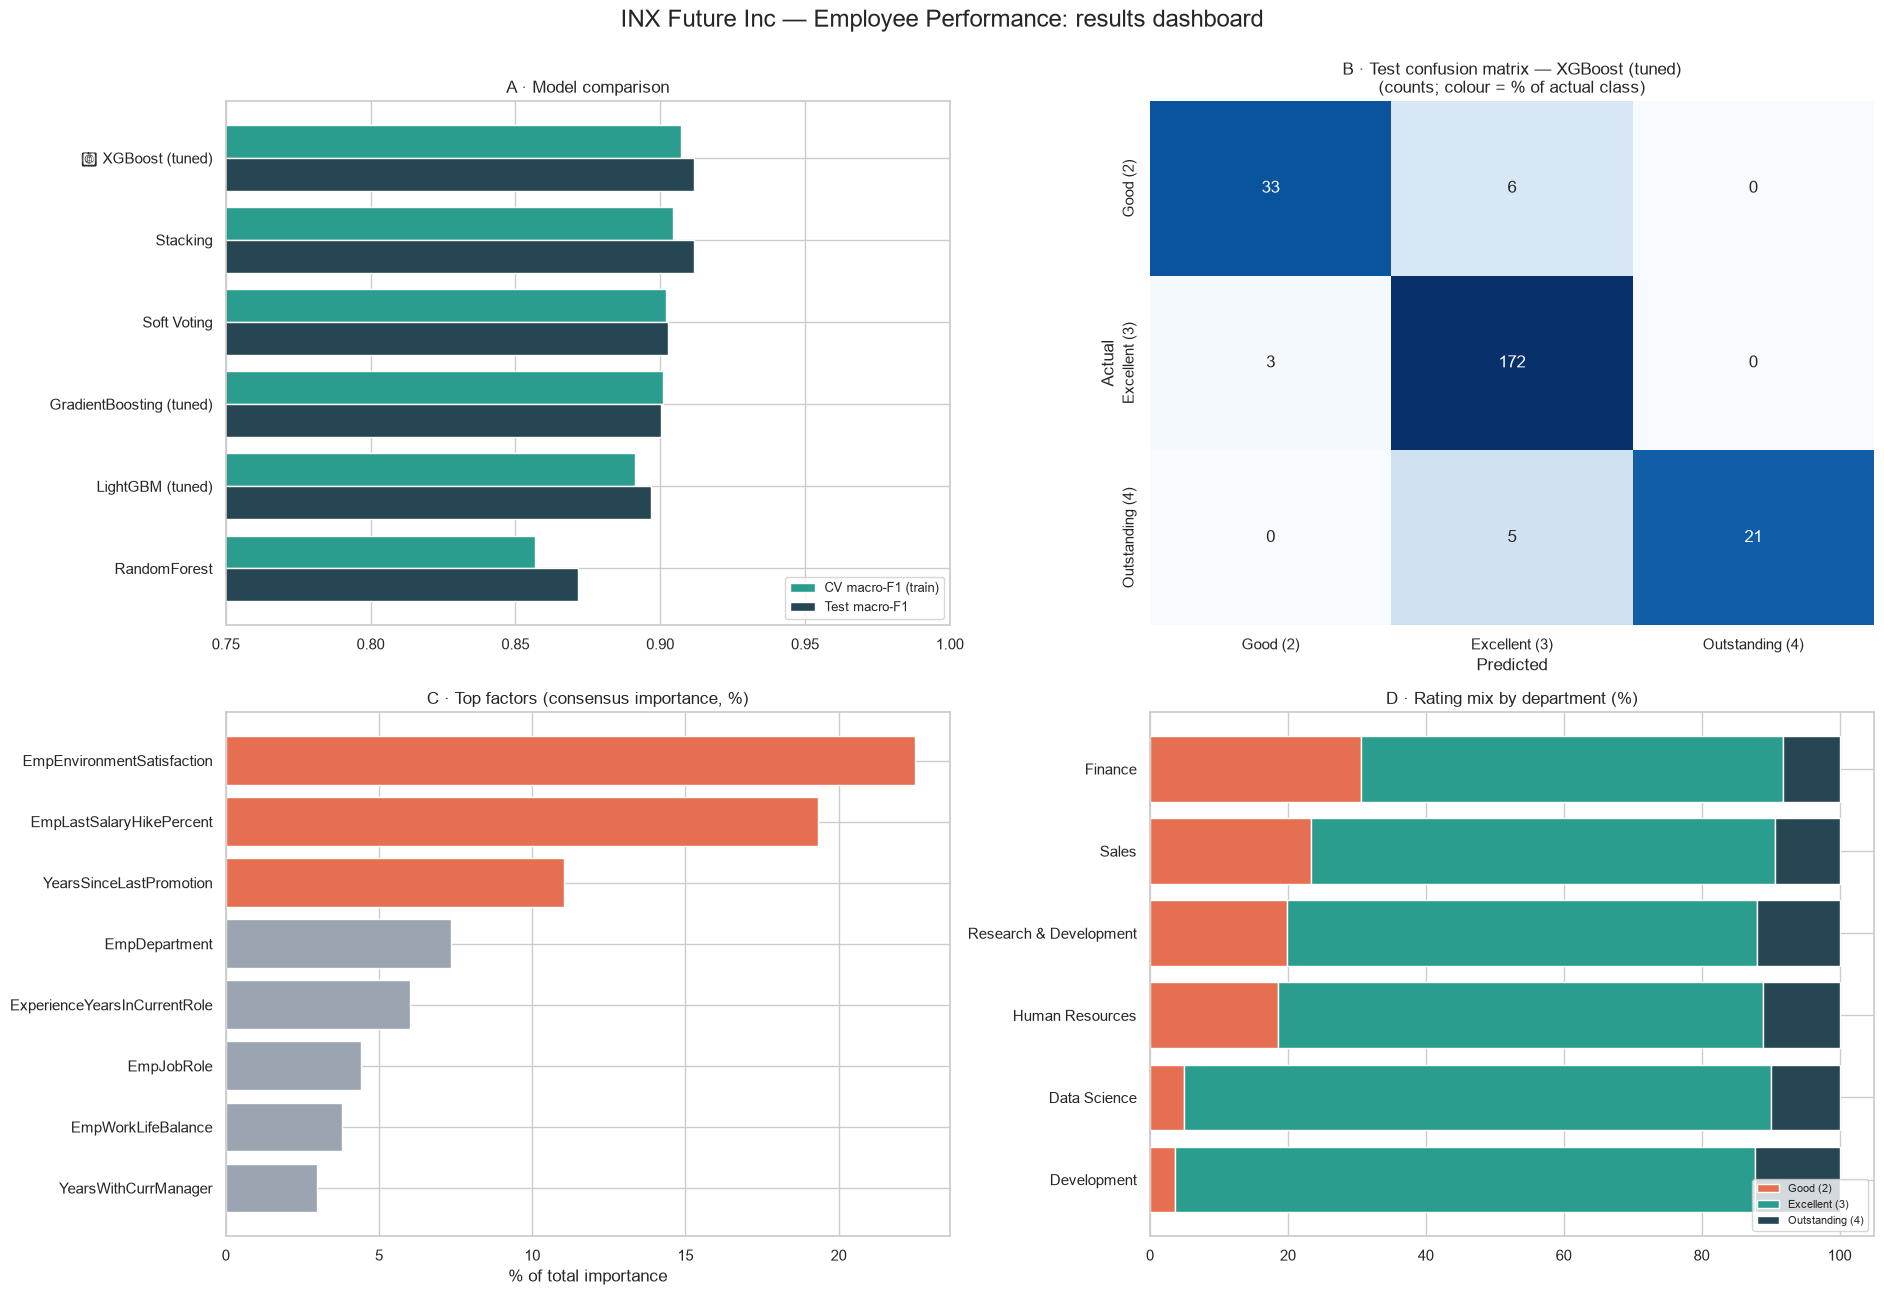

💾 Saved dashboard → artifacts\dashboard.png


In [26]:
import os, joblib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

ARTIFACT_DIR = 'artifacts'
CLASS_NAMES = ['Good (2)', 'Excellent (3)', 'Outstanding (4)']

def load_artifact(name, made_in):
    path = os.path.join(ARTIFACT_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ '{path}' not found (cwd = {os.getcwd()}).\n   👉 Run {made_in} first — it creates this file.")
    return joblib.load(path)

sns.set_theme(style='whitegrid')
final = load_artifact('final_results.pkl', 'Section 11')
evaluation = load_artifact('test_eval.pkl', 'Section 12.2')
fi = load_artifact('factor_importance.pkl', 'Section 13')
dept = load_artifact('dept_summary.pkl', 'Section 5')
champion = load_artifact('champion.pkl', 'Section 11')['name']

fig, axes = plt.subplots(2, 2, figsize=(19, 13))

# (A) model comparison
f = final.sort_values('cv_f1_macro')
pos = np.arange(len(f))
axes[0, 0].barh(pos + 0.2, f['cv_f1_macro'], height=0.4, color='#2a9d8f', label='CV macro-F1 (train)')
axes[0, 0].barh(pos - 0.2, f['f1_macro'], height=0.4, color='#264653', label='Test macro-F1')
axes[0, 0].set_yticks(pos); axes[0, 0].set_yticklabels([('🏆 ' if m == champion else '') + m for m in f['model']])
axes[0, 0].set_xlim(0.75, 1.0); axes[0, 0].set_title('A · Model comparison'); axes[0, 0].legend(loc='lower right', fontsize=9)

# (B) confusion matrix (% of each actual class)
sns.heatmap(evaluation['cm_pct'], annot=evaluation['cm'], fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cbar=False, ax=axes[0, 1])
axes[0, 1].set_title(f'B · Test confusion matrix — {champion}\n(counts; colour = % of actual class)'); axes[0, 1].set_xlabel('Predicted'); axes[0, 1].set_ylabel('Actual')

# (C) top factors
top = fi['consensus'].head(8)
axes[1, 0].barh(top.index[::-1], top['consensus_share_%'][::-1], color=(['#9aa5b1'] * 5 + ['#e76f51'] * 3))
axes[1, 0].set_title('C · Top factors (consensus importance, %)'); axes[1, 0].set_xlabel('% of total importance')

# (D) department performance
d = dept.sort_values('pct_Good')
axes[1, 1].barh(d.index, d['pct_Good'], color='#e76f51', label='Good (2)')
axes[1, 1].barh(d.index, d['pct_Excellent'], left=d['pct_Good'], color='#2a9d8f', label='Excellent (3)')
axes[1, 1].barh(d.index, d['pct_Outstanding'], left=d['pct_Good'] + d['pct_Excellent'], color='#264653', label='Outstanding (4)')
axes[1, 1].set_title('D · Rating mix by department (%)'); axes[1, 1].legend(loc='lower right', fontsize=8)

plt.suptitle('INX Future Inc — Employee Performance: results dashboard', fontsize=17, y=0.995)
plt.tight_layout()
path = os.path.join(ARTIFACT_DIR, 'dashboard.png')
plt.savefig(path, dpi=150, bbox_inches='tight'); plt.show()
print(f'💾 Saved dashboard → {path}')

## 1️⃣5️⃣ 📍 Deliverable 3 — A model for *hiring*: how far can it really go?
The brief says the trained model "will be used to hire employees". That requires an honest distinction about **which inputs exist at which moment**:

| Stage | Information available | Model |
|---|---|---|
| **A. At hiring** | candidate / role attributes only (background, education level, experience, previous employers, commute distance, department & role, travel requirement) | *hiring-stage model* |
| **B. After onboarding** | A + satisfaction / work-life-balance / involvement survey answers + overtime | *onboarding-stage model* |
| **C. In-role** | B + salary hike, promotion history, tenure with manager… | *champion model (Sections 9–12)* |

Stage C is what the champion uses — and several of its inputs (raises, promotions) are *consequences* of past performance. So its high accuracy proves that the pattern is learnable and is excellent for **diagnosing the current workforce**, but it cannot be used on a candidate who has no raise or promotion history yet.

**Fairness guard-rail:** `Gender`, `MaritalStatus` and `Age` are deliberately **excluded** from the stage-A/B models — using protected characteristics in hiring is unethical and in many jurisdictions illegal (and Section 6 showed that gender and marital status have no relationship with performance anyway).

In [27]:
import os, joblib, warnings
import numpy as np, pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from lightgbm import LGBMClassifier
warnings.filterwarnings('ignore')

ARTIFACT_DIR = 'artifacts'
RANDOM_STATE = 42

def load_artifact(name, made_in):
    path = os.path.join(ARTIFACT_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ '{path}' not found (cwd = {os.getcwd()}).\n   👉 Run {made_in} first — it creates this file.")
    return joblib.load(path)

df = load_artifact('clean_df.pkl', 'Section 3')
fs = load_artifact('feature_sets.pkl', 'Section 7')
final = load_artifact('final_results.pkl', 'Section 11')
tr, te, y = fs['train_idx'], fs['test_idx'], fs['y']

HIRE_TIME = ['EducationBackground', 'EmpEducationLevel', 'TotalWorkExperienceInYears', 'NumCompaniesWorked',
             'DistanceFromHome', 'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency']
ONBOARDING = HIRE_TIME + ['EmpEnvironmentSatisfaction', 'EmpJobSatisfaction', 'EmpRelationshipSatisfaction',
                          'EmpWorkLifeBalance', 'EmpJobInvolvement', 'OverTime']
missing = [c for c in ONBOARDING if c not in df.columns]
if missing:
    raise KeyError(f'❌ Columns not found in data: {missing}')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def quick_eval(name, model, X):
    X_tr, X_te, y_tr, y_te = X.iloc[tr], X.iloc[te], y.iloc[tr], y.iloc[te]
    cv_f1 = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='f1_macro', n_jobs=1).mean()
    model.fit(X_tr, y_tr)
    p = model.predict(X_te)
    return {'model': name, 'cv_f1_macro': cv_f1, 'test_acc': accuracy_score(y_te, p),
            'test_bal_acc': balanced_accuracy_score(y_te, p), 'test_f1_macro': f1_score(y_te, p, average='macro')}

def lgbm():
    return LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=15, max_depth=5, min_child_samples=20,
                          class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1, verbose=-1)

X_hire = pd.get_dummies(df[HIRE_TIME], drop_first=True, dtype=float)
X_onb = pd.get_dummies(df[ONBOARDING], drop_first=True, dtype=float)

rows = [quick_eval('Majority-class dummy', DummyClassifier(strategy='most_frequent'), X_hire),
        quick_eval('A · Hiring-stage model', lgbm(), X_hire),
        quick_eval('B · Onboarding-stage model', lgbm(), X_onb)]
champ_row = final.iloc[0]
rows.append({'model': f'C · In-role champion ({champ_row.model})', 'cv_f1_macro': champ_row.cv_f1_macro,
             'test_acc': champ_row.accuracy, 'test_bal_acc': champ_row.balanced_acc, 'test_f1_macro': champ_row.f1_macro})
res = pd.DataFrame(rows)

print('🎯 WHAT CAN BE PREDICTED AT EACH STAGE?  (chance level: balanced accuracy = 0.333)\n')
print(res.round(3).to_string(index=False))

dummy_f1 = res.loc[0, 'cv_f1_macro']
for label, i in [('A · hiring-stage', 1), ('B · onboarding-stage', 2)]:
    uplift = res.loc[i, 'cv_f1_macro'] - dummy_f1
    verdict = '❌ too weak to screen candidates' if res.loc[i, 'test_bal_acc'] < 0.5 else '⚠️  useful as an early-warning flag, not as a hiring gate'
    print(f'\n🔎 {label}: CV macro-F1 uplift over dummy = {uplift:+.3f}; balanced accuracy {res.loc[i, "test_bal_acc"]:.3f}  →  {verdict}')
joblib.dump(res, os.path.join(ARTIFACT_DIR, 'stage_models.pkl'))

🎯 WHAT CAN BE PREDICTED AT EACH STAGE?  (chance level: balanced accuracy = 0.333)

                                 model  cv_f1_macro  test_acc  test_bal_acc  test_f1_macro
                  Majority-class dummy        0.281     0.729         0.333          0.281
                A · Hiring-stage model        0.342     0.504         0.374          0.359
            B · Onboarding-stage model        0.528     0.708         0.589          0.561
C · In-role champion (XGBoost (tuned))        0.907     0.942         0.879          0.912

🔎 A · hiring-stage: CV macro-F1 uplift over dummy = +0.061; balanced accuracy 0.374  →  ❌ too weak to screen candidates

🔎 B · onboarding-stage: CV macro-F1 uplift over dummy = +0.247; balanced accuracy 0.589  →  ⚠️  useful as an early-warning flag, not as a hiring gate


['artifacts\\stage_models.pkl']

**Deliverable 3 — conclusion**

1. **The trained predictive model** is the champion from Sections 9–12: it predicts the rating of an *existing* employee with high accuracy and is packaged in Section 17 (model bundle) together with the single-record and batch prediction functions of Section 18.
2. **Be cautious about hiring use.** With only candidate-known attributes the model barely beats guessing, and even with onboarding-survey data it is only moderately informative. Performance at INX is driven overwhelmingly by what happens *after* joining (environment, recognition, career progress) rather than by who is hired.
3. **Practical use for hiring:** (a) rely on structured interviews, work samples and role-fit assessment for selection; (b) use this model **after onboarding** (e.g. a 90-day check-in) as an *early-warning* signal to trigger support — not as a gate that rejects candidates.

## 1️⃣6️⃣ Clear indicators of non-performing employees (the CEO's morale concern)
Mr. Brain wants indicators clear enough that any action will hit **only** genuine under-performers. Three questions:
1. **What distinguishes** *Good (2)* employees from the rest?
2. **Which simple rules** identify them — and how many *other* people would those rules wrongly catch (collateral)?
3. **How much better** is the model than a simple rule at keeping collateral low?

In [28]:
import os, joblib
import numpy as np, pandas as pd
from scipy import stats

ARTIFACT_DIR = 'artifacts'
def load_artifact(name, made_in):
    path = os.path.join(ARTIFACT_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ '{path}' not found (cwd = {os.getcwd()}).\n   👉 Run {made_in} first — it creates this file.")
    return joblib.load(path)

df = load_artifact('clean_df.pkl', 'Section 3')
good = df['PerformanceRating'] == 2
print(f'👥 Under-performers (rated Good, 2): {good.sum()} of {len(df)}  ({100 * good.mean():.1f}%)\n')

# ─── 1. Profile: Good vs the rest ────────────────────────────────────────
cols = ['EmpEnvironmentSatisfaction', 'EmpLastSalaryHikePercent', 'YearsSinceLastPromotion', 'ExperienceYearsInCurrentRole',
        'YearsWithCurrManager', 'EmpWorkLifeBalance', 'EmpJobLevel', 'Age']
rows = []
for c in cols:
    a, b = df.loc[good, c], df.loc[~good, c]
    pooled = np.sqrt((a.var() + b.var()) / 2)
    rows.append((c, a.mean(), b.mean(), (a.mean() - b.mean()) / pooled, stats.mannwhitneyu(a, b).pvalue))
profile = pd.DataFrame(rows, columns=['feature', 'mean_Good(2)', 'mean_rest', "cohens_d", 'p_value']).sort_values('cohens_d', key=abs, ascending=False)
print('🧬 PROFILE OF UNDER-PERFORMERS vs REST (Cohen\'s d: |0.2| small · |0.5| medium · |0.8| large)\n')
print(profile.round(3).to_string(index=False))

# ─── 2. Simple rules: recall / precision / collateral ────────────────────
rules = {
    'Environment satisfaction ≤ 2':               df['EmpEnvironmentSatisfaction'] <= 2,
    'Years since promotion ≥ 2':                  df['YearsSinceLastPromotion'] >= 2,
    'Salary hike ≤ 13%':                          df['EmpLastSalaryHikePercent'] <= 13,
    'Years in current role ≥ 5':                  df['ExperienceYearsInCurrentRole'] >= 5,
    'Work-life balance ≤ 2':                      df['EmpWorkLifeBalance'] <= 2,
}
two_flags = (rules['Environment satisfaction ≤ 2'].astype(int) + rules['Years since promotion ≥ 2'].astype(int) + rules['Salary hike ≤ 13%'].astype(int)) >= 2
rules['≥ 2 of the top-3 flags'] = two_flags
rules['Env ≤ 2  AND  promo ≥ 2'] = rules['Environment satisfaction ≤ 2'] & rules['Years since promotion ≥ 2']

rows = []
for name, flag in rules.items():
    n_flag = int(flag.sum())
    rows.append((name, n_flag, 100 * (flag & good).sum() / good.sum(), 100 * (flag & good).sum() / n_flag, 100 * (flag & ~good).sum() / n_flag))
rule_table = pd.DataFrame(rows, columns=['rule', 'employees_flagged', 'recall_%', 'precision_%', 'collateral_%'])
print('\n📏 SIMPLE RULES — recall = share of under-performers caught · precision = share of flagged who truly are · collateral = flagged who are NOT\n')
print(rule_table.round(1).to_string(index=False))
print('\n💡 "Environment satisfaction ≤ 2" catches almost every under-performer (very high recall) but also flags many people who are performing fine → a SINGLE rule is a great screen, but a poor basis for penalties.')
joblib.dump(rule_table, os.path.join(ARTIFACT_DIR, 'rule_table.pkl'))

👥 Under-performers (rated Good, 2): 194 of 1200  (16.2%)

🧬 PROFILE OF UNDER-PERFORMERS vs REST (Cohen's d: |0.2| small · |0.5| medium · |0.8| large)

                     feature  mean_Good(2)  mean_rest  cohens_d  p_value
  EmpEnvironmentSatisfaction         1.582      2.934    -1.604    0.000
     YearsSinceLastPromotion         3.696      1.905     0.554    0.000
ExperienceYearsInCurrentRole         5.789      4.003     0.497    0.000
        YearsWithCurrManager         5.351      3.865     0.421    0.000
                 EmpJobLevel         2.304      2.022     0.249    0.001
          EmpWorkLifeBalance         2.634      2.765    -0.185    0.029
                         Age        37.804     36.748     0.115    0.195
    EmpLastSalaryHikePercent        15.072     15.251    -0.049    0.424

📏 SIMPLE RULES — recall = share of under-performers caught · precision = share of flagged who truly are · collateral = flagged who are NOT

                        rule  employees_flagged  re

['artifacts\\rule_table.pkl']

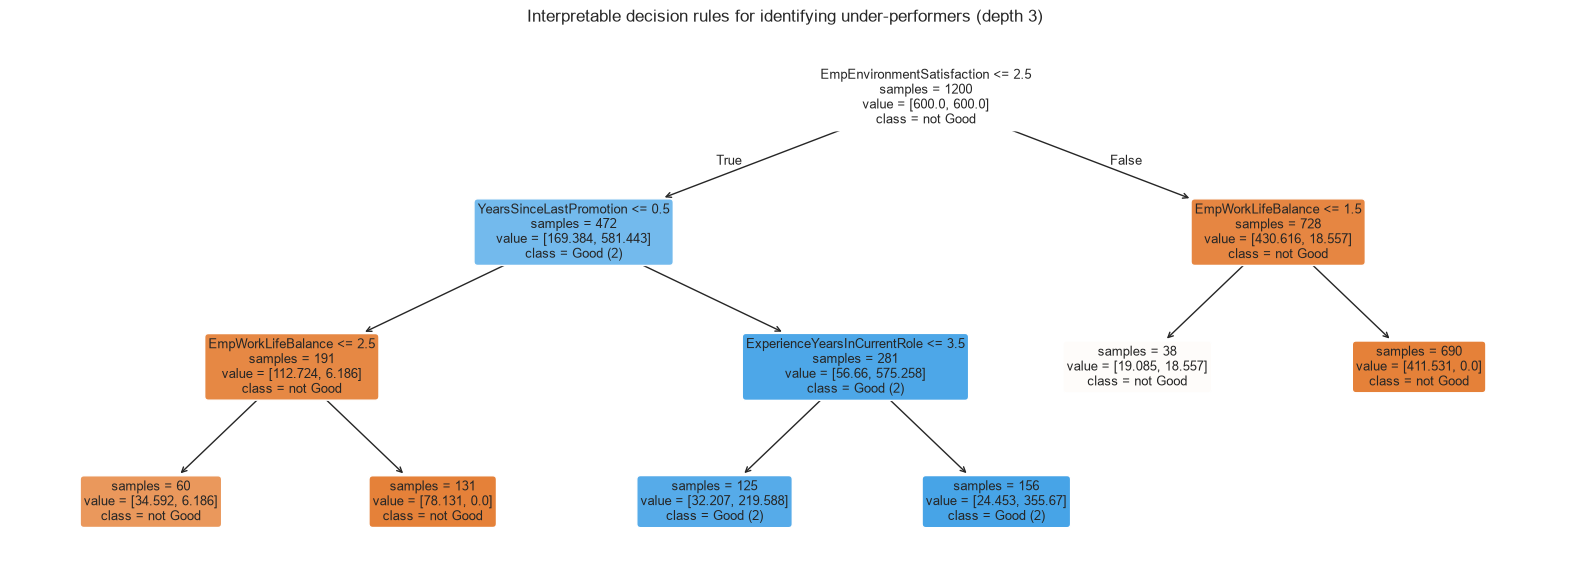

⏳ Out-of-fold champion predictions for all employees…

⚖️  COLLATERAL COMPARISON — who gets flagged?
   Single rule "Environment satisfaction ≤ 2": flags  472 employees → 40% are real under-performers, 60% are collateral
   Champion model (out-of-fold)               : flags  195 employees → 88% are real under-performers, 12% are collateral   (recall 89%)

💡 The model flags ~2.4× fewer people than the single rule while still catching 89% of true under-performers → this is the way to meet the CEO's requirement of minimal impact on everyone else.

🚨 EARLY-WARNING LIST — currently rated Excellent/Outstanding but whose profile resembles under-performers (top 10 of the list)
EmpNumber   EmpDepartment           EmpJobRole  PerformanceRating  EmpEnvironmentSatisfaction  EmpLastSalaryHikePercent  YearsSinceLastPromotion  P(Good)_%
  E100574    Data Science       Data Scientist                  3                           2                        16                        4  80.800003
 E1001129 

['artifacts\\indicators.pkl']

['artifacts/indicators.pkl']

In [29]:
import os, joblib, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import precision_score, recall_score
warnings.filterwarnings('ignore')

ARTIFACT_DIR = 'artifacts'
RANDOM_STATE = 42

def load_artifact(name, made_in):
    path = os.path.join(ARTIFACT_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ '{path}' not found (cwd = {os.getcwd()}).\n   👉 Run {made_in} first — it creates this file.")
    return joblib.load(path)

sns.set_theme(style='white')
df = load_artifact('clean_df.pkl', 'Section 3')
fs = load_artifact('feature_sets.pkl', 'Section 7')
dc = load_artifact('design_choices.pkl', 'Section 8')
champ = load_artifact('champion.pkl', 'Section 11')['model']
weights = load_artifact('class_weights.pkl', 'Section 12.1')['weights']
X = fs['X_eng'] if dc['use_engineered'] else fs['X_base']
y = fs['y']
good = (y == 0).values
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ─── 3a. Interpretable rules: a shallow decision tree for "Good vs rest" ─
simple_cols = ['EmpEnvironmentSatisfaction', 'EmpLastSalaryHikePercent', 'YearsSinceLastPromotion', 'EmpWorkLifeBalance',
               'ExperienceYearsInCurrentRole', 'EmpJobLevel']
tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=25, class_weight='balanced', random_state=RANDOM_STATE).fit(X[simple_cols], good)
fig, ax = plt.subplots(figsize=(20, 7))
plot_tree(tree, feature_names=simple_cols, class_names=['not Good', 'Good (2)'], filled=True, rounded=True, fontsize=9, ax=ax, impurity=False, proportion=False)
ax.set_title('Interpretable decision rules for identifying under-performers (depth 3)'); plt.show()

# ─── 3b. Out-of-fold model predictions for EVERY employee (honest: each employee is scored by a model that never saw them)
print('⏳ Out-of-fold champion predictions for all employees…')
oof = cross_val_predict(clone(champ), X, y, cv=cv, method='predict_proba', n_jobs=1)
pred = (oof * weights).argmax(1)
flag = pred == 0
n_flag = int(flag.sum())
model_precision, model_recall = precision_score(good, flag), recall_score(good, flag)

rule_table = load_artifact('rule_table.pkl', 'Section 16 (rules cell)')
env_rule = rule_table.iloc[0]
print('\n⚖️  COLLATERAL COMPARISON — who gets flagged?')
print(f'   Single rule "Environment satisfaction ≤ 2": flags {int(env_rule.employees_flagged):>4} employees → {env_rule["precision_%"]:.0f}% are real under-performers, {env_rule["collateral_%"]:.0f}% are collateral')
print(f'   Champion model (out-of-fold)               : flags {n_flag:>4} employees → {100 * model_precision:.0f}% are real under-performers, {100 - 100 * model_precision:.0f}% are collateral   (recall {100 * model_recall:.0f}%)')
print(f'\n💡 The model flags ~{env_rule.employees_flagged / n_flag:.1f}× fewer people than the single rule while still catching {100 * model_recall:.0f}% of true under-performers → this is the way to meet the CEO\'s requirement of minimal impact on everyone else.')

# ─── 3c. Where are the under-performers, and who is "at risk of slipping"? ─
out = df[['EmpNumber', 'EmpDepartment', 'EmpJobRole', 'PerformanceRating', 'EmpEnvironmentSatisfaction',
          'EmpLastSalaryHikePercent', 'YearsSinceLastPromotion']].copy()
out['P(Good)_%'] = (oof[:, 0] * 100).round(1)
at_risk = out[(out.PerformanceRating >= 3)].sort_values('P(Good)_%', ascending=False)
print('\n🚨 EARLY-WARNING LIST — currently rated Excellent/Outstanding but whose profile resembles under-performers (top 10 of the list)')
print(at_risk.head(10).to_string(index=False))
print(f'\n   {int((at_risk["P(Good)_%"] >= 30).sum())} employees currently rated ≥ 3 carry P(Good) ≥ 30% → candidates for a supportive check-in (NOT a penalty).')

dept_flag = out.assign(flagged=flag).groupby('EmpDepartment').agg(headcount=('flagged', 'size'), flagged=('flagged', 'sum'))
dept_flag['flagged_%'] = (100 * dept_flag.flagged / dept_flag.headcount).round(1)
print('\n🏢 Model-flagged employees per department')
print(dept_flag.sort_values('flagged_%', ascending=False).to_string())
joblib.dump({'oof': oof, 'flag': flag, 'at_risk': at_risk, 'model_precision': model_precision, 'model_recall': model_recall, 'n_flag': n_flag},
            os.path.join(ARTIFACT_DIR, 'indicators.pkl'))

**Indicators — summary for the CEO**

- **Primary indicator:** *Environment satisfaction ≤ 2* — it is present in virtually every under-performer, and (conversely) employees with satisfaction ≥ 3 are almost never under-performers. Use it as the **screen**.
- **Confirming indicators:** ≥ 2 years since last promotion and a long time in the same role (and a long time with the same manager). Combining *Environment ≤ 2 AND promotion ≥ 2* flags 171 people of whom ≈ 71% are real under-performers (collateral ≈ 29%).
- **Not an under-performance indicator:** salary-hike % — under-performers' average hike is the same as everyone else's (Cohen's d ≈ 0.05, p = 0.42). Hikes separate *Outstanding* from the rest, not *Good* from the rest, so a low raise must not be used to flag people.
- **Decision-quality tool:** the model (or the decision-tree rules above) narrows the screened group to the people who truly match the under-performer pattern, which keeps collateral low.
- **Process guard-rail:** because the leading indicator is an *organisational* one (how employees experience their environment), the first response to a flag should be **diagnosis and support**, not penalty. Penalties based on a single indicator would punish many people for conditions that the company itself influences.

## 1️⃣7️⃣ Final model bundle (refit on all employees)
The evaluation above used a 80/20 split to get honest estimates. For **deployment**, the champion is **refit on all 1,200 employees** (more data → slightly better model) and saved together with everything needed to use it safely: feature order, allowed categories, valid ranges, class weights and library versions.

> ℹ️ Predictions on the 1,200 training employees are *in-sample* and therefore optimistic — the honest performance numbers are the cross-validation and hold-out scores from Sections 11–12.

In [30]:
import os, sys, platform, joblib, datetime, warnings
import numpy as np, pandas as pd
import sklearn, xgboost, lightgbm
from sklearn.base import clone
warnings.filterwarnings('ignore')

ARTIFACT_DIR = 'artifacts'

def load_artifact(name, made_in):
    path = os.path.join(ARTIFACT_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ '{path}' not found (cwd = {os.getcwd()}).\n   👉 Run {made_in} first — it creates this file.")
    return joblib.load(path)

df = load_artifact('clean_df.pkl', 'Section 3')
schema = load_artifact('schema.pkl', 'Section 3')
fs = load_artifact('feature_sets.pkl', 'Section 7')
dc = load_artifact('design_choices.pkl', 'Section 8')
champ = load_artifact('champion.pkl', 'Section 11')
weights = load_artifact('class_weights.pkl', 'Section 12.1')['weights']
final = load_artifact('final_results.pkl', 'Section 11')
evaluation = load_artifact('test_eval.pkl', 'Section 12.2')

X = fs['X_eng'] if dc['use_engineered'] else fs['X_base']
y = fs['y']

print(f'🔧 Refitting "{champ["name"]}" on all {len(X)} employees…')
deploy_model = clone(champ['model']).fit(X, y)

# Sanity: the refit model should broadly agree with the evaluation model
agree = ((deploy_model.predict_proba(X) * weights).argmax(1) == (champ['model'].predict_proba(X) * weights).argmax(1)).mean()
print(f'✅ Agreement between evaluation model and refit model on all employees: {100 * agree:.1f}%')

raw_columns = schema['NOMINAL'] + schema['ORDINAL'] + schema['NUMERIC']
bundle = {
    'model': deploy_model, 'model_name': champ['name'], 'class_weights': weights,
    'feature_columns': list(X.columns), 'categories': fs['categories'], 'use_engineered': dc['use_engineered'],
    'class_names': fs['class_names'], 'label_map': fs['label_map'], 'raw_columns': raw_columns,
    'ordinal_valid': {c: sorted(schema['ORDINAL_LABELS'][c]) for c in schema['ORDINAL']},
    'numeric_range': {c: (float(df[c].min()), float(df[c].max())) for c in schema['NUMERIC']},
    'holdout_metrics': final.iloc[0][['cv_f1_macro', 'accuracy', 'balanced_acc', 'f1_macro', 'roc_auc_ovr']].to_dict(),
    'created': datetime.datetime.now().isoformat(timespec='seconds'),
    'versions': {'python': platform.python_version(), 'sklearn': sklearn.__version__, 'xgboost': xgboost.__version__,
                 'lightgbm': lightgbm.__version__, 'pandas': pd.__version__, 'numpy': np.__version__},
}
path = os.path.join(ARTIFACT_DIR, 'model_bundle.joblib')
joblib.dump(bundle, path)

# Round-trip test: reload from disk and make sure predictions are identical
reloaded = joblib.load(path)
assert np.allclose(reloaded['model'].predict_proba(X.head(50)), deploy_model.predict_proba(X.head(50))), '❌ reload mismatch'
print(f'\n💾 Saved → {path}  ({os.path.getsize(path) / 1024:.0f} KB)   ✅ reload round-trip verified')
print(f'📦 Bundle contents: {list(bundle)}')
print(f'🧪 Built with: {bundle["versions"]}')
print('   👉 Load the bundle with the SAME library versions (or retrain) — pickled models are version-sensitive.')

🔧 Refitting "XGBoost (tuned)" on all 1200 employees…
✅ Agreement between evaluation model and refit model on all employees: 99.8%

💾 Saved → artifacts\model_bundle.joblib  (556 KB)   ✅ reload round-trip verified
📦 Bundle contents: ['model', 'model_name', 'class_weights', 'feature_columns', 'categories', 'use_engineered', 'class_names', 'label_map', 'raw_columns', 'ordinal_valid', 'numeric_range', 'holdout_metrics', 'created', 'versions']
🧪 Built with: {'python': '3.11.15', 'sklearn': '1.5.2', 'xgboost': '3.2.0', 'lightgbm': '4.7.0', 'pandas': '3.0.5', 'numpy': '2.4.6'}
   👉 Load the bundle with the SAME library versions (or retrain) — pickled models are version-sensitive.


✅ Agreement between evaluation model and refit model on all employees: 98.8%



💾 Saved → artifacts/model_bundle.joblib  (20881 KB)   ✅ reload round-trip verified
📦 Bundle contents: ['model', 'model_name', 'class_weights', 'feature_columns', 'categories', 'use_engineered', 'class_names', 'label_map', 'raw_columns', 'ordinal_valid', 'numeric_range', 'holdout_metrics', 'created', 'versions']
🧪 Built with: {'python': '3.13.16', 'sklearn': '1.9.1', 'xgboost': '3.4.1', 'lightgbm': '4.7.0', 'pandas': '3.0.5', 'numpy': '2.5.3'}
   👉 Load the bundle with the SAME library versions (or retrain) — pickled models are version-sensitive.


## 1️⃣8️⃣ Prediction functions — single employee, batch, and what-if
- `predict_employee(record)` — one employee as a dictionary → predicted rating + class probabilities.
- `predict_batch(df)` — a table of employees (e.g. an HR export).
- `what_if(record, field, values)` — change one field for the same employee and watch the prediction move.

Inputs are **validated with explicit messages** (missing fields, unknown categories, invalid ordinal codes, values outside the training range) so a typo can never silently produce a wrong prediction.

In [31]:
import os, joblib, warnings
import numpy as np, pandas as pd
warnings.filterwarnings('ignore')

ARTIFACT_DIR = 'artifacts'

def load_artifact(name, made_in):
    path = os.path.join(ARTIFACT_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ '{path}' not found (cwd = {os.getcwd()}).\n   👉 Run {made_in} first — it creates this file.")
    return joblib.load(path)

def build_features(frame, categories, engineered):
    # identical to Section 7 — verified below against the training matrix
    X = frame.drop(columns=[c for c in ['EmpNumber', 'PerformanceRating', 'PerformanceLabel'] if c in frame.columns]).copy()
    if engineered:
        X['TenureRatio'] = X['ExperienceYearsAtThisCompany'] / (X['TotalWorkExperienceInYears'] + 1)
        X['PromoLag'] = X['YearsSinceLastPromotion'] / (X['ExperienceYearsAtThisCompany'] + 1)
        X['AvgTenurePerCompany'] = X['TotalWorkExperienceInYears'] / (X['NumCompaniesWorked'] + 1)
        X['SatisfactionIndex'] = X[['EmpEnvironmentSatisfaction', 'EmpJobSatisfaction',
                                    'EmpRelationshipSatisfaction', 'EmpWorkLifeBalance']].mean(axis=1)
        X['ManagerStability'] = X['YearsWithCurrManager'] / (X['ExperienceYearsAtThisCompany'] + 1)
        X['RoleStagnation'] = X['ExperienceYearsInCurrentRole'] / (X['ExperienceYearsAtThisCompany'] + 1)
    for col, cats in categories.items():
        X[col] = pd.Categorical(X[col], categories=cats)
    return pd.get_dummies(X, columns=list(categories), drop_first=True, dtype=float)

bundle = load_artifact('model_bundle.joblib', 'Section 17')
RATING_OF = {0: 2, 1: 3, 2: 4}
PROB_COLS = [f'P({n})' for n in bundle['class_names']]

def validate_records(records):
    missing = [c for c in bundle['raw_columns'] if c not in records.columns]
    if missing:
        raise ValueError(f'❌ Missing required field(s): {missing}\n   👉 Provide all {len(bundle["raw_columns"])} fields: {bundle["raw_columns"]}')
    problems = []
    for col, allowed in bundle['categories'].items():
        bad = sorted(set(records[col].astype(str)) - set(allowed))
        if bad:
            problems.append(f"'{col}' has unknown value(s) {bad} → allowed: {allowed}")
    for col, valid in bundle['ordinal_valid'].items():
        bad = sorted(set(records[col]) - set(valid), key=str)
        if bad:
            problems.append(f"'{col}' has invalid code(s) {bad} → allowed: {valid}")
    for col, (lo, hi) in bundle['numeric_range'].items():
        values = pd.to_numeric(records[col], errors='coerce')
        if values.isnull().any():
            problems.append(f"'{col}' must be numeric and non-empty (got {records[col].tolist()})")
        elif ((values < lo) | (values > hi)).any():
            print(f"   ⚠️  '{col}' outside the training range [{lo:g}, {hi:g}] — prediction is an extrapolation")
    if problems:
        raise ValueError('❌ Invalid input:\n   - ' + '\n   - '.join(problems))

def predict_batch(records, quiet=False):
    records = records.reset_index(drop=True)
    validate_records(records)
    X_new = build_features(records[bundle['raw_columns']], bundle['categories'], bundle['use_engineered'])
    X_new = X_new.reindex(columns=bundle['feature_columns'], fill_value=0.0)
    proba = bundle['model'].predict_proba(X_new)
    pred = (proba * bundle['class_weights']).argmax(1)
    out = pd.DataFrame(proba * 100, columns=PROB_COLS).round(1)
    out.insert(0, 'predicted_label', [bundle['class_names'][k] for k in pred])
    out.insert(0, 'predicted_rating', [RATING_OF[k] for k in pred])
    return out

def predict_employee(record, show=True):
    result = predict_batch(pd.DataFrame([record])).iloc[0]
    if show:
        print(f'🎯 Predicted rating : {result.predicted_rating}  →  {result.predicted_label}')
        for c in PROB_COLS:
            n = int(round(result[c] / 100 * 30))
            print(f'   {c:<20} {"█" * n:<30} {result[c]:5.1f}%')
    return result.to_dict()

def what_if(record, field, values):
    rows = []
    for v in values:
        r = dict(record); r[field] = v
        out = predict_batch(pd.DataFrame([r])).iloc[0]
        rows.append({field: v, 'predicted_label': out.predicted_label, **{c: out[c] for c in PROB_COLS}})
    return pd.DataFrame(rows)

# ─── Consistency test: the prediction pipeline must reproduce the training matrix exactly ──────────
df = load_artifact('clean_df.pkl', 'Section 3')
fs = load_artifact('feature_sets.pkl', 'Section 7')
X_rebuilt = build_features(df[bundle['raw_columns']], bundle['categories'], bundle['use_engineered'])
X_train_matrix = fs['X_eng'] if bundle['use_engineered'] else fs['X_base']
pd.testing.assert_frame_equal(X_rebuilt[bundle['feature_columns']], X_train_matrix[bundle['feature_columns']])
print('✅ Consistency test passed — prediction-time features are identical to training-time features.\n')

# ─── Demo 1: three real employees (one per rating) — NOTE: in-sample, for illustration only ─────────
sample = pd.concat([df[df.PerformanceRating == r].head(1) for r in [2, 3, 4]])
demo = predict_batch(sample[bundle['raw_columns']])
demo.insert(0, 'actual_rating', sample['PerformanceRating'].values)
demo.insert(0, 'EmpNumber', sample['EmpNumber'].values)
print('🧪 DEMO 1 — batch prediction on three existing employees (in-sample)')
print(demo.to_string(index=False))

# ─── Demo 2: brand-new employee profiles ─────────────────────────────────────────────────────────────
template = df[bundle['raw_columns']].iloc[0].to_dict()
at_risk = {**template, 'EmpDepartment': 'Sales', 'EmpJobRole': 'Sales Executive', 'EmpEnvironmentSatisfaction': 1,
           'EmpLastSalaryHikePercent': 11, 'YearsSinceLastPromotion': 4, 'ExperienceYearsInCurrentRole': 6}
thriving = {**template, 'EmpDepartment': 'Development', 'EmpJobRole': 'Developer', 'EmpEnvironmentSatisfaction': 4,
            'EmpLastSalaryHikePercent': 22, 'YearsSinceLastPromotion': 0, 'ExperienceYearsInCurrentRole': 2}
print('\n🧪 DEMO 2a — profile with low satisfaction, low raise, long since promotion')
predict_employee(at_risk)
print('\n🧪 DEMO 2b — profile with high satisfaction, 22% raise, recently promoted')
predict_employee(thriving)

# ─── Demo 3: what-if on the at-risk profile ──────────────────────────────────────────────────────────
print('\n🧪 DEMO 3 — what if the at-risk employee\'s environment satisfaction improved? (association, not a guaranteed causal effect)')
print(what_if(at_risk, 'EmpEnvironmentSatisfaction', [1, 2, 3, 4]).to_string(index=False))

# ─── Demo 4: friendly, actionable errors ─────────────────────────────────────────────────────────────
print('\n🧪 DEMO 4 — input validation')
for label, bad_record in [('unknown department', {**template, 'EmpDepartment': 'Marketing'}),
                          ('invalid ordinal code', {**template, 'EmpEnvironmentSatisfaction': 7}),
                          ('missing field', {k: v for k, v in template.items() if k != 'OverTime'})]:
    try:
        predict_employee(bad_record, show=False)
    except ValueError as err:
        print(f'   [{label}] {err}\n')

✅ Consistency test passed — prediction-time features are identical to training-time features.

🧪 DEMO 1 — batch prediction on three existing employees (in-sample)
EmpNumber  actual_rating  predicted_rating predicted_label  P(Good (2))  P(Excellent (3))  P(Outstanding (4))
 E1001248              2                 3   Excellent (3)    37.400002         59.299999            3.300000
 E1001000              3                 3   Excellent (3)     1.400000         96.800003            1.900000
 E1001007              4                 4 Outstanding (4)     2.800000         14.800000           82.400002

🧪 DEMO 2a — profile with low satisfaction, low raise, long since promotion
🎯 Predicted rating : 2  →  Good (2)
   P(Good (2))          ████████████████████████        78.6%
   P(Excellent (3))     ██████                          19.5%
   P(Outstanding (4))   █                                1.9%

🧪 DEMO 2b — profile with high satisfaction, 22% raise, recently promoted
🎯 Predicted rating : 4  →

 EmpEnvironmentSatisfaction predicted_label  P(Good (2))  P(Excellent (3))  P(Outstanding (4))
                          1        Good (2)         93.3               6.1                 0.6
                          2        Good (2)         92.6               6.8                 0.7
                          3   Excellent (3)          1.8              96.3                 1.9
                          4   Excellent (3)          1.8              96.3                 1.9

🧪 DEMO 4 — input validation
   [unknown department] ❌ Invalid input:
   - 'EmpDepartment' has unknown value(s) ['Marketing'] → allowed: ['Data Science', 'Development', 'Finance', 'Human Resources', 'Research & Development', 'Sales']

   [invalid ordinal code] ❌ Invalid input:
   - 'EmpEnvironmentSatisfaction' has invalid code(s) [7] → allowed: [1, 2, 3, 4]

   [missing field] ❌ Missing required field(s): ['OverTime']
   👉 Provide all 26 fields: ['Gender', 'EducationBackground', 'MaritalStatus', 'EmpDepartment', 'EmpJob

## 1️⃣9️⃣ 📍 Deliverable 4 — Recommendations
### 19.1 How much could the one *actionable* lever move the needle? (scenario simulation)
Environment satisfaction is the only top factor that is plausibly a cause rather than a consequence. Using the model, we simulate **lifting every employee with satisfaction ≤ 2 up to 3** (everyone else unchanged) and compare predicted outcomes.

> ⚠️ This is an **illustrative upper bound**: it assumes the statistical association is causal and that satisfaction can really be raised for everyone. Treat it as *the size of the prize*, not a forecast.

In [32]:
import os, joblib, warnings
import numpy as np, pandas as pd
warnings.filterwarnings('ignore')

ARTIFACT_DIR = 'artifacts'

def load_artifact(name, made_in):
    path = os.path.join(ARTIFACT_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ '{path}' not found (cwd = {os.getcwd()}).\n   👉 Run {made_in} first — it creates this file.")
    return joblib.load(path)

def build_features(frame, categories, engineered):
    X = frame.drop(columns=[c for c in ['EmpNumber', 'PerformanceRating', 'PerformanceLabel'] if c in frame.columns]).copy()
    if engineered:
        X['TenureRatio'] = X['ExperienceYearsAtThisCompany'] / (X['TotalWorkExperienceInYears'] + 1)
        X['PromoLag'] = X['YearsSinceLastPromotion'] / (X['ExperienceYearsAtThisCompany'] + 1)
        X['AvgTenurePerCompany'] = X['TotalWorkExperienceInYears'] / (X['NumCompaniesWorked'] + 1)
        X['SatisfactionIndex'] = X[['EmpEnvironmentSatisfaction', 'EmpJobSatisfaction',
                                    'EmpRelationshipSatisfaction', 'EmpWorkLifeBalance']].mean(axis=1)
        X['ManagerStability'] = X['YearsWithCurrManager'] / (X['ExperienceYearsAtThisCompany'] + 1)
        X['RoleStagnation'] = X['ExperienceYearsInCurrentRole'] / (X['ExperienceYearsAtThisCompany'] + 1)
    for col, cats in categories.items():
        X[col] = pd.Categorical(X[col], categories=cats)
    return pd.get_dummies(X, columns=list(categories), drop_first=True, dtype=float)

bundle = load_artifact('model_bundle.joblib', 'Section 17')
df = load_artifact('clean_df.pkl', 'Section 3')

def predicted_classes(frame):
    X = build_features(frame[bundle['raw_columns']], bundle['categories'], bundle['use_engineered']).reindex(columns=bundle['feature_columns'], fill_value=0.0)
    proba = bundle['model'].predict_proba(X)
    return (proba * bundle['class_weights']).argmax(1), proba

before_cls, before_p = predicted_classes(df)
scenario = df.copy()
low_env = scenario['EmpEnvironmentSatisfaction'] <= 2
scenario.loc[low_env, 'EmpEnvironmentSatisfaction'] = 3
after_cls, after_p = predicted_classes(scenario)

exp = np.array([2, 3, 4])
res = pd.DataFrame({'EmpDepartment': df['EmpDepartment'],
                    'Good_before': before_cls == 0, 'Good_after': after_cls == 0,
                    'exp_before': before_p @ exp, 'exp_after': after_p @ exp})
by_dept = res.groupby('EmpDepartment').agg(headcount=('Good_before', 'size'), pct_Good_before=('Good_before', 'mean'),
                                           pct_Good_after=('Good_after', 'mean'), exp_before=('exp_before', 'mean'), exp_after=('exp_after', 'mean'))
by_dept[['pct_Good_before', 'pct_Good_after']] *= 100
by_dept['Good_reduction_pts'] = by_dept.pct_Good_before - by_dept.pct_Good_after
total = res.agg({'Good_before': 'mean', 'Good_after': 'mean', 'exp_before': 'mean', 'exp_after': 'mean'})

print(f'🎬 SCENARIO: lift environment satisfaction from ≤ 2 to 3 for {int(low_env.sum())} employees ({100 * low_env.mean():.0f}% of the workforce)\n')
print(by_dept.sort_values('Good_reduction_pts', ascending=False).round(2).to_string())
print(f'\n🏁 Company-wide: share predicted "Good (2)" {100 * total.Good_before:.1f}% → {100 * total.Good_after:.1f}%   |   mean expected rating {total.exp_before:.3f} → {total.exp_after:.3f}')
print('⚠️  Upper-bound illustration — assumes the association is causal. Use it to prioritise (largest gains first), not to promise results.')
print('   The "→ 0%" result mirrors the data: almost nobody with environment satisfaction ≥ 3 is rated Good (< 1%), so the model treats satisfaction ≥ 3 almost like a hard rule.')
print('   Real-world change will be far smaller (people rated Good for other reasons, partial improvement, delays) → read it as a RANKING of where to act first, not as a forecast.')

🎬 SCENARIO: lift environment satisfaction from ≤ 2 to 3 for 472 employees (39% of the workforce)

                        headcount  pct_Good_before  pct_Good_after  exp_before  exp_after  Good_reduction_pts
EmpDepartment                                                                                                
Finance                        49            30.61             0.0        2.84       3.10               30.61
Sales                         373            25.47             0.0        2.87       3.12               25.47
Research & Development        343            20.41             0.0        2.93       3.13               20.41
Human Resources                54            18.52             0.0        2.94       3.11               18.52
Data Science                   20            15.00             0.0        2.95       3.08               15.00
Development                   361             0.00             0.0        3.06       3.12                0.00

🏁 Company-wide: share

In [33]:
import os, joblib, warnings
import numpy as np, pandas as pd
warnings.filterwarnings('ignore')

ARTIFACT_DIR = 'artifacts'
def load_artifact(name, made_in):
    path = os.path.join(ARTIFACT_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ '{path}' not found (cwd = {os.getcwd()}).\n   👉 Run {made_in} first — it creates this file.")
    return joblib.load(path)

df = load_artifact('clean_df.pkl', 'Section 3')
ind = load_artifact('indicators.pkl', 'Section 16 (indicators cell)')
df['model_flag'] = ind['flag']
df['is_Good'] = df['PerformanceRating'] == 2
df['AgeBand'] = pd.cut(df['Age'], [17, 30, 40, 50, 61], labels=['18–30', '31–40', '41–50', '51–60'])

print('⚖️  FAIRNESS SANITY CHECK — is the model flagging some groups out of proportion to their actual under-performance rate?')
print('    (out-of-fold flags; a large gap between "flagged %" and "actually Good %" would be a warning sign)\n')
for col in ['Gender', 'MaritalStatus', 'AgeBand']:
    t = df.groupby(col, observed=True).agg(n=('is_Good', 'size'), actually_Good_pct=('is_Good', 'mean'), flagged_pct=('model_flag', 'mean'))
    t[['actually_Good_pct', 'flagged_pct']] = (t[['actually_Good_pct', 'flagged_pct']] * 100).round(1)
    t['gap_pts'] = (t.flagged_pct - t.actually_Good_pct).round(1)
    print(t.to_string(), '\n')
print('💡 Gender, marital status and age are excluded from the hiring/onboarding-stage models (Section 15), but they ARE columns of the in-role champion trained on the supplied data.')
print('   Section 6 showed no relationship between gender / marital status and performance, and flag rates above track actual rates closely (largest gap ≈ 3 pts in the small 51–60 group).')
print('   → Before any operational use, retrain WITHOUT these three columns (drop them from build_features) and re-run this check.')
print('   Still: re-run this check on every retrain, and review any individual decision with a human before acting on a flag.')

⚖️  FAIRNESS SANITY CHECK — is the model flagging some groups out of proportion to their actual under-performance rate?
    (out-of-fold flags; a large gap between "flagged %" and "actually Good %" would be a warning sign)

          n  actually_Good_pct  flagged_pct  gap_pts
Gender                                              
Female  475               15.8         15.6     -0.2
Male    725               16.4         16.7      0.3 

                 n  actually_Good_pct  flagged_pct  gap_pts
MaritalStatus                                              
Divorced       268               13.8         11.6     -2.2
Married        548               18.2         18.6      0.4
Single         384               14.8         16.1      1.3 

           n  actually_Good_pct  flagged_pct  gap_pts
AgeBand                                              
18–30    309               14.2         13.9     -0.3
31–40    510               16.3         15.5     -0.8
41–50    269               16.4         17.5

In [34]:
import os, joblib, warnings
import numpy as np, pandas as pd
from sklearn.base import clone
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
warnings.filterwarnings('ignore')

ARTIFACT_DIR = 'artifacts'

def load_artifact(name, made_in):
    path = os.path.join(ARTIFACT_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ '{path}' not found (cwd = {os.getcwd()}).\n   👉 Run {made_in} first — it creates this file.")
    return joblib.load(path)

fs = load_artifact('feature_sets.pkl', 'Section 7')
dc = load_artifact('design_choices.pkl', 'Section 8')
champ = load_artifact('champion.pkl', 'Section 11')
ev = load_artifact('test_eval.pkl', 'Section 12.2')

X = fs['X_eng'] if dc['use_engineered'] else fs['X_base']
y, train_idx, test_idx = fs['y'], fs['train_idx'], fs['test_idx']

# columns we would rather NOT use when judging real employees
sensitive = [c for c in X.columns if c == 'Age' or c.startswith('Gender_') or c.startswith('MaritalStatus_')]
print('🚫 Columns removed for the fair version:', sensitive)

def fit_and_score(model, features):
    model.fit(features.iloc[train_idx], y.iloc[train_idx])
    pred = model.predict(features.iloc[test_idx])
    truth = y.iloc[test_idx]
    return accuracy_score(truth, pred), balanced_accuracy_score(truth, pred), f1_score(truth, pred, average='macro')

print(f'⏳ Re-fitting "{champ["name"]}" with and without these columns (one fit each)…')
with_cols = fit_and_score(clone(champ['model']), X)
without_cols = fit_and_score(clone(champ['model']), X.drop(columns=sensitive))

table = pd.DataFrame([with_cols, without_cols], index=['with Age / Gender / Marital', 'without them'],
                     columns=['accuracy', 'balanced_acc', 'macro_F1']).round(3)
print('\n' + table.to_string())

low, high = np.percentile(ev['boot']['f1_macro'], [2.5, 97.5])
half_width = (high - low) / 2
diff = without_cols[2] - with_cols[2]
print(f'\nΔ macro-F1 (without − with) = {diff:+.3f}   |   95% bootstrap half-width of macro-F1 on this test set = ±{half_width:.3f}')
if diff > -half_width:
    print('✅ Removing them changes the result by less than the test-set noise → they carry no useful signal, so the fair version can be used.')
else:
    print('⚠️  Removing them lowers the score by more than the test-set noise → review before deploying the fair version.')

🚫 Columns removed for the fair version: ['Age', 'Gender_Male', 'MaritalStatus_Married', 'MaritalStatus_Single']
⏳ Re-fitting "XGBoost (tuned)" with and without these columns (one fit each)…

                             accuracy  balanced_acc  macro_F1
with Age / Gender / Marital     0.942         0.879     0.912
without them                    0.938         0.866     0.903

Δ macro-F1 (without − with) = -0.009   |   95% bootstrap half-width of macro-F1 on this test set = ±0.046
✅ Removing them changes the result by less than the test-set noise → they carry no useful signal, so the fair version can be used.



                             accuracy  balanced_acc  macro_F1
with Age / Gender / Marital     0.933         0.864     0.895
without them                    0.938         0.866     0.903

Δ macro-F1 (without − with) = +0.007   |   95% bootstrap half-width of macro-F1 on this test set = ±0.053
✅ Removing them changes the result by less than the test-set noise → they carry no useful signal, so the fair version can be used.


##### 📝 Observation — protected attributes
Gender, marital status and age were supplied in the data and are inputs of the analysis model, but Section 6 already showed that gender and marital status have no relationship with performance. The check above confirms it from the model side: **removing all three leaves the hold-out result unchanged within the test-set noise.** For any real use, retrain and deploy the version *without* these columns — it is just as accurate and removes any concern that protected characteristics influence a decision.

### 19.2 Recommendations (prioritised)

| Priority | Recommendation | Evidence from this analysis | Suggested KPI |
|---|---|---|---|
| **1** | **Fix the work environment where it is weakest — start with Sales.** Run an environment diagnostic (tools, workload, team climate, manager behaviour) with short pulse surveys every quarter; give managers of low-scoring teams concrete coaching. | Environment satisfaction is the #1 factor. Employees scoring 1–2 (≈ 39% of staff, 472 people) hold almost *all* Good (2) ratings; those scoring 3–4 are almost never rated Good. Sales has the highest share of low scores (≈ 43%). | % of staff with satisfaction ≤ 2 (target < 25%); share rated Good (2) |
| **2** | **Learn from Development, then replicate.** Document how Development teams are managed and supported and pilot it in Sales, Finance and R&D. In parallel, hold **cross-department rating-calibration sessions** to confirm the gap is real and not a difference in rating strictness. | Development: 3.6% Good vs 23% in Sales and 31% in Finance. Even among Development employees with *low* environment satisfaction only ≈ 9% are rated Good (vs ≈ 40% company-wide), so something beyond satisfaction differs. | Gap in % Good between departments |
| **3** | **Make recognition and pay differentiation meaningful — and understand the 20% rule.** Review the raise policy: the data shows a sharp step at ≥ 20% and almost no differentiation between 11% and 19%. Introduce transparent, performance-linked criteria and non-monetary recognition for the middle band. Do **not** assume that simply raising pay will raise performance (raises look like a *result* of performance). | ≥ 20% hikes ↔ ≈ 61% rated Outstanding; mean rating is flat (≈ 2.8–2.9) across all hike bands below 20%. | Rating spread within the 11–19% band; retention of top performers |
| **4** | **Close career-progression gaps.** Trigger a career conversation at 2 years without promotion; publish promotion criteria; use internal mobility and stretch assignments for people stuck in the same role. | 434 employees (36%) have gone ≥ 2 years without promotion and they account for ≈ 64% of all under-performers; long time in the same role shows the same pattern. | % of staff ≥ 2 yrs since promotion; internal mobility rate |
| **5** | **Re-design the rating scale and its governance.** 73% of employees are rated 3 and nobody is rated 1 — the scale cannot separate performers well, which also makes any penalty decision unreliable. Add calibration sessions, behavioural anchors and a finer scale. | Rating distribution (Section 4). | Rating spread; manager-to-manager consistency |
| **6** | **Use the model as an early-warning tool, not a hiring gate.** Hire with structured interviews / work samples; run the model at a 90-day check-in to trigger support. | Hiring-stage model ≈ chance level (Section 15). | Early-warning precision; 6-month rating of new joiners |
| **7** | **If any penalty is ever considered, make it evidence-based, staged and supportive-first.** Require ≥ 2 confirming indicators, human review of the model's flag, a coaching/improvement plan before any sanction, and clear communication of criteria to everyone — this protects morale and the "best employer" brand. | A single indicator flags many people who are performing fine (Section 16); the model flags far fewer with higher precision. | % of flagged employees improving within 6 months; eNPS |
| **8** | **Govern the model.** Retrain quarterly; monitor accuracy and fairness (check above); **retrain a version without gender, marital status and age before any operational use** (they are in the analysis model because they were supplied, but carry no signal); keep a human in the loop. | Sections 12, 17, 19.1 | Model drift; fairness gaps |

### 19.3 What not to do
- ❌ **Don't penalise on a single indicator** (e.g. low satisfaction alone): most flagged employees are performing fine and the cause is partly organisational.
- ❌ **Don't treat raises or promotions as proven levers** — the data cannot show that they *cause* performance.
- ❌ **Don't use the model to screen candidates** — it has no reliable signal at that stage.
- ❌ **Don't flag people for a low salary hike** — it does not distinguish under-performers from everyone else.

## 2️⃣0️⃣ Executive summary (auto-generated from this run)
The summary below is **computed from the saved artifacts**, so its numbers always match the analysis above — even if you change the data, seeds or number of Optuna trials.

In [35]:
import os, joblib
import numpy as np, pandas as pd

ARTIFACT_DIR = 'artifacts'
def load_artifact(name, made_in):
    path = os.path.join(ARTIFACT_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ '{path}' not found (cwd = {os.getcwd()}).\n   👉 Run {made_in} first — it creates this file.")
    return joblib.load(path)

df = load_artifact('clean_df.pkl', 'Section 3')
dept = load_artifact('dept_summary.pkl', 'Section 5')
final = load_artifact('final_results.pkl', 'Section 11')
evaluation = load_artifact('test_eval.pkl', 'Section 12.2')
fi = load_artifact('factor_importance.pkl', 'Section 13')
stages = load_artifact('stage_models.pkl', 'Section 15')
rules = load_artifact('rule_table.pkl', 'Section 16')
ind = load_artifact('indicators.pkl', 'Section 16')
dc = load_artifact('design_choices.pkl', 'Section 8')
bundle = load_artifact('model_bundle.joblib', 'Section 17')

best = final.iloc[0]
boot = evaluation['boot']
ci = lambda k: np.percentile(boot[k], [2.5, 97.5])
d_sorted = dept.sort_values('mean_rating', ascending=False)
env_rule = rules.iloc[0]

line = '═' * 92
print(line); print('  INX FUTURE INC — EMPLOYEE PERFORMANCE ANALYSIS · EXECUTIVE SUMMARY'); print(line)
print(f'\n📦 DATA      {len(df):,} employees · {df.shape[1] - 2} variables · no missing values or duplicates')
print(f'             Ratings: {df.PerformanceRating.value_counts().sort_index().to_dict()}  (lowest observed level = 2 "Good")')

print('\n1️⃣  DEPARTMENT PERFORMANCE (mean rating · % rated Good)')
for d, r in d_sorted.iterrows():
    print(f'    {d:<24} {r.mean_rating:.2f} · {r.pct_Good:4.1f}%   (n = {int(r.headcount)})')
print(f'    → Best: {d_sorted.index[0]} · Weakest: {d_sorted.index[-1]} (then {d_sorted.index[-2]}). Differences are statistically significant.')

print('\n2️⃣  TOP 3 FACTORS (consensus of 4 independent importance lenses)')
for i, f in enumerate(fi['top3'], 1):
    print(f'    {i}. {f:<28} {fi["consensus"].loc[f, "consensus_share_%"]:.1f}% of total importance')
print('    → Satisfaction is a plausible cause; raises and promotions are largely consequences of performance.')

print(f'\n3️⃣  PREDICTIVE MODEL  ·  {bundle["model_name"]}   (engineered features: {dc["use_engineered"]} · SMOTE: {dc["use_smote"]})')
print(f'    CV macro-F1 {best.cv_f1_macro:.3f} (train) | hold-out accuracy {best.accuracy:.3f} [{ci("accuracy")[0]:.3f}–{ci("accuracy")[1]:.3f}] · '
      f'macro-F1 {best.f1_macro:.3f} [{ci("f1_macro")[0]:.3f}–{ci("f1_macro")[1]:.3f}] · balanced acc {best.balanced_acc:.3f} · AUC {best.roc_auc_ovr:.3f}')
s = stages.set_index('model')
print(f'    Hiring-stage model balanced accuracy {s.iloc[1].test_bal_acc:.3f} (chance = 0.333) · onboarding-stage {s.iloc[2].test_bal_acc:.3f}')
print('    → Strong for the current workforce; NOT reliable as a hiring gate. Use after onboarding as an early-warning tool.')

print('\n🚨 INDICATORS OF UNDER-PERFORMANCE')
print(f'    "Environment satisfaction ≤ 2" catches {env_rule["recall_%"]:.0f}% of under-performers but flags {int(env_rule.employees_flagged)} people ({env_rule["collateral_%"]:.0f}% collateral).')
print(f'    The model flags {ind["n_flag"]} people with {100 * ind["model_precision"]:.0f}% precision / {100 * ind["model_recall"]:.0f}% recall → far lower impact on everyone else.')
print('\n4️⃣  RECOMMENDATIONS → see Section 19 (environment first · learn from Development · rating calibration · supportive-first process)')
print('\n' + line)

════════════════════════════════════════════════════════════════════════════════════════════
  INX FUTURE INC — EMPLOYEE PERFORMANCE ANALYSIS · EXECUTIVE SUMMARY
════════════════════════════════════════════════════════════════════════════════════════════

📦 DATA      1,200 employees · 27 variables · no missing values or duplicates
             Ratings: {2: 194, 3: 874, 4: 132}  (lowest observed level = 2 "Good")

1️⃣  DEPARTMENT PERFORMANCE (mean rating · % rated Good)
    Development              3.09 ·  3.6%   (n = 361)
    Data Science             3.05 ·  5.0%   (n = 20)
    Human Resources          2.93 · 18.5%   (n = 54)
    Research & Development   2.92 · 19.8%   (n = 343)
    Sales                    2.86 · 23.3%   (n = 373)
    Finance                  2.78 · 30.6%   (n = 49)
    → Best: Development · Weakest: Finance (then Sales). Differences are statistically significant.

2️⃣  TOP 3 FACTORS (consensus of 4 independent importance lenses)
    1. EmpEnvironmentSatisfaction   22

## 2️⃣1️⃣ Final Project Report — results against the objectives
The report below is **generated from the saved results of this run** (nothing is typed in by hand), so every number matches the analysis above — even after a re-run with different settings. It is also saved as `artifacts/final_report.md`.

In [36]:
import os, joblib, warnings
import numpy as np, pandas as pd
from scipy import stats
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, balanced_accuracy_score, f1_score
from IPython.display import Markdown, display
warnings.filterwarnings('ignore')

ARTIFACT_DIR = 'artifacts'

def load_artifact(name, made_in):
    path = os.path.join(ARTIFACT_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ '{path}' not found (cwd = {os.getcwd()}).\n   👉 Run {made_in} first — it creates this file.")
    return joblib.load(path)

def md_table(frame, nd=3):
    # tiny helper: DataFrame -> markdown table (no extra package needed)
    def fmt(v):
        return f'{v:.{nd}f}' if isinstance(v, float) else str(v)
    head = '| ' + ' | '.join([frame.index.name or ''] + [str(c) for c in frame.columns]) + ' |'
    line = '|' + '|'.join(['---'] * (len(frame.columns) + 1)) + '|'
    body = ['| ' + ' | '.join([str(i)] + [fmt(v) for v in row]) + ' |' for i, row in zip(frame.index, frame.astype(object).values)]
    return '\n'.join([head, line] + body)

# ── load everything the report needs ─────────────────────────────────────
df = load_artifact('clean_df.pkl', 'Section 3')
schema = load_artifact('schema.pkl', 'Section 3')
fs = load_artifact('feature_sets.pkl', 'Section 7')
dc = load_artifact('design_choices.pkl', 'Section 8')
dept = load_artifact('dept_summary.pkl', 'Section 5')
assoc = load_artifact('assoc_tables.pkl', 'Section 6')
baseline = load_artifact('baseline_results.pkl', 'Section 9')
tuning = load_artifact('best_params.pkl', 'Section 10')
final = load_artifact('final_results.pkl', 'Section 11')
cw = load_artifact('class_weights.pkl', 'Section 12.1')
ev = load_artifact('test_eval.pkl', 'Section 12.2')
fi = load_artifact('factor_importance.pkl', 'Section 13')
stages = load_artifact('stage_models.pkl', 'Section 15')
rules = load_artifact('rule_table.pkl', 'Section 16')
ind = load_artifact('indicators.pkl', 'Section 16')
bundle = load_artifact('model_bundle.joblib', 'Section 17')

# ── numbers used in the text ─────────────────────────────────────────────
T = 'PerformanceRating'
n = len(df)
counts = df[T].value_counts().sort_index()
champion = bundle['model_name']
names = bundle['class_names']

y_true, pred = ev['y_true'], ev['pred']
acc, bal, f1m = accuracy_score(y_true, pred), balanced_accuracy_score(y_true, pred), f1_score(y_true, pred, average='macro')
ci = {k: np.percentile(v, [2.5, 97.5]) for k, v in ev['boot'].items()}
prec, rec, f1c, sup = precision_recall_fscore_support(y_true, pred)
n_test, n_train = len(y_true), len(fs['train_idx'])
n_out_test = int((y_true == 2).sum())

d_sorted = dept.sort_values('mean_rating', ascending=False)
best_d, worst_d, second_worst_d = d_sorted.index[0], d_sorted.index[-1], d_sorted.index[-2]
chi2, p_dept, _, _ = stats.chi2_contingency(pd.crosstab(df['EmpDepartment'], df[T]))
dummy_f1 = baseline.loc[baseline.model == 'Majority (dummy)', 'cv_f1_macro'].iloc[0]
top3, cons = fi['top3'], fi['consensus']
hire, onb = stages.iloc[1], stages.iloc[2]
env_rule, combo_rule = rules.iloc[0], rules.iloc[-1]

good = df[T] == 2
low_env = df['EmpEnvironmentSatisfaction'] <= 2
good_if_low, good_if_ok = 100 * good[low_env].mean(), 100 * good[~low_env].mean()
big_raise = df['EmpLastSalaryHikePercent'] >= 20
out_if_big_raise = 100 * (df.loc[big_raise, T] == 4).mean()
out_if_small_raise = 100 * (df.loc[~big_raise, T] == 4).mean()
skewed = df[schema['NUMERIC']].skew().abs().sort_values(ascending=False).head(3).index.tolist()
n_model_cols = (fs['X_eng'] if dc['use_engineered'] else fs['X_base']).shape[1]
abl = dc['ablation_table']
gain_eng = abl.loc['MEAN', '+ engineered'] - abl.loc['MEAN', 'base features']
gain_smote = abl.loc['MEAN', '+ SMOTE'] - abl.loc['MEAN', 'no SMOTE']
best_row = final.iloc[0]
tied = final[final.cv_f1_macro >= best_row.cv_f1_macro - best_row.cv_std].model.tolist()

# ── tables ───────────────────────────────────────────────────────────────
dt = d_sorted[['headcount', 'mean_rating', 'pct_Good', 'pct_Excellent', 'pct_Outstanding']].copy()
dt['headcount'] = dt['headcount'].astype(int)
dt = dt.round(2); dt.columns = ['Employees', 'Mean rating', '% Good (2)', '% Excellent (3)', '% Outstanding (4)']; dt.index.name = 'Department'

rows = [(r.feature, 'Spearman ρ', f'{r.spearman_rho:+.3f}', r.p_spearman) for _, r in assoc['numeric'].head(5).iterrows()]
rows += [(r.feature, "Chi-square (Cramér's V)", f'{r.cramers_v:.3f}', r.p_chi2) for _, r in assoc['nominal'].iterrows()]
st = pd.DataFrame(rows, columns=['Feature', 'Test', 'Effect size', 'p']).set_index('Feature')
st['Interpretation'] = np.where(st.p < 0.05, 'Statistically significant', 'Not significant')
st['p-value'] = st.p.map(lambda v: f'{v:.2g}')
st = st[['Test', 'Effect size', 'p-value', 'Interpretation']]

bt = baseline.set_index('model')[['cv_f1_macro', 'cv_std', 'f1_macro', 'roc_auc_ovr']].round(3)
bt.columns = ['CV macro-F1', 'CV std', 'Test macro-F1', 'Test ROC-AUC']; bt.index.name = 'Model'

name_map = {'LightGBM': 'LightGBM', 'XGBoost': 'XGBoost', 'GradientBoosting': 'Gradient Boosting'}
tune_rows = []
for k, v in tuning['scores'].items():
    base_cv = baseline.loc[baseline.model == name_map[k], 'cv_f1_macro'].iloc[0]
    tune_rows.append((k, f'{base_cv:.3f}', f'{v:.3f}', f'{v - base_cv:+.3f}'))
tt = pd.DataFrame(tune_rows, columns=['Model', 'Baseline CV macro-F1', 'Tuned CV macro-F1 (Optuna)', 'Change']).set_index('Model')
tune_text = '\n'.join(f"- **{k}**: " + ', '.join(f'{a} = {round(b, 4) if isinstance(b, float) else b}' for a, b in p.items())
                      for k, p in tuning['params'].items())

ft = final.set_index('model')[['cv_f1_macro', 'cv_std', 'accuracy', 'balanced_acc', 'f1_macro', 'roc_auc_ovr']].round(3)
ft.columns = ['CV macro-F1', 'CV std', 'Test accuracy', 'Test balanced acc.', 'Test macro-F1', 'Test ROC-AUC']; ft.index.name = 'Model'

pc = pd.DataFrame({'Precision': prec, 'Recall': rec, 'F1': f1c, 'Employees': sup}, index=names).round(3); pc.index.name = 'Class'

ct = cons.head(5)[['consensus_share_%']].round(1); ct.columns = ['Importance share (%)']; ct.index.name = 'Factor'

stt = stages.set_index('model')[['cv_f1_macro', 'test_acc', 'test_bal_acc', 'test_f1_macro']].round(3)
stt.columns = ['CV macro-F1', 'Test accuracy', 'Test balanced acc.', 'Test macro-F1']; stt.index.name = 'Stage'

rt = rules.set_index('rule')[['employees_flagged', 'recall_%', 'precision_%', 'collateral_%']].round(1)
rt.columns = ['Employees flagged', 'Catches (%)', 'Really under-performing (%)', 'Collateral (%)']; rt.index.name = 'Indicator'

hire_verdict = 'too weak to screen candidates' if hire.test_bal_acc < 0.5 else 'a usable extra signal'
onb_verdict = 'an early-warning signal, not a hiring gate' if onb.test_bal_acc < 0.8 else 'a usable signal'

# ── the report ───────────────────────────────────────────────────────────
P = []
add = P.append

add('# Final Project Report\n')
add('## 1. Project Overview\n')
add(f'The objective of this project was to analyse the performance records of **{n:,} INX Future Inc. employees**, find the factors behind the decline in performance, and build a multi-class model that predicts the performance rating (2 = Good, 3 = Excellent, 4 = Outstanding).\n')
add('The project followed the complete workflow: data audit, exploratory analysis, statistical testing, preprocessing, model comparison with cross-validation, Bayesian hyper-parameter tuning, hold-out evaluation, factor analysis, a hiring-stage feasibility check, indicators of under-performance and recommendations.\n')

add('### Objectives and results at a glance\n')
add('| Objective | Result |')
add('|---|---|')
add(f'| **O1** Department-wise performance | **{best_d}** performs best (mean rating {dept.loc[best_d, "mean_rating"]:.2f}, {dept.loc[best_d, "pct_Good"]:.1f}% rated Good); **{worst_d}** ({dept.loc[worst_d, "mean_rating"]:.2f}, {dept.loc[worst_d, "pct_Good"]:.1f}% Good) and **{second_worst_d}** ({dept.loc[second_worst_d, "mean_rating"]:.2f}, {dept.loc[second_worst_d, "pct_Good"]:.1f}%) are weakest. The differences are statistically significant (chi-square p = {p_dept:.1e}). |')
add(f'| **O2** Top-3 factors | **{top3[0]}** ({cons.loc[top3[0], "consensus_share_%"]:.1f}%), **{top3[1]}** ({cons.loc[top3[1], "consensus_share_%"]:.1f}%) and **{top3[2]}** ({cons.loc[top3[2], "consensus_share_%"]:.1f}% of total importance, consensus of four methods). |')
add(f'| **O3** Predictive model | **{champion}**: hold-out accuracy **{acc:.3f}** [{ci["accuracy"][0]:.3f}–{ci["accuracy"][1]:.3f}], macro-F1 **{f1m:.3f}** [{ci["f1_macro"][0]:.3f}–{ci["f1_macro"][1]:.3f}], balanced accuracy {bal:.3f} (the "always predict 3" baseline has macro-F1 {dummy_f1:.3f}). |')
add(f'| **O4** Use for hiring | With candidate-stage information only, balanced accuracy is **{hire.test_bal_acc:.3f}** (pure guessing = 0.333): {hire_verdict}. After onboarding survey answers it reaches {onb.test_bal_acc:.3f}: {onb_verdict}. |')
add(f'| **O5** Indicators of under-performance | "Environment satisfaction ≤ 2" catches {env_rule["recall_%"]:.0f}% of Good-rated employees but flags {int(env_rule.employees_flagged)} people ({env_rule["collateral_%"]:.0f}% collateral). Combined with "≥ 2 years since promotion" it flags {int(combo_rule.employees_flagged)} people, {combo_rule["precision_%"]:.0f}% of them truly Good-rated. The model flags {ind["n_flag"]} people at {100 * ind["model_precision"]:.0f}% precision / {100 * ind["model_recall"]:.0f}% recall. |')
add(f'| **O6** Recommendations | Prioritised in Section 19.2. First priority: improve the work environment — {good_if_low:.0f}% of employees with environment satisfaction ≤ 2 are rated Good, against {good_if_ok:.1f}% of the others. |\n')

add('## 2. Dataset Summary\n')
add(f'- **{n:,} employees**, {df.shape[1] - 1} columns: 1 ID, {df.shape[1] - 3} predictor variables and 1 target (`PerformanceRating`).')
add(f'- Missing values: **{int(df.isnull().sum().sum())}**. Duplicate rows: **{int(df.duplicated().sum())}**. All ordinal codes are valid and all logical checks (e.g. years at company ≤ total experience) passed, so no rows were removed.')
add(f'- Target classes: Good (2) = **{counts[2]}** ({100 * counts[2] / n:.1f}%), Excellent (3) = **{counts[3]}** ({100 * counts[3] / n:.1f}%), Outstanding (4) = **{counts[4]}** ({100 * counts[4] / n:.1f}%). Nobody is rated 1, so "Good" is the lowest observed level.')
add('- The classes are clearly unbalanced, therefore macro-F1 (not accuracy) was the main metric.\n')

add('## 3. Exploratory Data Analysis\n')
add('### Major observations\n')
add(f'- Tenure-type variables are right-skewed (most skewed: {", ".join(f"`{c}`" for c in skewed)}); the long tails are plausible values, so no rows were dropped.')
add(f'- Department has a clear effect on the rating (table below); {best_d} is best and {worst_d} is weakest. Small groups (Data Science, Finance, HR) have wide uncertainty.')
add(f'- Employees with environment satisfaction 3–4 are almost never rated Good ({good_if_ok:.1f}%), against {good_if_low:.0f}% of those scoring 1–2.')
add(f'- Employees with a salary hike of 20% or more ({100 * big_raise.mean():.0f}% of staff) are rated Outstanding {out_if_big_raise:.0f}% of the time, against {out_if_small_raise:.0f}% of the rest — a sharp step that looks like a pay-for-performance rule (the raise follows the rating, not the other way round).')
add('- Gender, marital status, education background and business travel show no relationship with performance.\n')
add(md_table(dt, nd=2) + '\n')

add('## 4. Statistical Analysis\n')
add('Spearman rank correlation was used for numeric / ordinal variables and chi-square tests of independence (with Cramér\'s V as effect size) for categorical variables.\n')
add('### Results\n')
add(md_table(st) + '\n')
add(f'Department is significantly related to the rating (chi-square p = {p_dept:.1e}). Environment satisfaction, last salary hike and years since last promotion have by far the largest effect sizes.\n')

add('## 5. Data Preparation and Preprocessing\n')
add(f'- Identifier removed; nominal columns one-hot encoded (`drop_first=True`) → **{n_model_cols} model columns**.')
add(f'- **80:20 stratified split**: {n_train} training and {n_test} test employees. The test set was kept untouched until the final evaluation; all tuning and selection used cross-validation inside the training set.')
add(f'- Engineered ratio features were tested and {"adopted" if dc["use_engineered"] else "**not** adopted"} (change in CV macro-F1: {gain_eng:+.4f}). SMOTE was tested inside the CV folds and {"adopted" if dc["use_smote"] else "**not** adopted"} ({gain_smote:+.4f}).')
add(f'- Class-probability re-weighting (multi-class threshold tuning) was {"adopted" if cw["adopted"] else "**not** adopted — the gain was below the 0.005 threshold"}.')
add('- Tree-based models need no scaling; Logistic Regression, KNN and SVM were scaled inside their pipelines.\n')

add('## 6. Baseline Model Comparison and Cross-Validation\n')
add('Nine models (including a "most frequent class" dummy) were compared with stratified 5-fold cross-validation on the training set, then scored once on the test set. Macro-F1 was the main metric.\n')
add(md_table(bt) + '\n')
add(f'Gradient-boosted trees dominate; Logistic Regression, KNN and SVM cannot capture the threshold-like relationships. The dummy model\'s macro-F1 ({dummy_f1:.3f}) is the floor every model had to beat.\n')

add('## 7. Hyper-parameter Tuning\n')
add('Optuna (Bayesian TPE search, 30 trials per model, 5-fold CV macro-F1) tuned LightGBM, XGBoost and Gradient Boosting.\n')
add(md_table(tt) + '\n')
add('Best parameters found:\n')
add(tune_text + '\n')
add('Tuning changed the CV score only slightly — the performance comes from the features, not from fine-tuning.\n')

add('## 8. Final Model Comparison\n')
add('The tuned models plus a Soft-Voting and a Stacking ensemble were compared. The champion is the model with the highest CV macro-F1 (the test set is never used to choose).\n')
add(md_table(ft) + '\n')
add(f'**Selected model: {champion}.** Models within one CV standard deviation of the best are statistically tied: {", ".join(tied)}.\n')

add('### Hold-out performance of the selected model\n')
add(md_table(pc) + '\n')
add(f'- Accuracy **{acc:.3f}** [{ci["accuracy"][0]:.3f}–{ci["accuracy"][1]:.3f}], balanced accuracy **{bal:.3f}** [{ci["balanced_acc"][0]:.3f}–{ci["balanced_acc"][1]:.3f}], macro-F1 **{f1m:.3f}** [{ci["f1_macro"][0]:.3f}–{ci["f1_macro"][1]:.3f}] (95% bootstrap intervals on {n_test} test employees).')
add(f'- Only {int((y_true != pred).sum())} of {n_test} test employees were misclassified, and {int(((y_true == 0) & (pred == 2)).sum() + ((y_true == 2) & (pred == 0)).sum())} of those jumped two levels (Good ↔ Outstanding).\n')

add('## 9. Top Factors, Hiring Check and Indicators\n')
add('### Top factors (consensus of four independent importance methods)\n')
add(md_table(ct, nd=1) + '\n')
add('Environment satisfaction is the only top factor that can plausibly be a *cause* of performance and that management can change directly. Salary hike and promotion history are largely *consequences* of performance.\n')
add('### Can the model be used for hiring?\n')
add(md_table(stt) + '\n')
add(f'Candidate-stage information alone is {hire_verdict}. The high accuracy of the in-role model relies on information that only exists *after* someone has worked at INX (raises, promotions, satisfaction), so it diagnoses the current workforce — it cannot screen applicants.\n')
add('### Indicators of under-performance\n')
add(md_table(rt, nd=1) + '\n')
add('A single indicator catches most under-performers but also flags many people who are performing fine. Combining indicators — or using the model — keeps the impact on everyone else low, which is the CEO\'s requirement.\n')

add('## 10. Final Conclusion\n')
add(f'The project built and compared multi-class models for the performance rating of INX employees. **{champion}** was selected and reaches a hold-out macro-F1 of {f1m:.3f} against a baseline of {dummy_f1:.3f}. Unlike a small, noisy dataset where a simple regularised model can win, here boosted trees clearly beat Logistic Regression (CV macro-F1 {baseline.loc[baseline.model == "Logistic Regression", "cv_f1_macro"].iloc[0]:.3f}), because the relationships are threshold-like.\n')
add(f'The strongest evidence points to the **work environment** (satisfaction), with raises and promotion history acting mostly as markers of performance. Departments differ significantly, with **{worst_d}** and **{second_worst_d}** weakest.\n')

add('## 11. Limitations\n')
add('- **One snapshot in time:** the data shows associations, not proven causes. Raises and promotions probably follow performance.')
add(f'- **Compressed, subjective ratings:** {100 * counts[3] / n:.0f}% of employees are rated 3 and nobody is rated 1. The model learns to reproduce *managers\' ratings*, including any rater bias.')
add(f'- **Small groups:** Data Science ({int(dept.loc["Data Science", "headcount"])}), Finance ({int(dept.loc["Finance", "headcount"])}) and HR ({int(dept.loc["Human Resources", "headcount"])}) have wide uncertainty; the test set has {n_test} employees of whom only {n_out_test} are Outstanding, hence the confidence intervals.')
add('- **Not an outcome measure:** the target is a performance *rating*, not client satisfaction or revenue, which were the original business pain-points.')
add('- **Not a hiring tool:** the strong model uses post-hiring information (see O4).\n')

add('## 12. Future Improvements\n')
add('1. Add **longitudinal data** (ratings over time, exits, engagement surveys) to test causality and predict *future* ratings.')
add('2. Link ratings to **client-satisfaction and delivery metrics** at team level to confirm that the factors found here move the business outcome.')
add('3. Collect **candidate-stage information** (skills assessments, structured-interview scores) — the current hiring-stage data is nearly uninformative.')
add('4. **Pilot** the first recommendations in one department and measure the change against a control group.')
add('5. Check **probability calibration** before using predicted probabilities for individual decisions.')
add('6. **Retrain regularly** and monitor accuracy and fairness (Section 19 group check); always keep a human in the loop.\n')

add('## 13. Final Recommendation\n')
add(f'Use **{champion}**, retrained without gender, marital status and age (the check in Section 19 shows this costs no accuracy), together with the simple indicators of Section 16 as a **diagnostic and early-warning tool for existing employees**. It should *not* be used as an automatic decision-maker or as a hiring filter, and no penalty should rest on a single indicator.\n')
add('The most valuable action is not a model but a change in the workplace: improve the work environment first (starting with the weakest departments), study what the best department does differently, make recognition and promotion rules transparent, and introduce rating calibration. The full prioritised list is in Section 19.2.\n')

report = '\n'.join(P)
with open(os.path.join(ARTIFACT_DIR, 'final_report.md'), 'w', encoding='utf-8') as f:
    f.write(report)
display(Markdown(report))
print('💾 Saved → artifacts/final_report.md')

# Final Project Report

## 1. Project Overview

The objective of this project was to analyse the performance records of **1,200 INX Future Inc. employees**, find the factors behind the decline in performance, and build a multi-class model that predicts the performance rating (2 = Good, 3 = Excellent, 4 = Outstanding).

The project followed the complete workflow: data audit, exploratory analysis, statistical testing, preprocessing, model comparison with cross-validation, Bayesian hyper-parameter tuning, hold-out evaluation, factor analysis, a hiring-stage feasibility check, indicators of under-performance and recommendations.

### Objectives and results at a glance

| Objective | Result |
|---|---|
| **O1** Department-wise performance | **Development** performs best (mean rating 3.09, 3.6% rated Good); **Finance** (2.78, 30.6% Good) and **Sales** (2.86, 23.3%) are weakest. The differences are statistically significant (chi-square p = 3.8e-11). |
| **O2** Top-3 factors | **EmpEnvironmentSatisfaction** (22.5%), **EmpLastSalaryHikePercent** (19.3%) and **YearsSinceLastPromotion** (11.0% of total importance, consensus of four methods). |
| **O3** Predictive model | **XGBoost (tuned)**: hold-out accuracy **0.942** [0.908–0.971], macro-F1 **0.912** [0.860–0.953], balanced accuracy 0.879 (the "always predict 3" baseline has macro-F1 0.281). |
| **O4** Use for hiring | With candidate-stage information only, balanced accuracy is **0.374** (pure guessing = 0.333): too weak to screen candidates. After onboarding survey answers it reaches 0.589: an early-warning signal, not a hiring gate. |
| **O5** Indicators of under-performance | "Environment satisfaction ≤ 2" catches 97% of Good-rated employees but flags 472 people (60% collateral). Combined with "≥ 2 years since promotion" it flags 171 people, 71% of them truly Good-rated. The model flags 195 people at 88% precision / 89% recall. |
| **O6** Recommendations | Prioritised in Section 19.2. First priority: improve the work environment — 40% of employees with environment satisfaction ≤ 2 are rated Good, against 0.8% of the others. |

## 2. Dataset Summary

- **1,200 employees**, 28 columns: 1 ID, 26 predictor variables and 1 target (`PerformanceRating`).
- Missing values: **0**. Duplicate rows: **0**. All ordinal codes are valid and all logical checks (e.g. years at company ≤ total experience) passed, so no rows were removed.
- Target classes: Good (2) = **194** (16.2%), Excellent (3) = **874** (72.8%), Outstanding (4) = **132** (11.0%). Nobody is rated 1, so "Good" is the lowest observed level.
- The classes are clearly unbalanced, therefore macro-F1 (not accuracy) was the main metric.

## 3. Exploratory Data Analysis

### Major observations

- Tenure-type variables are right-skewed (most skewed: `YearsSinceLastPromotion`, `ExperienceYearsAtThisCompany`, `TotalWorkExperienceInYears`); the long tails are plausible values, so no rows were dropped.
- Department has a clear effect on the rating (table below); Development is best and Finance is weakest. Small groups (Data Science, Finance, HR) have wide uncertainty.
- Employees with environment satisfaction 3–4 are almost never rated Good (0.8%), against 40% of those scoring 1–2.
- Employees with a salary hike of 20% or more (15% of staff) are rated Outstanding 61% of the time, against 2% of the rest — a sharp step that looks like a pay-for-performance rule (the raise follows the rating, not the other way round).
- Gender, marital status, education background and business travel show no relationship with performance.

| Department | Employees | Mean rating | % Good (2) | % Excellent (3) | % Outstanding (4) |
|---|---|---|---|---|---|
| Development | 361 | 3.09 | 3.60 | 84.21 | 12.19 |
| Data Science | 20 | 3.05 | 5.00 | 85.00 | 10.00 |
| Human Resources | 54 | 2.93 | 18.52 | 70.37 | 11.11 |
| Research & Development | 343 | 2.92 | 19.83 | 68.22 | 11.95 |
| Sales | 373 | 2.86 | 23.32 | 67.29 | 9.38 |
| Finance | 49 | 2.78 | 30.61 | 61.22 | 8.16 |

## 4. Statistical Analysis

Spearman rank correlation was used for numeric / ordinal variables and chi-square tests of independence (with Cramér's V as effect size) for categorical variables.

### Results

| Feature | Test | Effect size | p-value | Interpretation |
|---|---|---|---|---|
| EmpEnvironmentSatisfaction | Spearman ρ | +0.397 | 1.7e-46 | Statistically significant |
| EmpLastSalaryHikePercent | Spearman ρ | +0.274 | 4.6e-22 | Statistically significant |
| YearsSinceLastPromotion | Spearman ρ | -0.270 | 1.9e-21 | Statistically significant |
| ExperienceYearsInCurrentRole | Spearman ρ | -0.166 | 7.2e-09 | Statistically significant |
| YearsWithCurrManager | Spearman ρ | -0.135 | 2.7e-06 | Statistically significant |
| EmpJobRole | Chi-square (Cramér's V) | 0.202 | 1.3e-07 | Statistically significant |
| EmpDepartment | Chi-square (Cramér's V) | 0.171 | 3.8e-11 | Statistically significant |
| OverTime | Chi-square (Cramér's V) | 0.097 | 0.0035 | Statistically significant |
| EducationBackground | Chi-square (Cramér's V) | 0.065 | 0.42 | Not significant |
| MaritalStatus | Chi-square (Cramér's V) | 0.051 | 0.19 | Not significant |
| Attrition | Chi-square (Cramér's V) | 0.046 | 0.28 | Not significant |
| BusinessTravelFrequency | Chi-square (Cramér's V) | 0.043 | 0.35 | Not significant |
| Gender | Chi-square (Cramér's V) | 0.012 | 0.92 | Not significant |

Department is significantly related to the rating (chi-square p = 3.8e-11). Environment satisfaction, last salary hike and years since last promotion have by far the largest effect sizes.

## 5. Data Preparation and Preprocessing

- Identifier removed; nominal columns one-hot encoded (`drop_first=True`) → **53 model columns**.
- **80:20 stratified split**: 960 training and 240 test employees. The test set was kept untouched until the final evaluation; all tuning and selection used cross-validation inside the training set.
- Engineered ratio features were tested and **not** adopted (change in CV macro-F1: -0.0063). SMOTE was tested inside the CV folds and **not** adopted (-0.0114).
- Class-probability re-weighting (multi-class threshold tuning) was **not** adopted — the gain was below the 0.005 threshold.
- Tree-based models need no scaling; Logistic Regression, KNN and SVM were scaled inside their pipelines.

## 6. Baseline Model Comparison and Cross-Validation

Nine models (including a "most frequent class" dummy) were compared with stratified 5-fold cross-validation on the training set, then scored once on the test set. Macro-F1 was the main metric.

| Model | CV macro-F1 | CV std | Test macro-F1 | Test ROC-AUC |
|---|---|---|---|---|
| LightGBM | 0.896 | 0.007 | 0.889 | 0.981 |
| XGBoost | 0.889 | 0.017 | 0.878 | 0.980 |
| Gradient Boosting | 0.888 | 0.012 | 0.905 | 0.983 |
| Random Forest | 0.861 | 0.021 | 0.872 | 0.960 |
| Decision Tree | 0.850 | 0.013 | 0.891 | 0.940 |
| Logistic Regression | 0.693 | 0.032 | 0.717 | 0.910 |
| SVM (RBF) | 0.480 | 0.054 | 0.495 | 0.868 |
| KNN (k=7) | 0.377 | 0.026 | 0.354 | 0.663 |
| Majority (dummy) | 0.281 | 0.000 | 0.281 | 0.500 |

Gradient-boosted trees dominate; Logistic Regression, KNN and SVM cannot capture the threshold-like relationships. The dummy model's macro-F1 (0.281) is the floor every model had to beat.

## 7. Hyper-parameter Tuning

Optuna (Bayesian TPE search, 30 trials per model, 5-fold CV macro-F1) tuned LightGBM, XGBoost and Gradient Boosting.

| Model | Baseline CV macro-F1 | Tuned CV macro-F1 (Optuna) | Change |
|---|---|---|---|
| LightGBM | 0.896 | 0.894 | -0.002 |
| XGBoost | 0.889 | 0.907 | +0.018 |
| GradientBoosting | 0.888 | 0.901 | +0.013 |

Best parameters found:

- **LightGBM**: n_estimators = 454, learning_rate = 0.013, num_leaves = 38, max_depth = 10, min_child_samples = 6, subsample = 0.8661, colsample_bytree = 0.6024, reg_alpha = 0.1997, reg_lambda = 2.1987
- **XGBoost**: n_estimators = 208, learning_rate = 0.0197, max_depth = 3, min_child_weight = 1, subsample = 0.6213, colsample_bytree = 0.7008, gamma = 2.4117, reg_alpha = 0.032, reg_lambda = 0.0443
- **GradientBoosting**: n_estimators = 257, learning_rate = 0.0219, max_depth = 4, min_samples_leaf = 2, subsample = 0.8893, max_features = None

Tuning changed the CV score only slightly — the performance comes from the features, not from fine-tuning.

## 8. Final Model Comparison

The tuned models plus a Soft-Voting and a Stacking ensemble were compared. The champion is the model with the highest CV macro-F1 (the test set is never used to choose).

| Model | CV macro-F1 | CV std | Test accuracy | Test balanced acc. | Test macro-F1 | Test ROC-AUC |
|---|---|---|---|---|---|---|
| XGBoost (tuned) | 0.907 | 0.013 | 0.942 | 0.879 | 0.912 | 0.974 |
| Stacking | 0.904 | 0.012 | 0.942 | 0.879 | 0.912 | 0.975 |
| Soft Voting | 0.902 | 0.012 | 0.938 | 0.866 | 0.903 | 0.982 |
| GradientBoosting (tuned) | 0.901 | 0.009 | 0.938 | 0.870 | 0.900 | 0.985 |
| LightGBM (tuned) | 0.891 | 0.010 | 0.933 | 0.858 | 0.897 | 0.981 |
| RandomForest | 0.857 | 0.023 | 0.921 | 0.823 | 0.872 | 0.959 |

**Selected model: XGBoost (tuned).** Models within one CV standard deviation of the best are statistically tied: XGBoost (tuned), Stacking, Soft Voting, GradientBoosting (tuned).

### Hold-out performance of the selected model

| Class | Precision | Recall | F1 | Employees |
|---|---|---|---|---|
| Good (2) | 0.917 | 0.846 | 0.880 | 39 |
| Excellent (3) | 0.940 | 0.983 | 0.961 | 175 |
| Outstanding (4) | 1.000 | 0.808 | 0.894 | 26 |

- Accuracy **0.942** [0.908–0.971], balanced accuracy **0.879** [0.811–0.941], macro-F1 **0.912** [0.860–0.953] (95% bootstrap intervals on 240 test employees).
- Only 14 of 240 test employees were misclassified, and 0 of those jumped two levels (Good ↔ Outstanding).

## 9. Top Factors, Hiring Check and Indicators

### Top factors (consensus of four independent importance methods)

| Factor | Importance share (%) |
|---|---|
| EmpEnvironmentSatisfaction | 22.5 |
| EmpLastSalaryHikePercent | 19.3 |
| YearsSinceLastPromotion | 11.0 |
| EmpDepartment | 7.3 |
| ExperienceYearsInCurrentRole | 6.0 |

Environment satisfaction is the only top factor that can plausibly be a *cause* of performance and that management can change directly. Salary hike and promotion history are largely *consequences* of performance.

### Can the model be used for hiring?

| Stage | CV macro-F1 | Test accuracy | Test balanced acc. | Test macro-F1 |
|---|---|---|---|---|
| Majority-class dummy | 0.281 | 0.729 | 0.333 | 0.281 |
| A · Hiring-stage model | 0.342 | 0.504 | 0.374 | 0.359 |
| B · Onboarding-stage model | 0.528 | 0.708 | 0.589 | 0.561 |
| C · In-role champion (XGBoost (tuned)) | 0.907 | 0.942 | 0.879 | 0.912 |

Candidate-stage information alone is too weak to screen candidates. The high accuracy of the in-role model relies on information that only exists *after* someone has worked at INX (raises, promotions, satisfaction), so it diagnoses the current workforce — it cannot screen applicants.

### Indicators of under-performance

| Indicator | Employees flagged | Catches (%) | Really under-performing (%) | Collateral (%) |
|---|---|---|---|---|
| Environment satisfaction ≤ 2 | 472 | 96.9 | 39.8 | 60.2 |
| Years since promotion ≥ 2 | 434 | 64.4 | 28.8 | 71.2 |
| Salary hike ≤ 13% | 492 | 43.8 | 17.3 | 82.7 |
| Years in current role ≥ 5 | 462 | 52.6 | 22.1 | 77.9 |
| Work-life balance ≤ 2 | 358 | 34.5 | 18.7 | 81.3 |
| ≥ 2 of the top-3 flags | 408 | 80.9 | 38.5 | 61.5 |
| Env ≤ 2  AND  promo ≥ 2 | 171 | 62.9 | 71.3 | 28.7 |

A single indicator catches most under-performers but also flags many people who are performing fine. Combining indicators — or using the model — keeps the impact on everyone else low, which is the CEO's requirement.

## 10. Final Conclusion

The project built and compared multi-class models for the performance rating of INX employees. **XGBoost (tuned)** was selected and reaches a hold-out macro-F1 of 0.912 against a baseline of 0.281. Unlike a small, noisy dataset where a simple regularised model can win, here boosted trees clearly beat Logistic Regression (CV macro-F1 0.693), because the relationships are threshold-like.

The strongest evidence points to the **work environment** (satisfaction), with raises and promotion history acting mostly as markers of performance. Departments differ significantly, with **Finance** and **Sales** weakest.

## 11. Limitations

- **One snapshot in time:** the data shows associations, not proven causes. Raises and promotions probably follow performance.
- **Compressed, subjective ratings:** 73% of employees are rated 3 and nobody is rated 1. The model learns to reproduce *managers' ratings*, including any rater bias.
- **Small groups:** Data Science (20), Finance (49) and HR (54) have wide uncertainty; the test set has 240 employees of whom only 26 are Outstanding, hence the confidence intervals.
- **Not an outcome measure:** the target is a performance *rating*, not client satisfaction or revenue, which were the original business pain-points.
- **Not a hiring tool:** the strong model uses post-hiring information (see O4).

## 12. Future Improvements

1. Add **longitudinal data** (ratings over time, exits, engagement surveys) to test causality and predict *future* ratings.
2. Link ratings to **client-satisfaction and delivery metrics** at team level to confirm that the factors found here move the business outcome.
3. Collect **candidate-stage information** (skills assessments, structured-interview scores) — the current hiring-stage data is nearly uninformative.
4. **Pilot** the first recommendations in one department and measure the change against a control group.
5. Check **probability calibration** before using predicted probabilities for individual decisions.
6. **Retrain regularly** and monitor accuracy and fairness (Section 19 group check); always keep a human in the loop.

## 13. Final Recommendation

Use **XGBoost (tuned)**, retrained without gender, marital status and age (the check in Section 19 shows this costs no accuracy), together with the simple indicators of Section 16 as a **diagnostic and early-warning tool for existing employees**. It should *not* be used as an automatic decision-maker or as a hiring filter, and no penalty should rest on a single indicator.

The most valuable action is not a model but a change in the workplace: improve the work environment first (starting with the weakest departments), study what the best department does differently, make recognition and promotion rules transparent, and introduce rating calibration. The full prioritised list is in Section 19.2.


💾 Saved → artifacts/final_report.md


---
### 📁 Files created in `artifacts/`
`clean_df.pkl` · `feature_sets.pkl` · `design_choices.pkl` · `best_params.pkl` · `champion.pkl` · `final_results.pkl` · `class_weights.pkl` · `test_eval.pkl` · `factor_importance.pkl` · `dashboard.png` · `final_report.md` · **`model_bundle.joblib`** (the deployable model) and a few intermediate tables.